# **Выпускной проект: Телеком**

## **Описание проекта**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. Моя задача — обучить на этих данных модель для прогноза оттока клиентов.

Значение метрики `ROC-AUC` для лучшей из моделей должно быть не менее 0.85.

### **Описание услуг**

Оператор предоставляет два основных типа услуг:

- Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
- Интернет. Подключение бывает двух типов: через телефонную линию DSL (англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (англ. fiber optic).

Также абонентам доступен ряд услуг:

- Интернет-безопасность: антивирус (Device Protection) и блокировка опасных сайтов (Online Security);
- Выделенная линия технической поддержки (Tech Support);
- Облачное хранилище файлов для резервного копирования данных (Online Backup);
- Стриминговое телевидение (Streaming TV) и каталог фильмов (Streaming Movies).

За услуги клиенты могут платить ежемесячно или раз в 1–2 года. Доступны различные способы расчёта и возможность получить электронный чек.

### **Описание данных**

*Описание сокращено в рамках этичности работы с предоставленными данными данными*

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

- `contract` — информация о договорах;
- `personal` — персональные данные клиентов;
- `internet` — информация об интернет-услугах;
- `phone` — информация об услугах телефонии.

Информация о договорах актуальна на 1 февраля 2020.

## **Подготовка среды**

In [ ]:
# !pip list # проверка исходных библиотек и их версий

In [ ]:
# загружаем недостающие библиотеки
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q

!pip install missingno -q # удобная визуализация пропусков
!pip install phik -q # весы и корреляция
!pip install shap -q # оценка важности признаков

# модели
!pip install catboost -q # СatBoost, вроде есть в пакете "по-умолчанию" в тренажере
!pip install lightgbm -q # LightGBM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [ ]:
# подключаем библиотеки
import os # для работы с операционной системой (например, каталогами и путями)

import pandas as pd # работа с данными в формате таблиц
import numpy as np  # математические операции и работа с массивами
import time # расчет времени выполнения функций
from datetime import datetime # работа с "неформатной" датой
import random # работа со случайностями
import math # расширение математических функций

# SQL-запросы
from sqlalchemy import create_engine # для подключения к базе данных и выполнения SQL-запроса
from sqlalchemy import inspect # для получения информации о структуре БД

# визуализация данных
import matplotlib.pyplot as plt # для некоторых графиков
import seaborn as sns # для некоторых графиков и матриц
import missingno as msno # для удобной визуализации пропусков
from phik import phik_matrix # вариант матрицы корреляции
from phik.report import plot_correlation_matrix # ее отрисовка

# визуализация прогресса
from tqdm.auto import tqdm  # автоматический выбор режима
#from tqdm.notebook import tqdm # версия для ноутбука юпитер, может не работать в другой среде
tqdm.pandas()  # активируем progress_apply для pandas

# подготовка данных
from sklearn.model_selection import train_test_split # для разбивки на выборки для МО
from sklearn.utils import shuffle # перемешивание данных для уравновешивания их в разных выборках
from sklearn.preprocessing import(
# кодировка категориальных признаков
    OneHotEncoder, # номинальные
    OrdinalEncoder, # ранговые
    StandardScaler, # масштабирование количественных
    )
from sklearn.impute import SimpleImputer # работа с пропусками при кодировании

# инструменты для работы с пайплайнами

#класс, который позволяет объединить несколько шагов обработки данных в одну структуру.
# он принимает список кортежей, где каждый кортеж содержит название шага и соответствующий объект-преобразователь или модель
# from sklearn.pipeline import Pipeline # пайплайны

# вспомогательная функция, которая упрощает создание экземпляра Pipeline.
# она автоматически назначает имена шагов на основе имён передаваемых объектов
# и позволяет быстро создать пайплайн без необходимости явно указывать названия шагов.
from sklearn.pipeline import make_pipeline

from sklearn.compose import(
    ColumnTransformer, # помогает работать с данными разного типа в одном наборе
    # варианты ниже более гибкие
    # функция для создания объекта ColumnTransformer,
    # который позволяет применять различные преобразования к выбранным столбцам датасета
    make_column_transformer,
    # функция для создания селектора столбцов, который можно использовать в ColumnTransformer.
    # cелектор позволяет выбирать столбцы для преобразования
    # на основе их имён или типов данных, что упрощает настройку и применение трансформаций к нужным столбцам
    make_column_selector
    )

# модели
# базовая даммми-модель для сравнения
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier # лес случайных деревьев
import lightgbm as lgb # для некоторых действий по подготовке
from lightgbm import LGBMClassifier # LightGBM модель
from catboost import CatBoostClassifier # CatBoost

# автоподбор параметров моделей
from sklearn.model_selection import GridSearchCV

#кросс-валидация
from sklearn.model_selection import KFold # создание блоков
from sklearn.model_selection import cross_val_score # оценка модели на кросс-валидации
from sklearn.model_selection import StratifiedKFold # стратификация в K-Fold

# метрики моделей
from sklearn.metrics import(
    confusion_matrix, # матрица ошибок
    ConfusionMatrixDisplay, # класс для визуализации матрицы ошибок в виде тепловой карты или таблицы
    accuracy_score,
    roc_auc_score, # метрика ROC-AUC
    auc, # вычисляет площадь под ROC-кривой, которая является числовой характеристикой качества модели
    # функция для генерации отчёта по классификации, который включает такие метрики,
    # как точность (precision), полнота (recall), F1-мера и поддержка (количество экземпляров каждого класса) для каждого класса
    classification_report,
    # следующие нужны для анализа и визуализации работы бинарных признаков
    roc_curve, # строит ROC-кривую
    precision_recall_curve, # вычисляет точность, полноту и пороги вероятности, при которых вычисляются метрики
    PrecisionRecallDisplay # визуализация кривой Prescision-Recall
    )

# нейронные сети (PyTorch)
import torch # основная библиотека для работы с тензорами и построения нейронных сетей
import torch.nn as nn #  содержит различные классы и функции для построения слоёв нейронных сетей
import torch.optim as optim # оптимизаторы (все сразу)
from torch.utils.data import TensorDataset, DataLoader # для удобства работы с некотороми вариантами обучения

# для оценки вкладов признаков
#from sklearn.inspection import permutation_importance # важность перестановок
import shap # с помощью значений Шепли
shap.initjs()   # отображение результатов

In [ ]:
# !pip list # дополнительная проверка библиотек и их версий

In [ ]:
# расширение дисплея для отображения информации
from IPython.display import display

# задаем настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

# отключаем предупреждения:
# когда используется функционал, который в будущем может измениться или устареть
#warnings.simplefilter(action='ignore', category=FutureWarning)
# когда выполняется присваивание значений через несколько индексов или атрибутов,
# и библиотека не может однозначно определить, является ли это намеренным действием или потенциальной ошибкой
#pd.options.mode.chained_assignment = None

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# устанавливаем константы
# задаем константы
# для фиксации объектов тренировочной и тестовой выборок
RANDOM_STATE = 300625
# для пропорционального разделения датасета на тренировочную и тестовую выборки
TEST_SIZE = 0.25

### **Выводы**

Мы загрузили и подключили необходимые для работы библиотеки, настроили отображение, а также задали константы.

## **Подключение к базе. Загрузка таблицы sql**

In [ ]:
# ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка файла БД во временную папку гугл диска
!wget -O /content/ds-plus-final.db "https://адрес_удален/ds-plus-final.db"

# проверка успешности загрузки
if not os.path.exists('/content/ds-plus-final.db'):
    raise FileNotFoundError(color.RED + color.BOLD + f"Файл БД не найден!"+ color.END)
else:
  print(color.GREEN + color.BOLD + f"Файл БД успешно загружен"+ color.END)

--2025-07-28 09:20:39--  https://code.s3.yandex.net/data-scientist/ds-plus-final.db
Resolving code.s3.yandex.net (code.s3.yandex.net)... 93.158.134.158, 2a02:6b8::2:158
Connecting to code.s3.yandex.net (code.s3.yandex.net)|93.158.134.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3588096 (3.4M) [application/octet-stream]
Saving to: ‘/content/ds-plus-final.db’

/content/ds-plus-fi 100%[===================>]   3.42M  3.02MB/s    in 1.1s    

2025-07-28 09:20:41 (3.02 MB/s) - ‘/content/ds-plus-final.db’ saved [3588096/3588096]

Файл БД успешно загружен


In [ ]:
# подключение к файлу БД

# путь к файлу (скачанному через wget)
path_to_db = '/content/ds-plus-final.db'  # абсолютный путь

# подключение к SQLite
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [ ]:
# смотрим структуру БД
# from sqlalchemy import inspect
inspector = inspect(engine)
print(color.BLUE + color.BOLD + f"Таблицы в базе:\n"+ color.END + f"{inspector.get_table_names()}")

Таблицы в базе:
['contract', 'data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 'data_temp', 'data_wire', 'data_wire_time', 'internet', 'personal', 'phone']


Таблиц в нашей БД оказалось больше, чем описано. Взглянем на них поближе.

In [ ]:
# более подробная проверка содержимого БД
# 1. Получаем список пользовательских таблиц
tables_query = """
SELECT name AS table_name
FROM sqlite_master
WHERE type='table'
AND name NOT LIKE 'sqlite_%';
"""
tables = pd.read_sql_query(tables_query, engine)

# 2. Проверяем содержимое каждой таблицы
for table in tables['table_name']:
    print(color.BLUE + color.BOLD + f"\nТаблица: "+ color.END + f"{table}")
    # получаем количество записей
    count = pd.read_sql_query(f"SELECT COUNT(*) AS row_count FROM {table}", engine).iloc[0,0]
    print(color.BLUE + color.BOLD + f"Количество строк: "+ color.END + f"{count}")

    # пример первых 3 записей
    if count > 0:
        sample = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3", engine)
        print(color.BLUE + color.BOLD + f"Пример данных:"+ color.END)
        print(sample)
    else:
        print(color.YELLOW + color.BOLD + f"Таблица пустая!"+ color.END)


Таблица: data_arc
Количество строк: 14876
Пример данных:
   key Начало нагрева дугой  Конец нагрева дугой  Активная мощность  \
0    1  2019-05-03 11:02:14  2019-05-03 11:06:02               0.31   
1    1  2019-05-03 11:07:28  2019-05-03 11:10:33               0.77   
2    1  2019-05-03 11:11:44  2019-05-03 11:14:36               0.58   

   Реактивная мощность  
0                 0.21  
1                 0.48  
2                 0.43  

Таблица: data_bulk
Количество строк: 3129
Пример данных:
   key Bulk 1 Bulk 2 Bulk 3  Bulk 4 Bulk 5 Bulk 6 Bulk 7 Bulk 8 Bulk 9  \
0    1   None   None   None   43.00   None   None   None   None   None   
1    2   None   None   None   73.00   None   None   None   None   None   
2    3   None   None   None   34.00   None   None   None   None   None   

  Bulk 10 Bulk 11 Bulk 12 Bulk 13 Bulk 14 Bulk 15  
0    None    None   206.0    None   150.0   154.0  
1    None    None   206.0    None   149.0   154.0  
2    None    None   205.0    None   152.0   15

Судя по содержимому "неучтенных" таблиц, они относятся к задаче из иной доменной области ("Промышленность") и не касаются нашей. У "наших" таблиц разное количество строк, что может говорить о там, что не все абоненты пользуются и телефоном и интернетом одновременно.

### **Выводы**

- Мы успешно подключились к базе данных.
- Таблиц в базе данных найдено больше, чем заявлено в описании.
- "Неучтенные" таблицы относятся к задаче из другой доменной области (вероятно, произошло смешение) и не касаются нашей задачи.
- Вероятно, не все клинеты заказчика пользуются одновременно обеими услугами (телефоном и интернетом).

## **Первичное ознакомление с данными**

Будем рассматривать каждую из необходимых нам таблиц по-отдельности.

In [ ]:
# функция для краткого обзора и описания
def first_discr(data, titl, num):

  print(color.BLUE + color.BOLD + f"\n === Первые {num} строк в {titl}: ===\n" + color.END)
  display(data.head(num))

  print(color.BLUE + color.BOLD + f"\n === Общая информация о данных в {titl}: ===\n" + color.END)
  display(data.info())

  print(color.BLUE + color.BOLD + f"\n === Размер датасета {titl}:===\n" + color.END + f"    {data.shape}\n")

  print(color.BLUE + color.BOLD + f"\n === Явные дубликаты в {titl}:===" + color.END)
  print(color.BLUE + color.BOLD +f"Количество: "+ color.END + f"{data.duplicated().sum()}")
  print(color.BLUE + color.BOLD +f"Процент: "+ color.END +
      f"{data.duplicated().sum()/len(data)*100:.2f} %")

  return

In [ ]:
# функция для изучения пропусков
def pass_miss(data, titl):

  #print(color.BLUE + color.BOLD + f"\n === Общая информация о {titl} данных: ===\n" + color.END)
  #data.info()

  # считаем пропуски
  # находим количество и долю пропусков в каждом столбце
    empty_qty = []
    empty_part = []
    for col in data.columns:
        empty_qty.append(data[col].isna().sum())
        empty_part.append(round(data[col].isna().sum() / data.shape[0] * 100, 2))

    # сохраняем результаты в словаре
    results = {
        'Количество': empty_qty,
        'Доля, %': empty_part
    }

    # выводим на экран таблицу с результатами
    print(color.BLUE + color.BOLD + f"Количество и доля пропусков в {titl}:"+ color.END)
    display(pd.DataFrame(results, index=data.columns))
    print()

    # визуализация пропусков
    # с помощью библиотеки seaborn
    #print(color.BLUE + color.BOLD + f"\n === Визуализация пропусков в {titl}: ===" + color.END + '\n')
    #plt.figure(figsize=(16,10))
    #sns.heatmap(data.isna())
    #plt.show()

    # с помощью библиотеки missingno
    print(color.BLUE + color.BOLD + f"\n === Визуализация пропусков в {titl}: ===" + color.END + '\n')
    msno.matrix(data, labels=True)
    pass  # чтоб не было лишнего текста при выводе

    return

### **`contract`**

#### **Загрузка**

In [ ]:
# составляем sql-запрос для загрузки нужной таблицы (contract)
# с переименованием согласно правилам хорошего тона
query = '''
SELECT customerID AS customer_id,
    BeginDate AS begin_date,
    EndDate AS end_date,
    Type AS type,
    PaperlessBilling AS paperless_billing,
    PaymentMethod AS payment_method,
    MonthlyCharges AS monthly_charges,
    TotalCharges AS total_charges
    FROM contract
'''
# сохраняем в датафрейм
try:
  contract = pd.read_sql_query(query, con=engine)
  print(color.GREEN + color.BOLD + f"Загрузка таблицы прошла успешно"+ color.END)
except:
  print(color.RED + color.BOLD + f"Ошибка загрузки таблицы!"+ color.END)

Загрузка таблицы прошла успешно


In [ ]:
# вызов функции discr_num и ее вывод
first_discr(contract,'contract', 15)


 === Первые 15 строк в contract: ===



,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.7,353.5
5,9305-CDSKC,2019-03-01,No,Month-to-month,Yes,Electronic check,99.65,1150.96
6,1452-KIOVK,2018-04-01,No,Month-to-month,Yes,Credit card (automatic),89.1,2058.21
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,300.48
8,7892-POOKP,2017-07-01,No,Month-to-month,Yes,Electronic check,104.8,3573.68
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,1628.35



 === Общая информация о данных в contract: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        7043 non-null   object
 1   begin_date         7043 non-null   object
 2   end_date           7043 non-null   object
 3   type               7043 non-null   object
 4   paperless_billing  7043 non-null   object
 5   payment_method     7043 non-null   object
 6   monthly_charges    7043 non-null   object
 7   total_charges      7043 non-null   object
dtypes: object(8)
memory usage: 440.3+ KB


None


 === Размер датасета contract:===
    (7043, 8)


 === Явные дубликаты в contract:===
Количество: 0
Процент: 0.00 %


#### **Типы данных**

Типы данных не соответствуют содержимому, на что стоит обратить внимание заказчика при хранении данных.

In [ ]:
# преобразуем каждый столбец с датами отдельно
# из-за неявных пропусков в одном из них
# дата заключения контракта
contract['begin_date'] = pd.to_datetime(
    contract['begin_date'],
    errors='coerce', # замена на специальное значение в случае ошибки
    format='%Y-%m-%d'  # указываем явный формат, если уверены в нем
)

In [ ]:
# заменяем 'No' (неявные пропуски) на NaN в end_date
# дата расторжения контракта
contract['end_date'] = contract['end_date'].replace('No', pd.NA)
# преобразуем тип данных
contract['end_date'] = pd.to_datetime(
    contract['end_date'],
    errors='coerce',
    format='%Y-%m-%d'
)

In [ ]:
# проверяем результат для дат
print(contract[['begin_date', 'end_date']].dtypes)
contract.head()

begin_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.3,1960.6
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.7,353.5


In [ ]:
# создание функции для преобразования типов данных у столбцов с числами
def conv_to_float(dataframe, column_names):
    """
    преобразует указанные столбцы в тип float

    параметры:
    - dataframe: pd.DataFrame
    - column_names: list - список столбцов для преобразования
    """
    for column in column_names:
        # безопасное преобразование с заменой проблемных значений на NaN
        dataframe[column] = pd.to_numeric(dataframe[column], errors='coerce')

    return dataframe

In [ ]:
# список колонок для преобразования
col_trans = ['total_charges', 'monthly_charges']
# преобразование датасета
contract = conv_to_float(contract, col_trans)

# проверяем результат
print(contract[['monthly_charges', 'monthly_charges']].dtypes)
contract.head()

monthly_charges    float64
monthly_charges    float64
dtype: object


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84"
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60"
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50


In [ ]:
# общая проверка после преобразования типов данных
# вызов функции discr_num и ее вывод
first_discr(contract,'contract', 15)


 === Первые 15 строк в contract: ===



,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84"
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60"
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50
5,9305-CDSKC,2019-03-01,NaT,Month-to-month,Yes,Electronic check,99.65,"1,150.96"
6,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,"2,058.21"
7,6713-OKOMC,2019-04-01,NaT,Month-to-month,No,Mailed check,29.75,300.48
8,7892-POOKP,2017-07-01,NaT,Month-to-month,Yes,Electronic check,104.80,"3,573.68"
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,"1,628.35"



 === Общая информация о данных в contract: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


None


 === Размер датасета contract:===
    (7043, 8)


 === Явные дубликаты в contract:===
Количество: 0
Процент: 0.00 %


#### **Пропуски**

Количество и доля пропусков в contract:


,Количество,"Доля, %"
customer_id,0,0.00
begin_date,0,0.00
end_date,5942,84.37
type,0,0.00
paperless_billing,0,0.00
payment_method,0,0.00
monthly_charges,0,0.00
total_charges,11,0.16




 === Визуализация пропусков в contract: ===



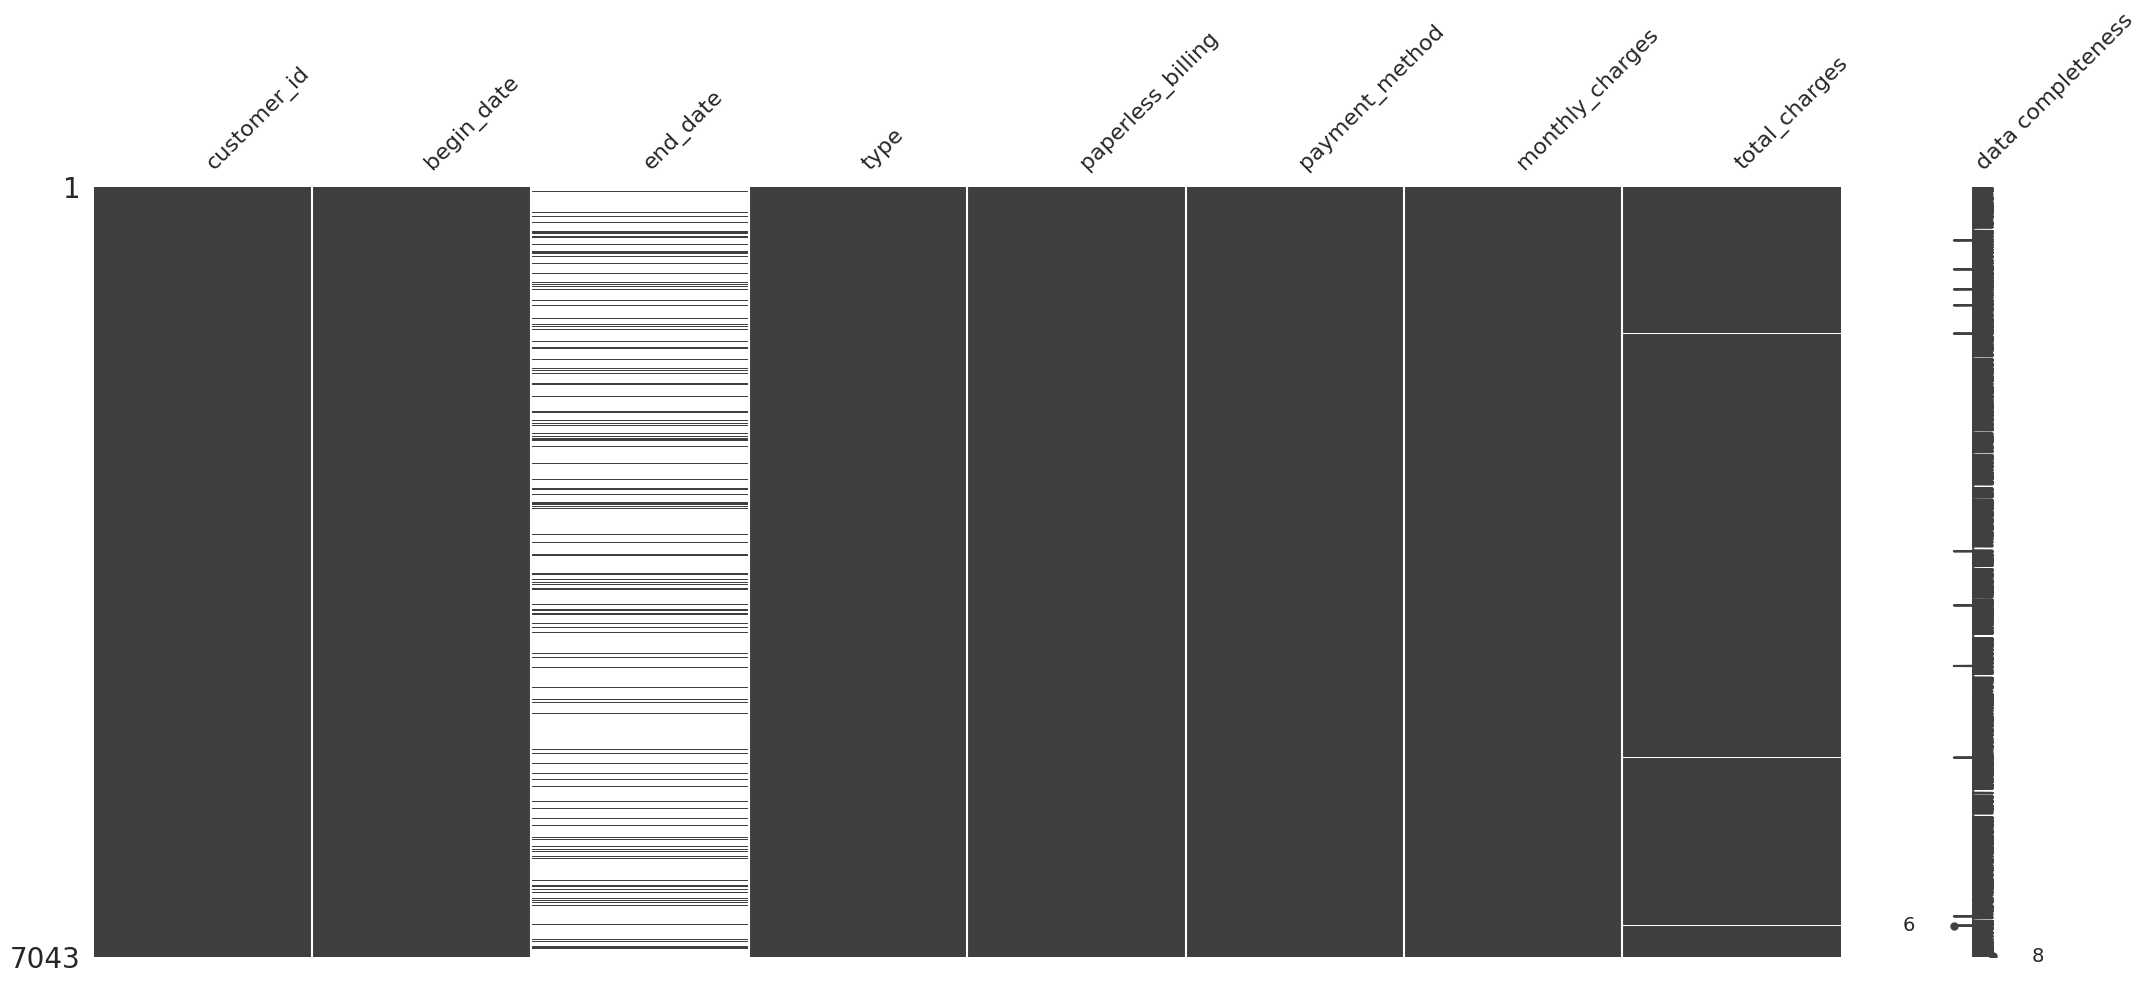

In [ ]:
# смотрим структуру пропусков
pass_miss(contract,'contract')

Мы видим, что часть расторгнувших договор клиентов из тех, кто попал в базу, значительно меньше (более чем в пять раз), то есть выборка не пропорциональна по целевому признаку (но не критично).

Также у части клиентов отсутствует информация об общих тратах.

In [ ]:
# находим строки с пропусками в указанном столбце
contract[contract['total_charges'].isna()]  # isna() или isnull()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
488,4472-LVYGI,2020-02-01,NaT,Two year,Yes,Bank transfer (automatic),52.55,NaN
753,3115-CZMZD,2020-02-01,NaT,Two year,No,Mailed check,20.25,NaN
936,5709-LVOEQ,2020-02-01,NaT,Two year,No,Mailed check,80.85,NaN
1082,4367-NUYAO,2020-02-01,NaT,Two year,No,Mailed check,25.75,NaN
1340,1371-DWPAZ,2020-02-01,NaT,Two year,No,Credit card (automatic),56.05,NaN
3331,7644-OMVMY,2020-02-01,NaT,Two year,No,Mailed check,19.85,NaN
3826,3213-VVOLG,2020-02-01,NaT,Two year,No,Mailed check,25.35,NaN
4380,2520-SGTTA,2020-02-01,NaT,Two year,No,Mailed check,20.00,NaN
5218,2923-ARZLG,2020-02-01,NaT,One year,Yes,Mailed check,19.70,NaN
6670,4075-WKNIU,2020-02-01,NaT,Two year,No,Mailed check,73.35,NaN


Наши данные - за первое февраля, то есть клиенты, которые не имеют данных по общим тратам - это клиенты, которые только заключили контракт (прямо в день выгрузки), а все их траты - оплата при заключении.

Таких клиентов немного и потенциально их можно будет исключить из исследования, чтобы не путать модель малой суммой контракта либо малым сроком действия договора.

Но сначала необходимо будет изучить наши данные.

#### **Дубликаты**

Явных дубликатов мы ранее не выявили.

In [ ]:
print(color.BLUE + color.BOLD +f"Количество скрытых дубликатов в contract (после исключения customer_id): "+ color.END + f"{contract.drop(columns = ['customer_id']).duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Количество уникальных комбинаций: "+ color.END + f"{len(contract) - contract.drop(columns = ['customer_id']).duplicated().sum()}")

Количество скрытых дубликатов в contract (после исключения customer_id): 37
Количество уникальных комбинаций: 7006


Данные клиенты имеют разные ID (то есть они точно разные), при этом у нас не так много параметров и их вариантов, чтобы все клиенты были абсолютно уникальны. И хоть наличие скрытых дублей может приводить к утечке данных, мы воздержимся пока от их удаления (тем более, что возможно присоединение других таблиц добавит недостающей уникальности клиентам).

In [ ]:
# функция для подсчета уникальных значений:
# обновленная для удобства чтения
def uniq_num(data, title, col_names):
    print(color.BLUE + color.BOLD + f"Количество уникальных значений датасета {title} для столбца:")
    for col in col_names:
        print(
            color.BLUE + color.BOLD + f"{col}: " +
            color.END + f"{data[col].nunique()}"
        )

In [ ]:
# применяем функцию uniq_num
uniq_num(contract, 'contract', contract.columns)

Количество уникальных значений датасета contract для столбца:
customer_id: 7043
begin_date: 77
end_date: 66
type: 3
paperless_billing: 2
payment_method: 4
monthly_charges: 1585
total_charges: 6657


Количество уникальных ID клиентов совпадает с количеством строк.

Небольшое количество вариантов в категориальных данных упрощает кодировку в будущем. А то, что отсутствует разнообразие в написании этих самых вариантов говорит в пользу качественного ведения базы (вероятно, заполняется не вручную, а из выпадающего списка).

### **`personal`**

#### **Загрузка**

In [ ]:
# составляем sql-запрос для загрузки нужной таблицы (personal)
# с переименованием согласно правилам хорошего тона
query = '''
SELECT customerID AS customer_id,
    gender,
    SeniorCitizen AS senior_citizen,
    Partner AS partner,
    Dependents AS dependents
FROM personal
'''
# сохраняем в датафрейм
try:
  personal = pd.read_sql_query(query, con=engine)
  print(color.GREEN + color.BOLD + f"Загрузка таблицы прошла успешно"+ color.END)
except:
  print(color.RED + color.BOLD + f"Ошибка загрузки таблицы!"+ color.END)

Загрузка таблицы прошла успешно


In [ ]:
# вызов функции discr_num и ее вывод
first_discr(personal,'personal', 15)


 === Первые 15 строк в personal: ===



,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
5,9305-CDSKC,Female,0,No,No
6,1452-KIOVK,Male,0,No,Yes
7,6713-OKOMC,Female,0,No,No
8,7892-POOKP,Female,0,Yes,No
9,6388-TABGU,Male,0,No,Yes



 === Общая информация о данных в personal: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   object
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: object(5)
memory usage: 275.2+ KB


None


 === Размер датасета personal:===
    (7043, 5)


 === Явные дубликаты в personal:===
Количество: 0
Процент: 0.00 %


Явных пропусков ранее не обнаружено.

Типы данных не требуют изменений (но один из столбцов требует приведения к единообразию, на что стоит обратить внимание заказчика).

#### **Дубликаты**

Явных дубликатов мы ранее не выявили.

In [ ]:
print(color.BLUE + color.BOLD +f"Количество скрытых дубликатов в personal (после исключения customer_id): "+ color.END + f"{personal.drop(columns = ['customer_id']).duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Количество уникальных комбинаций: "+ color.END + f"{len(personal) - personal.drop(columns = ['customer_id']).duplicated().sum()}")

Количество скрытых дубликатов в personal (после исключения customer_id): 7027
Количество уникальных комбинаций: 16


Здесь параметров, делающих клиентов уникальными, еще меньше.

In [ ]:
# применяем функцию uniq_num
uniq_num(personal, 'personal', personal.columns)

Количество уникальных значений датасета personal для столбца:
customer_id: 7043
gender: 2
senior_citizen: 2
partner: 2
dependents: 2


Здесь также все хорошо с аккуратностью ведения данных.

### **`internet`**

#### **Загрузка**

In [ ]:
# составляем sql-запрос для загрузки нужной таблицы (internet)
# с переименованием согласно правилам хорошего тона
query = '''
SELECT customerID AS customer_id,
  InternetService AS internet_service,
  OnlineSecurity AS online_security,
  OnlineBackup AS online_backup,
  DeviceProtection AS device_protection,
  TechSupport AS tech_support,
  StreamingTV AS streaming_tv,
  StreamingMovies AS streaming_movies
FROM internet
'''
# сохраняем в датафрейм
try:
  internet = pd.read_sql_query(query, con=engine)
  print(color.GREEN + color.BOLD + f"Загрузка таблицы прошла успешно"+ color.END)
except:
  print(color.RED + color.BOLD + f"Ошибка загрузки таблицы!"+ color.END)

Загрузка таблицы прошла успешно


In [ ]:
# вызов функции discr_num и ее вывод
first_discr(internet,'internet', 15)


 === Первые 15 строк в internet: ===



,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
6,1452-KIOVK,Fiber optic,No,Yes,No,No,Yes,No
7,6713-OKOMC,DSL,Yes,No,No,No,No,No
8,7892-POOKP,Fiber optic,No,No,Yes,Yes,Yes,Yes
9,6388-TABGU,DSL,Yes,Yes,No,No,No,No



 === Общая информация о данных в internet: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


None


 === Размер датасета internet:===
    (5517, 8)


 === Явные дубликаты в internet:===
Количество: 0
Процент: 0.00 %


Изменение типов данных не требуется. Явных пропусков ранее не обнаружено.

#### **Дубликаты**

Явных дубликатов мы ранее не выявили.

In [ ]:
print(color.BLUE + color.BOLD +f"Количество скрытых дубликатов в internet (после исключения customer_id): "+ color.END + f"{internet.drop(columns = ['customer_id']).duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Количество уникальных комбинаций: "+ color.END + f"{len(internet) - internet.drop(columns = ['customer_id']).duplicated().sum()}")

Количество скрытых дубликатов в internet (после исключения customer_id): 5389
Количество уникальных комбинаций: 128


Здесь также много скрытых дубликатов.

In [ ]:
# применяем функцию uniq_num
uniq_num(internet, 'internet', internet.columns)

Количество уникальных значений датасета internet для столбца:
customer_id: 5517
internet_service: 2
online_security: 2
online_backup: 2
device_protection: 2
tech_support: 2
streaming_tv: 2
streaming_movies: 2


Данные также ведутся аккуратно.

### **`phone`**

#### **Загрузка**

In [ ]:
# составляем sql-запрос для загрузки нужной таблицы (internet)
# с переименованием согласно правилам хорошего тона
query = '''
SELECT customerID AS customer_id,
  MultipleLines AS multiple_lines
FROM phone
'''
# сохраняем в датафрейм
try:
  phone = pd.read_sql_query(query, con=engine)
  print(color.GREEN + color.BOLD + f"Загрузка таблицы прошла успешно"+ color.END)
except:
  print(color.RED + color.BOLD + f"Ошибка загрузки таблицы!"+ color.END)

Загрузка таблицы прошла успешно


In [ ]:
# вызов функции discr_num и ее вывод
first_discr(phone,'phone', 15)


 === Первые 15 строк в phone: ===



,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
5,7892-POOKP,Yes
6,6388-TABGU,No
7,9763-GRSKD,No
8,7469-LKBCI,No
9,8091-TTVAX,Yes



 === Общая информация о данных в phone: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


None


 === Размер датасета phone:===
    (6361, 2)


 === Явные дубликаты в phone:===
Количество: 0
Процент: 0.00 %


Изменение типов данных не требуется. Явных пропусков ранее не обнаружено.

#### **Дубликаты**

Явных дубликатов мы ранее не выявили.

In [ ]:
print(color.BLUE + color.BOLD +f"Количество скрытых дубликатов в phone (после исключения customer_id): "+ color.END + f"{phone.drop(columns = ['customer_id']).duplicated().sum()}")
print(color.BLUE + color.BOLD +f"Количество уникальных комбинаций: "+ color.END + f"{len(phone) - phone.drop(columns = ['customer_id']).duplicated().sum()}")

Количество скрытых дубликатов в phone (после исключения customer_id): 6359
Количество уникальных комбинаций: 2


С учетом малого количества столбцов (всего два), разнообразие вариантов ожидаемо невелико.

In [ ]:
# применяем функцию uniq_num
uniq_num(phone, 'phone', phone.columns)

Количество уникальных значений датасета phone для столбца:
customer_id: 6361
multiple_lines: 2


Данные также ведутся аккуратно.

In [ ]:
# закроем соединение
# если планируется делать еще запросы, лучше использовать connection.close() для конкретного соединения
# connection.close()
# engine.dispose() закрывает все соединения в пуле и делает engine непригодным для дальнейшего использования
engine.dispose()
print(color.BLUE + color.BOLD +f"Все соединения закрыты"+ color.END)

Все соединения закрыты


### **Выводы**

Мы загрузили и провели первичное ознакомление с требуемыми для выполнения задачи таблицами. Не во всех из них типы данных соответствуют содержимому, а имена каждого из столбцов нарушают правила хорошего тона.

Для таблицы `'contract'` (информация о договорах с клиентами):
- изменили имена столбцов согласно правилам хорошего тона;
- исправили типы данных столбцов согласно содержимому;
- обнаружили пропуски в нескольких столбцах, при исследовании которых обнаружили, что:
    - большая часть клиентов (84.37%) из доступной для анализа таблицы являются действующими абонентами;
    - небольшую долю процента (0.16%) составляют клиенты, у которых отсутствуют оющие траты - это клиенты, заключившие контракт в день выгрузки базы для анализа. Так как такие абоненты неинформативны, в будущем они будут исключены из данных для обучения.
- явные дубликаты отсутствуют, однако есть скрытые (после исключения id клиента). Но удалять их не будем (так как это действительно разные клиенты, плюс пока еще не сформирована общая таблица для изучения).
- количество уникальных значений из столбцов с категориальными признаками невелико, чтоб облегчает нам работу с данными и говооит об аккуратности ведения данных.

Для таблицы `'personal'` (персональные данные клиентов):
- изменили имена столбцов согласно правилам хорошего тона;
- следует обратить внимание заказчика на отсутствие единообразия с остальными столбцами в столбце со статусом пенсионера;
- явные пропуски не обнаружены;
- явные дубликаты отсутствуют, однако есть скрытые (после исключения id клиента), что логично ввиду малого количества параметров, которые делают каждого клиента уникальным. Удалять мы их также не будем по тем же причинам, что и у таблицы с договорами;
- количество клиентов совпадает с таковым из таблицы с договорами;
- количество уникальных значений из столбцов с категориальными признаками также невелико.

Для таблицы `'internet'` (информация об интернет-услугах):
- изменили имена столбцов согласно правилам хорошего тона;
- количество клиентов не совпадает с таковым из таблицы с договорами - то есть не все абоненты пользуются интернет-услугами;
- явные пропуски не обнаружены;
- аналогично предыдущим таблицам, явные дубликаты отсутствуют, однако есть скрытые (после исключения id клиента).

Для таблицы `'phone'` (информация об слугах телефонии):
- изменили имена столбцов согласно правилам хорошего тона;
- количество клиентов не совпадает с таковым из таблицы с договорами - то есть не все абоненты пользуются услугами телефонии;
- явные пропуски не обнаружены;
- аналогично предыдущим таблицам, явные дубликаты отсутствуют, однако есть скрытые (после исключения id клиента).



## **Исследовательский анализ данных**

Так как нас интересует не столько структура клиентов заказчика, а расторгнет он контракт или нет, смотреть одни категории в разрезе других мы не будем. Вместо этого мы составим портрет клиента, склонного к уходу.

Но перед тем, как составлять портрет, изучим таблицы по-отдельности.

### **`contract`**

In [ ]:
# вспомнаем названия столбцов
contract.columns

Index(['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges'],
      dtype='object')

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)


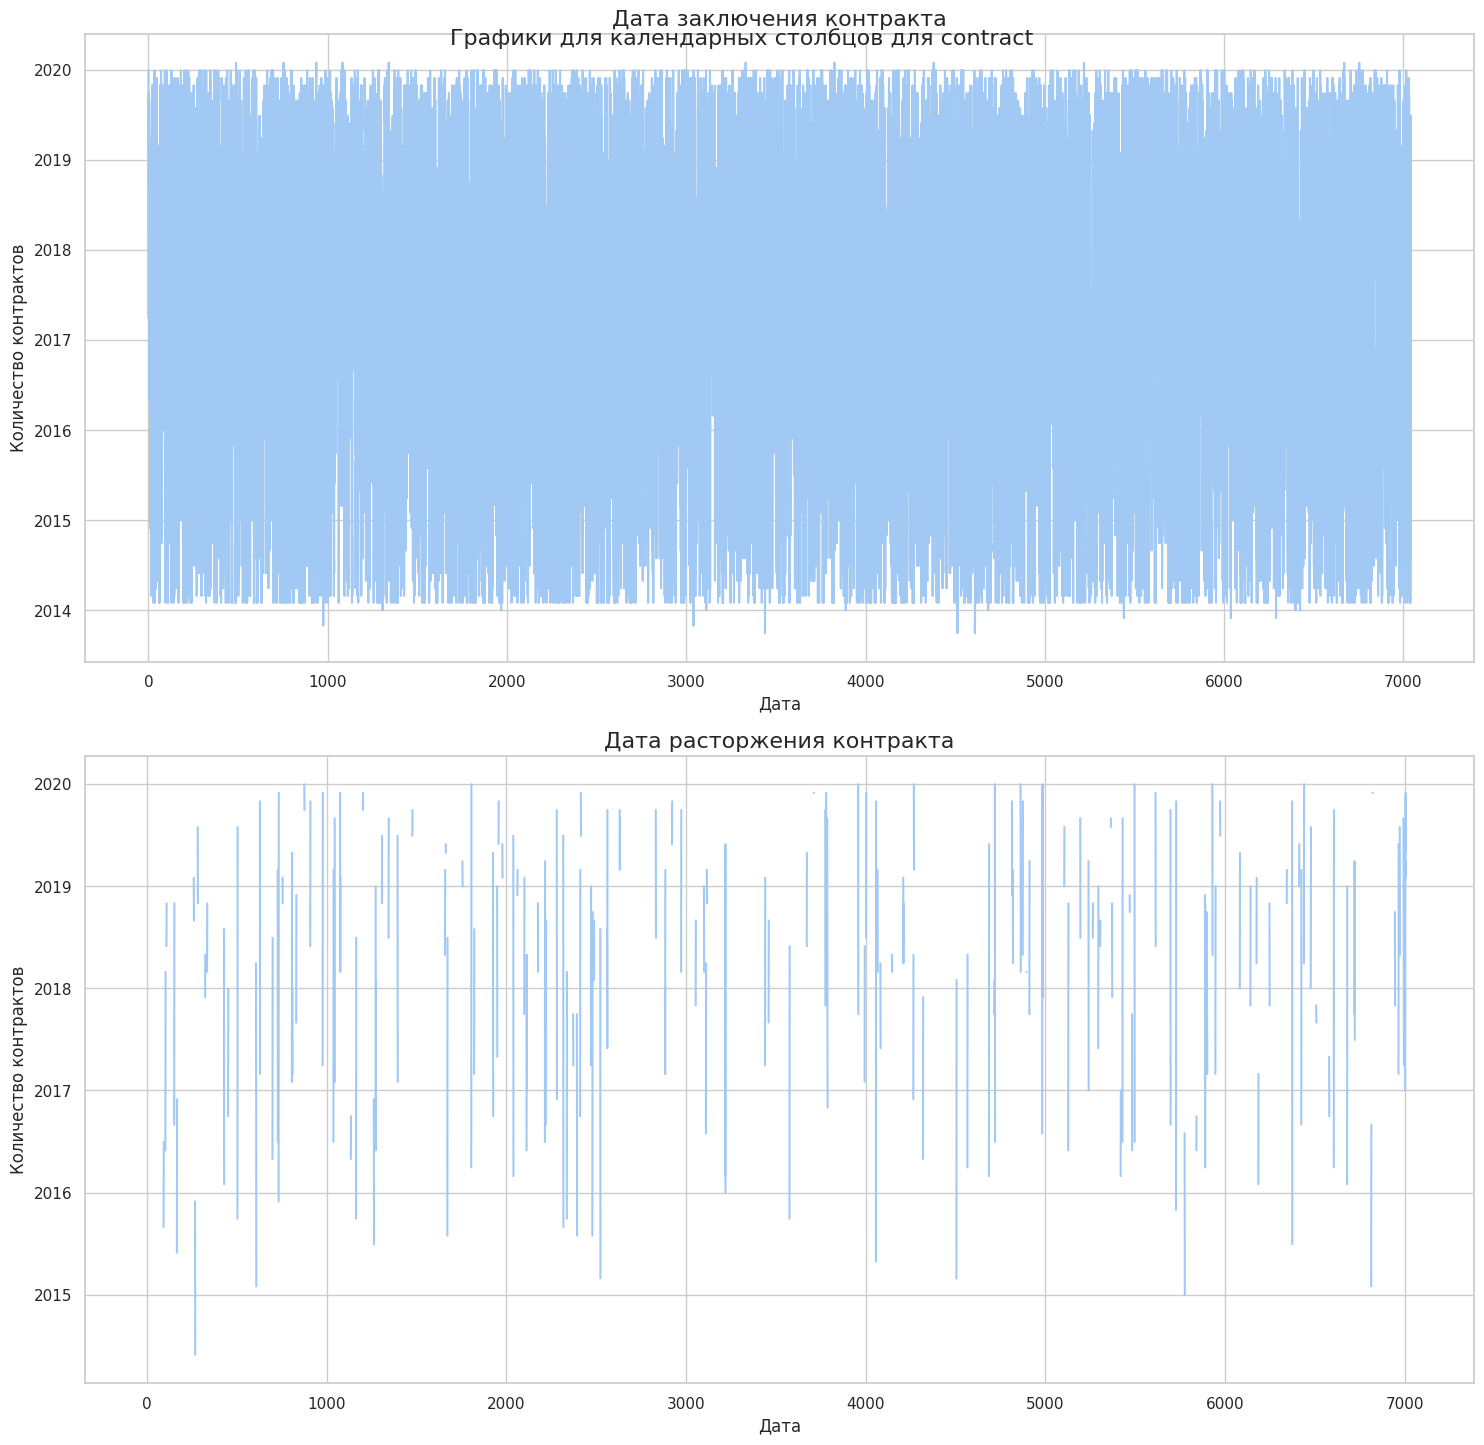

In [ ]:
# визуализируем данные по параметрам дат
fig, axes = plt.subplots(nrows=2, ncols=1)
fig.set_figheight(15)
fig.set_figwidth(15)
fig.suptitle('Графики для календарных столбцов для contract', y=0.95, size=16)

# График даты заключения контракта
contract['begin_date'].plot(ax=axes[0], grid=True, title='Дата заключения контракта')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Количество контрактов')

# График даты расторжения контракта
contract['end_date'].plot(ax=axes[1], grid=True, title='Дата расторжения контракта')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Количество контрактов')

plt.tight_layout()

Контракты за исследуемый период заключались относительно равномерно.

Небольшое количество контрактов, попавших в базу данных, были заключены еще в 2013 году.

Самые ранние контракты из попавших в базу были расторгнуты в 2014 году.

In [ ]:
# смотрим на заключенные до 2014 года контракты
print(color.BLUE + color.BOLD + f"Количество заключенных до 2014 года контрактов: "+ color.END + f"{len(contract[contract['begin_date'].dt.year < 2014])}")
contract[contract['begin_date'].dt.year < 2014]

Количество заключенных до 2014 года контрактов: 8


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
975,2834-JRTUA,2013-11-01,NaT,Two year,Yes,Electronic check,108.05,"8,184.79"
3040,7317-GGVPB,2013-11-01,NaT,Two year,Yes,Credit card (automatic),108.60,"8,145.00"
3439,0917-EZOLA,2013-10-01,NaT,Two year,Yes,Bank transfer (automatic),104.15,"7,915.40"
4513,8580-QVLOC,2013-10-01,NaT,Two year,No,Credit card (automatic),92.45,"7,026.20"
4610,2889-FPWRM,2013-10-01,NaT,One year,Yes,Bank transfer (automatic),117.80,"9,221.38"
5441,3512-IZIKN,2013-12-01,2017-10-01,Two year,No,Credit card (automatic),65.30,"3,003.80"
6038,1555-DJEQW,2013-12-01,2014-11-01,Two year,Yes,Bank transfer (automatic),114.20,"1,281.32"
6290,2530-ENDWQ,2013-12-01,NaT,Two year,Yes,Bank transfer (automatic),93.70,"6,933.80"


Большая часть контрактов, заключенных в 2013 году все еще действует, соответственно и общая сумма трат у таких клиентов большая.

In [ ]:
# смотрим на растогнутые до 2015 года контракты
print(color.BLUE + color.BOLD + f"Количество растогнутых до 2015 года контрактов: "+ color.END + f"{len(contract[contract['end_date'].dt.year < 2015])}")
contract[contract['end_date'].dt.year < 2015]

Количество растогнутых до 2015 года контрактов: 7


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
269,7014-ZZXAW,2014-03-01,2014-06-01,Two year,Yes,Credit card (automatic),24.25,77.84
1997,0266-CLZKZ,2014-07-01,2014-09-01,Two year,Yes,Bank transfer (automatic),105.65,228.20
2019,7694-VLBWQ,2014-04-01,2014-10-01,One year,No,Electronic check,104.10,637.09
2254,7322-OCWHC,2014-02-01,2014-09-01,Two year,Yes,Bank transfer (automatic),93.05,677.40
5834,5055-MGMGF,2014-09-01,2014-12-01,Month-to-month,Yes,Electronic check,105.05,315.15
6038,1555-DJEQW,2013-12-01,2014-11-01,Two year,Yes,Bank transfer (automatic),114.20,"1,281.32"
6724,7359-SSBJK,2014-06-01,2014-12-01,Two year,Yes,Credit card (automatic),70.20,429.62


Контрактов, растогнутых до 2015 года, немного и суммы общих трат у них разные.

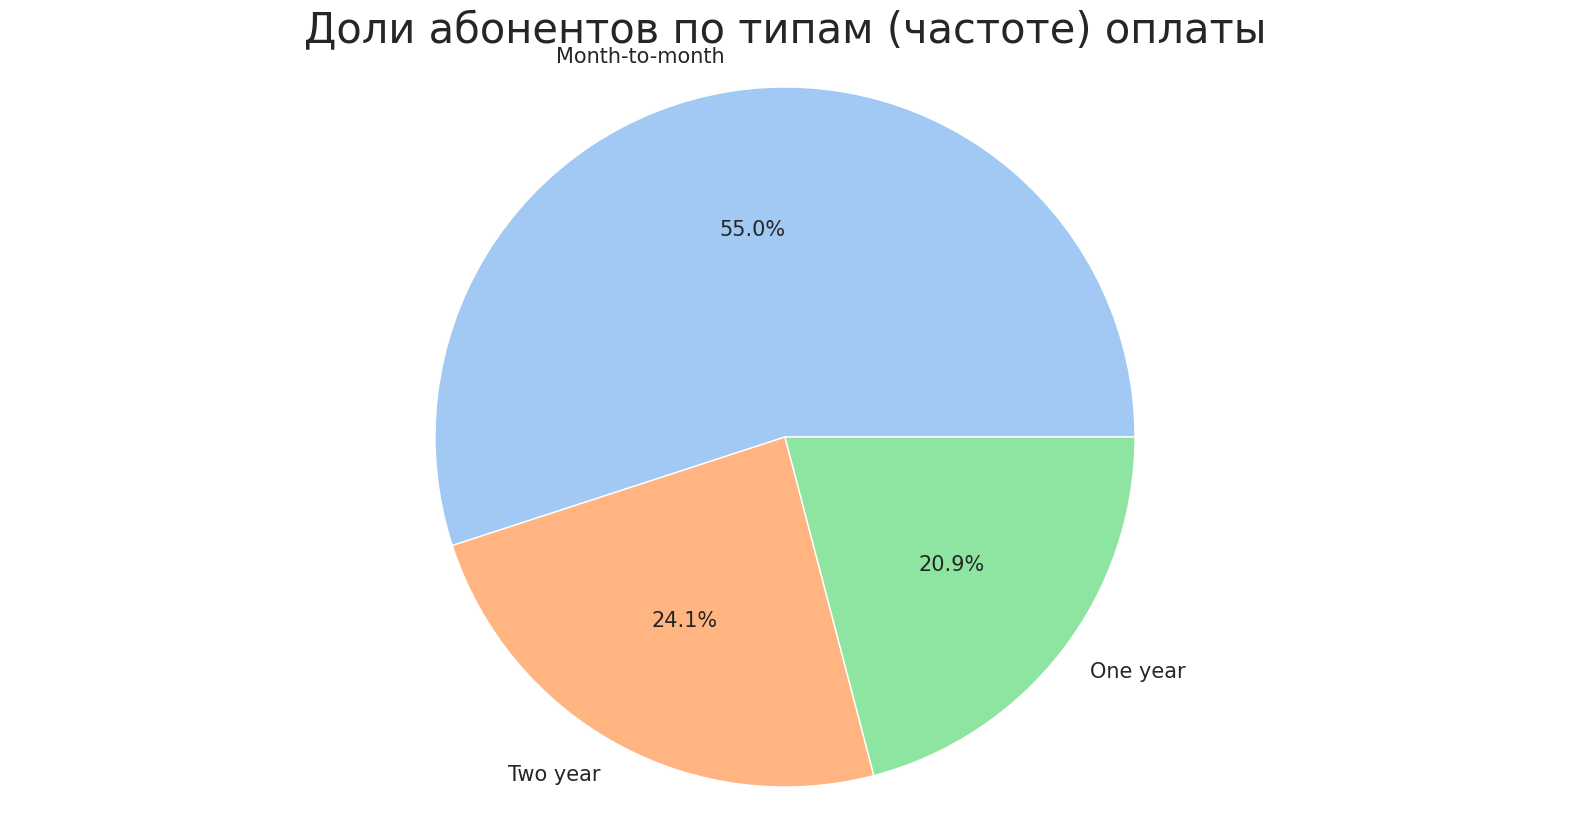

In [ ]:
# визуализируем тип (частоту) оплаты
contract['type'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов по типам (частоте) оплаты', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большая часть клиентов предпочитает платить ежемесячно.

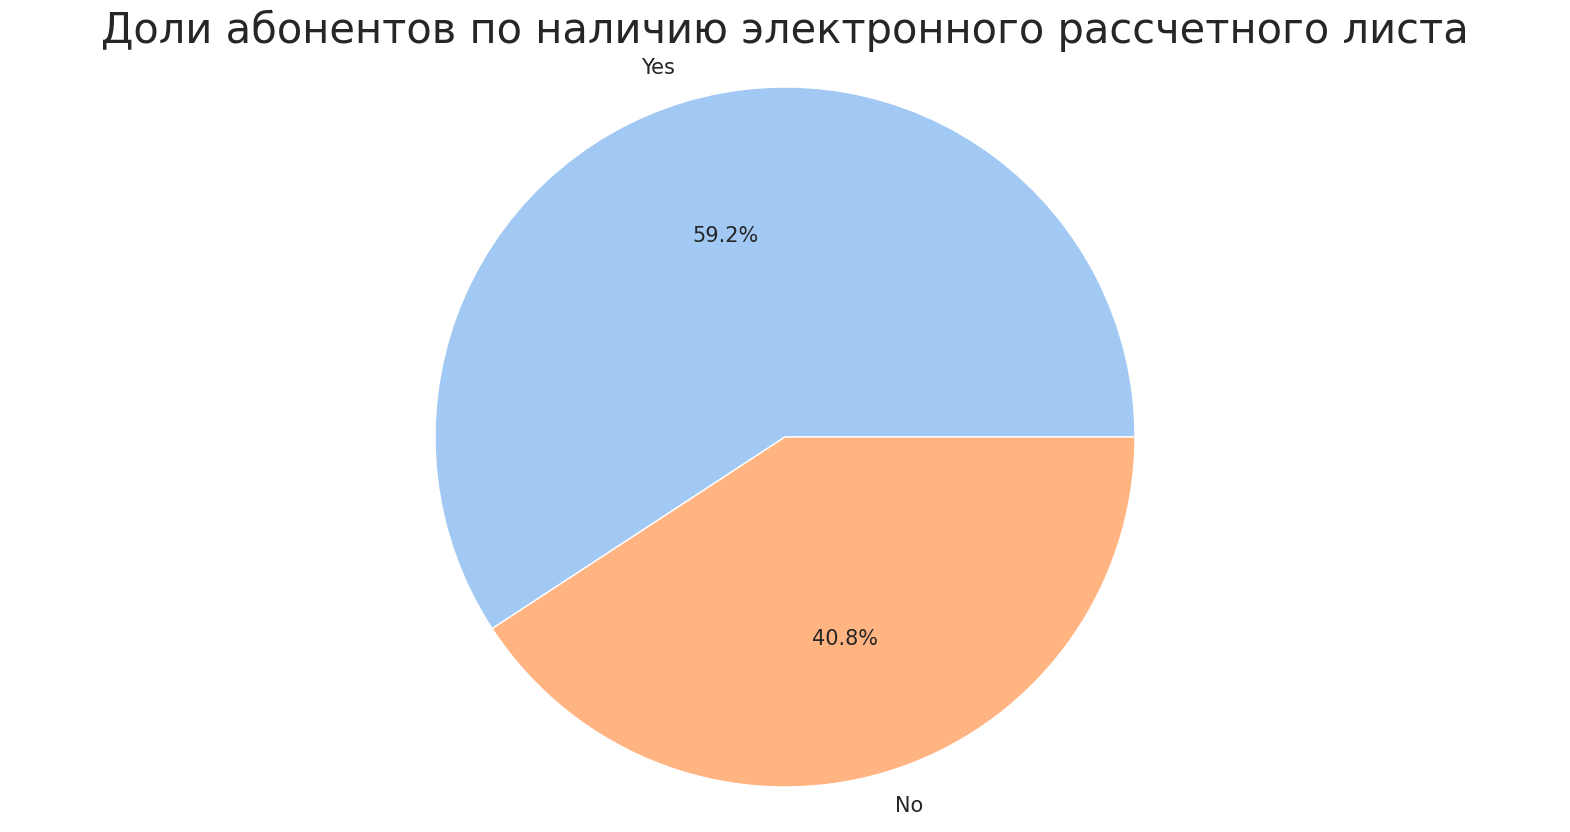

In [ ]:
# визуализируем тип (способ) платежа
contract['paperless_billing'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов по наличию электронного рассчетного листа', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большая часть клиентов имеет электронный рассчетный счет.

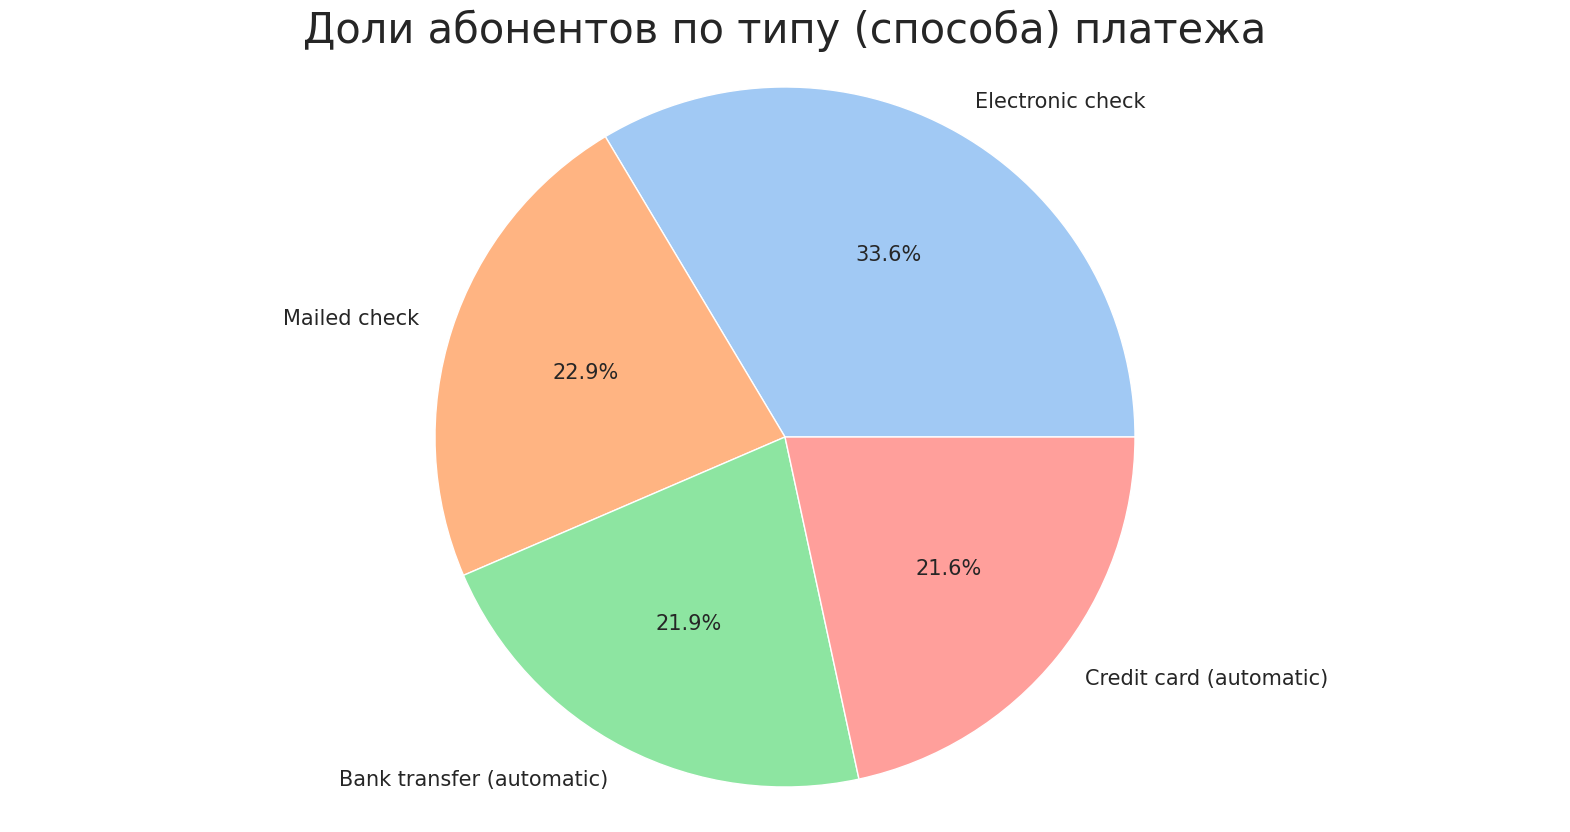

In [ ]:
# визуализируем тип платежа
contract['payment_method'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов по типу (способа) платежа', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Три типа из четырех типов оплаты имеют очень близкие доли. И лишь ненамного большая часть клиентов предпочитает электронную оплату.

In [ ]:
# создание функции для будущего описания числовых недискретных признаков
def discr_num(col_data, title, x_label):
    # Создание графиков: гистограмма и диаграмма размаха
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

    # Гистограмма
    sns.histplot(data=col_data, bins=50, kde=True, ax=axs[0])
    axs[0].set_xlabel(x_label)
    axs[0].set_ylabel('Количество попаданий в выборку')
    axs[0].set_title('Гистограмма')

    # Диаграмма размаха
    sns.boxplot(data=col_data, ax=axs[1])
    axs[1].set_xlabel(x_label)
    axs[1].set_title('Диаграмма размаха')

    # Заголовок графиков
    fig.suptitle(title)

    # Показать графики и вернуть описательные статистики
    plt.show()
    return col_data.describe()

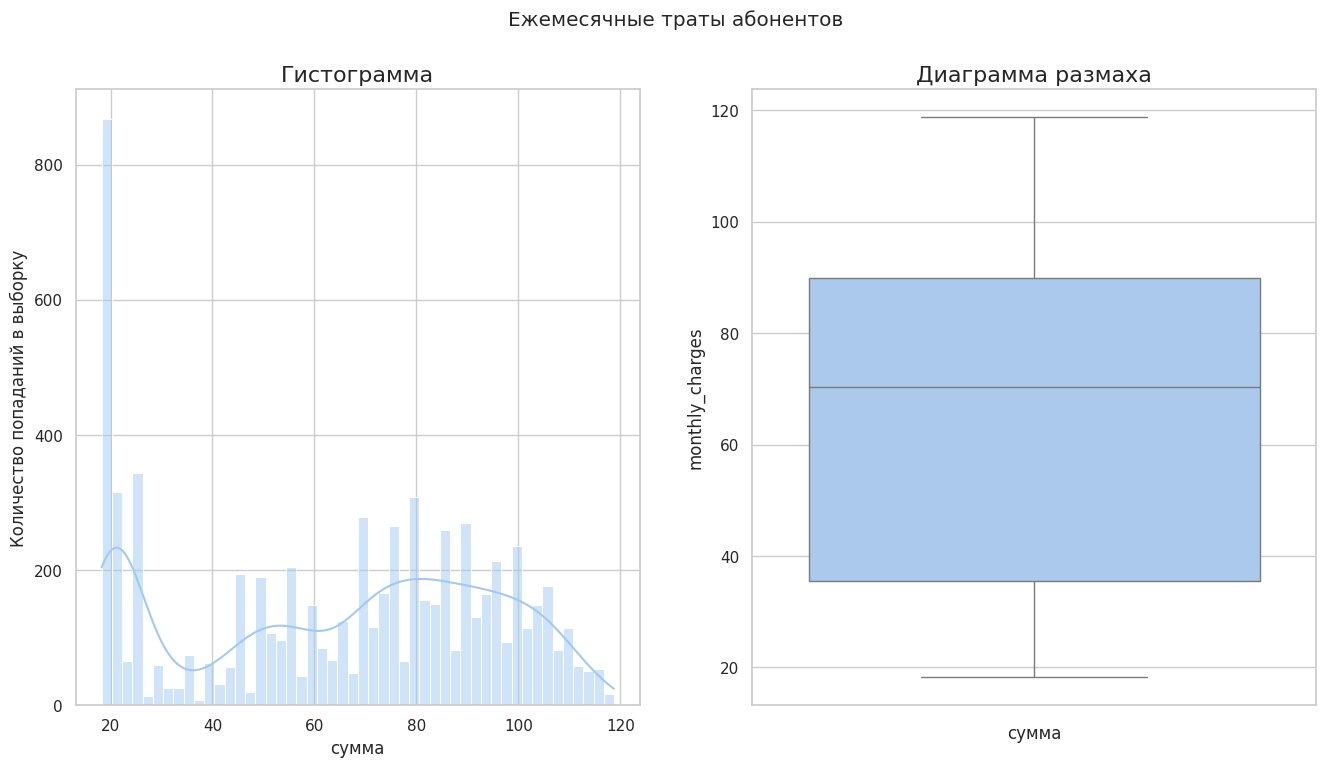

count   7,043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: monthly_charges, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод
print(discr_num(contract['monthly_charges'],
                   'Ежемесячные траты абонентов',
                   'сумма'))

Гистограмма ежемесячных трат имеет несколько пиков (то есть у нас три условные группы клиентов). Среднее и медиана не слишком близки, выбросы не обнаружены. Это можно вероятно объяснить разным количеством подключенных услуг либо разными тарифами в разный период времени.

Никто из клиентов не потратил менее 18 или более 119 условных единиц за месяц, средняя трата составила около 70 единиц.

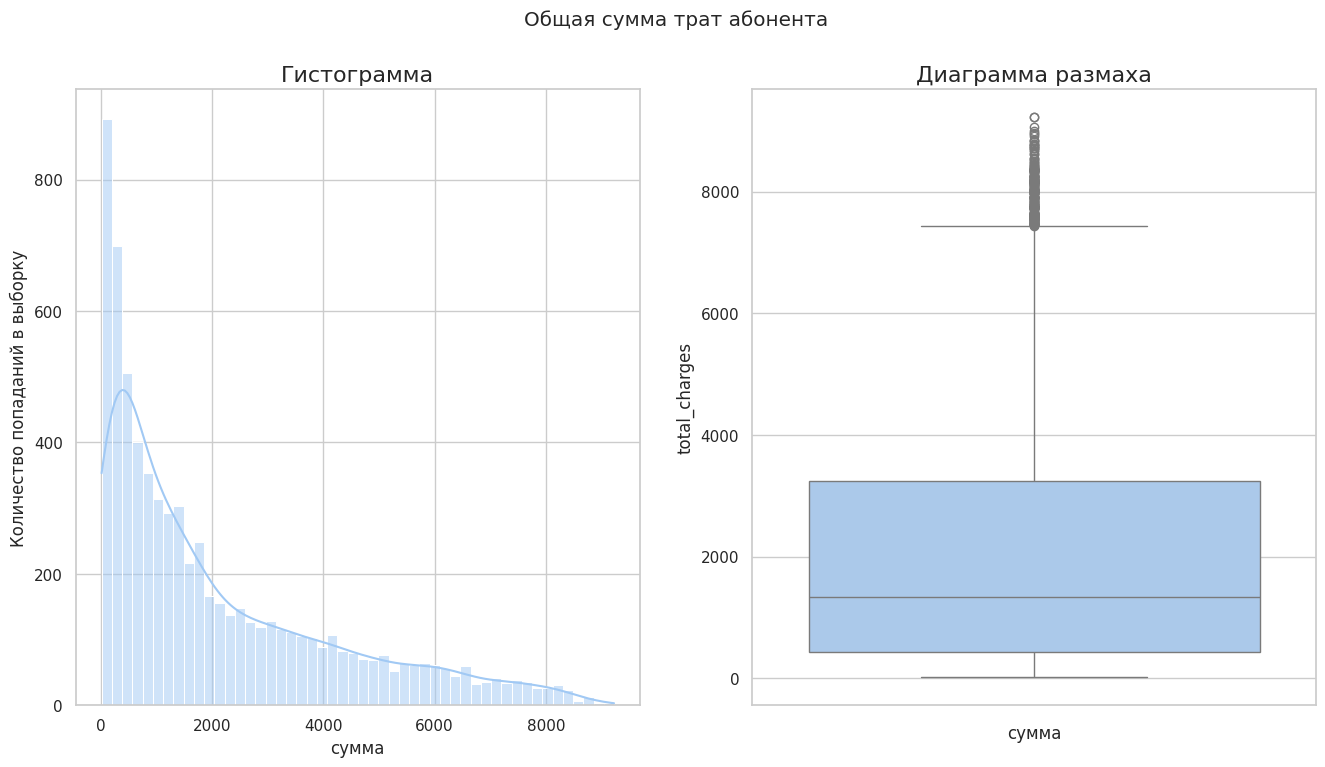

count   7,032.00
mean    2,118.62
std     2,112.74
min        19.05
25%       439.75
50%     1,345.28
75%     3,239.32
max     9,221.38
Name: total_charges, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод
print(discr_num(contract['total_charges'],
                   'Общая сумма трат абонента',
                   'сумма'))

Гистограмма распределения общих трат имеет один пик и смещена влево. Что можно предварительно (это мы изучим позже) объяснить тем, что многие абоненты пользуются небольшим количеством услуг, а также у нас не так много клиентов-"долгожителей".

Средняя и медина сильно отличаются, что вместе с большим стандартным отклонением говорит о неравномерности данных в выборке. Средняя сумма трат составила около 1345 условных единиц за период действия контракта.

Также обнаружены аномалии, которые посмотрим поближе.

In [ ]:
# смотрим на аномально большие траты
print(color.BLUE + color.BOLD + f"Количество общих трат с суммой более 7500: "+ color.END + f"{len(contract[contract['total_charges'] >= 7500])}")
contract[contract['total_charges'] >= 7500]

Количество общих трат с суммой более 7500: 181


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
17,9959-WOFKT,2014-03-01,NaT,Two year,No,Bank transfer (automatic),106.70,"8,257.51"
57,5067-XJQFU,2014-08-01,NaT,One year,Yes,Electronic check,108.45,"7,730.32"
59,5954-BDFSG,2014-02-01,NaT,Two year,Yes,Credit card (automatic),107.50,"7,740.00"
198,7255-SSFBC,2014-02-01,NaT,Two year,Yes,Bank transfer (automatic),112.25,"8,324.46"
369,3520-FJGCV,2014-02-01,NaT,Two year,Yes,Credit card (automatic),112.60,"8,755.78"
437,4376-KFVRS,2014-02-01,NaT,Two year,Yes,Credit card (automatic),114.05,"8,211.60"
449,1090-ESELR,2014-02-01,NaT,Two year,No,Bank transfer (automatic),105.50,"7,596.00"
464,1480-BKXGA,2014-02-01,NaT,Two year,Yes,Bank transfer (automatic),116.05,"8,355.60"
483,5168-MQQCA,2014-02-01,NaT,One year,Yes,Bank transfer (automatic),108.50,"8,358.84"
526,8606-CIQUL,2014-02-01,NaT,Two year,Yes,Credit card (automatic),115.75,"8,334.00"


Таких клиентов много, и все они являются "долгожителями" - заключили договор еще в начале переиода наблюдения, и практически все из них являются абонентами на момент выгрузки данных. То есть это - "особая група" и мы не можем исключить данных клиентов из выборки.

### **`personal`**

In [ ]:
# вспоминаем названия столбцов
personal.columns

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents'], dtype='object')

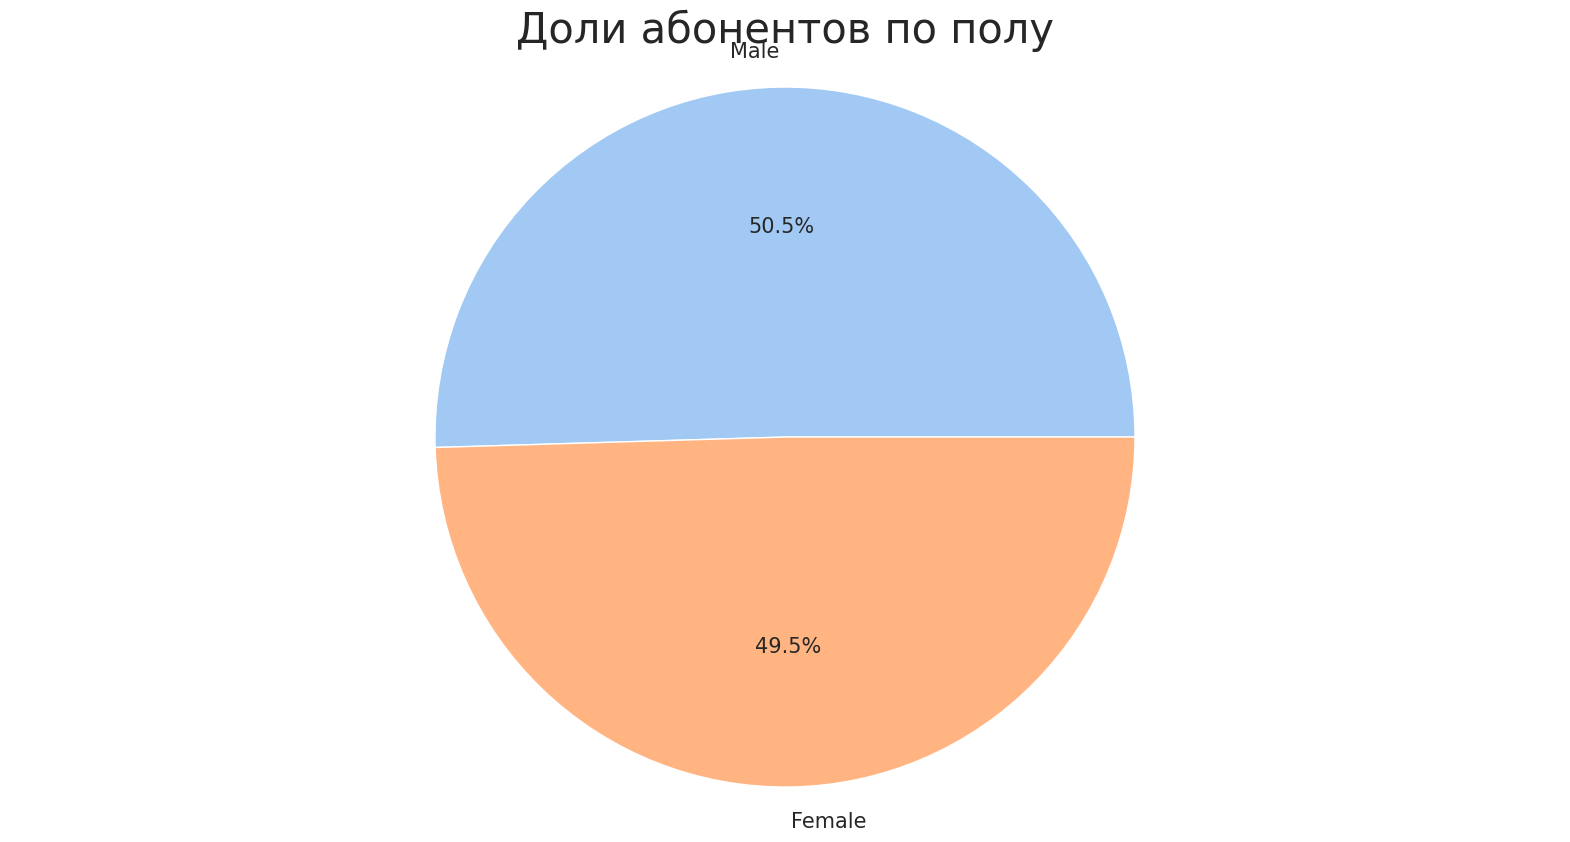

In [ ]:
# визуализируем пол
personal['gender'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов по полу', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доли абонентов по полу практически равны.

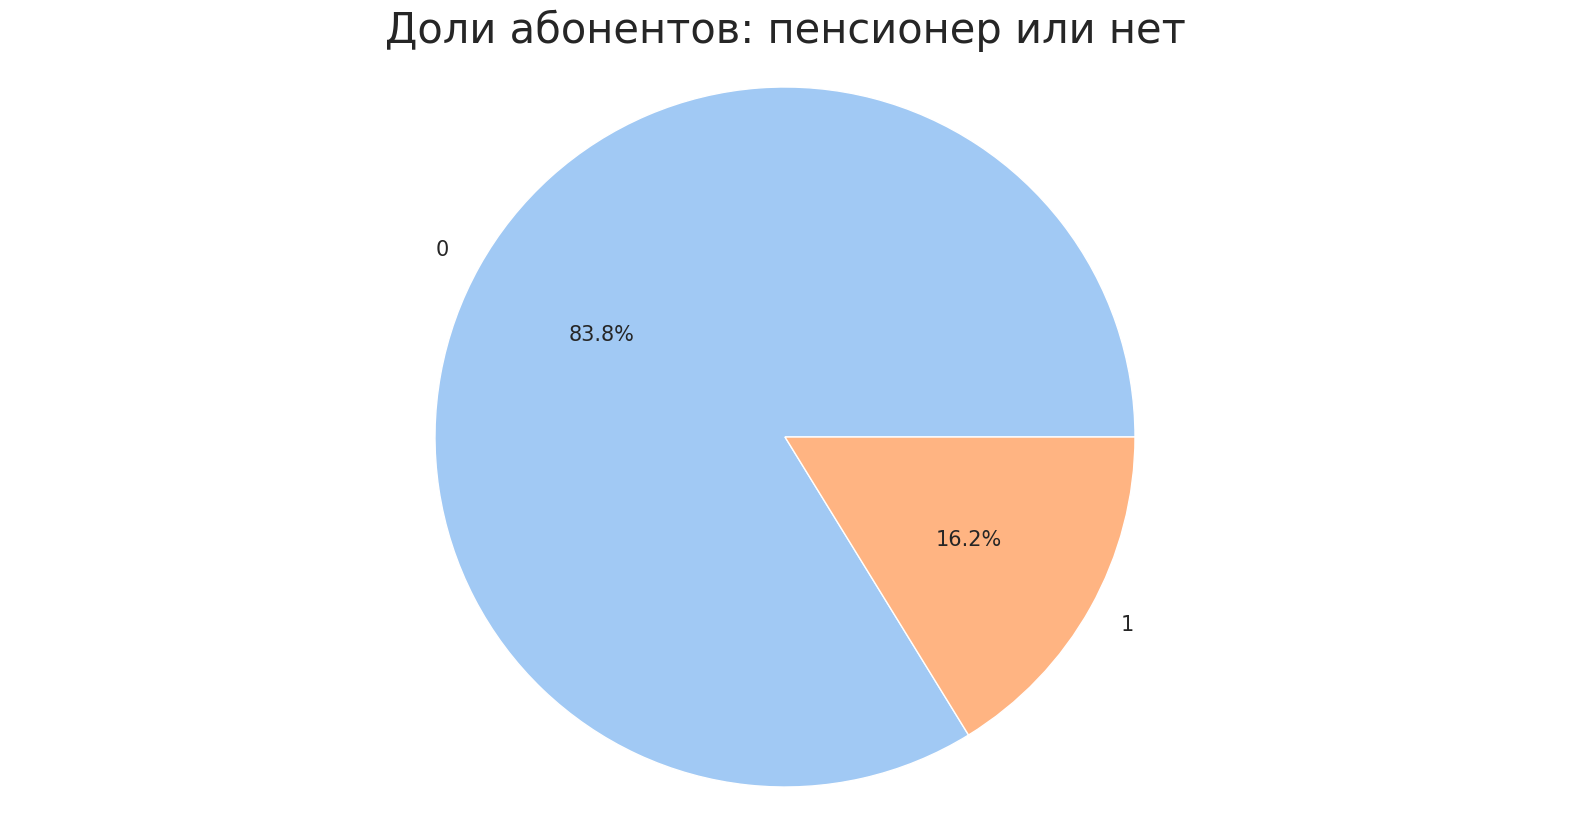

In [ ]:
# визуализируем пенсионер или нет
personal['senior_citizen'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов: пенсионер или нет', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доля пенсионеров гораздо меньше тех, кто ими не является.

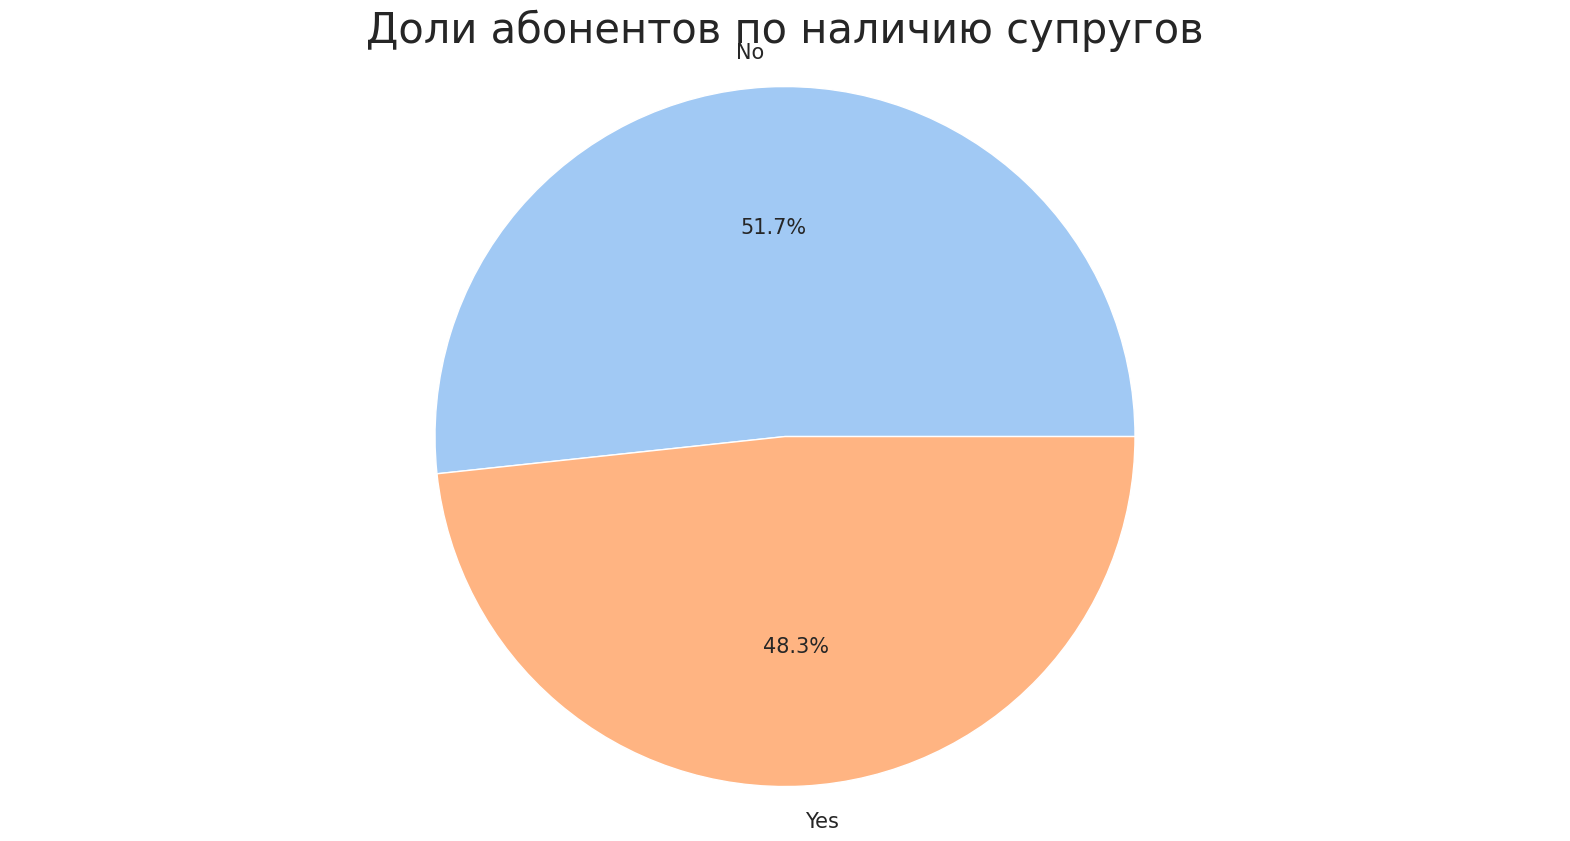

In [ ]:
# визуализируем по наличию супруга
personal['partner'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов по наличию супругов', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доли абонентов имеющих и не имеющих супругов практически сопоставимы.

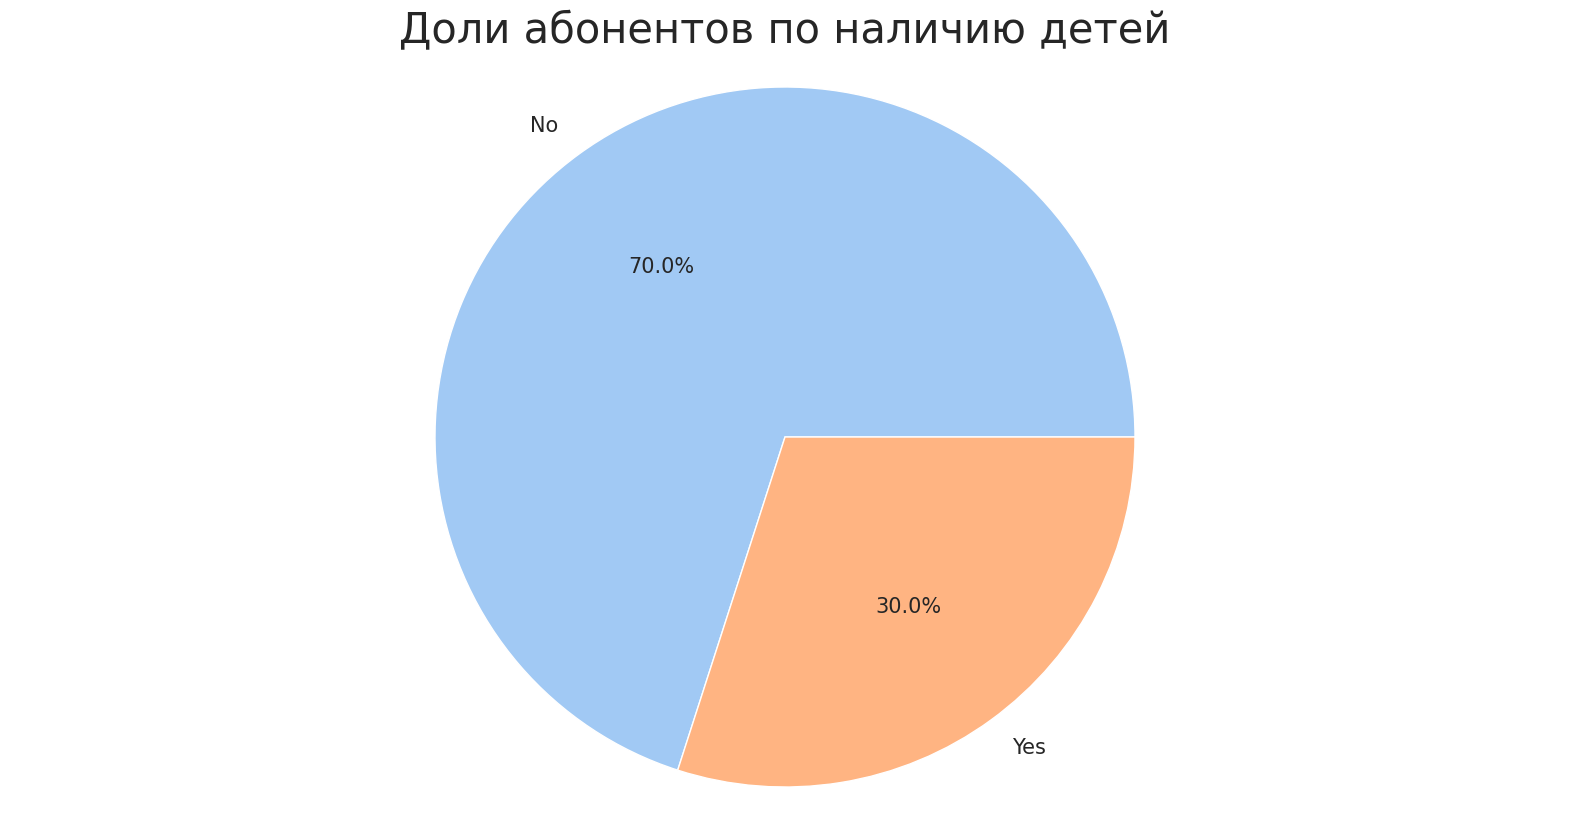

In [ ]:
# визуализируем по наличию детей
personal['dependents'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов по наличию детей', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Лишь 30% абонентов имеют детей.

### **`internet`**

Как мы помним, не все абоненты пользуются обеими услугами сразу. Поэтому для начал изучим структу в разрезе тех, кто пользуется.

In [ ]:
# вспоминаем названия столбцов
internet.columns

Index(['customer_id', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies'],
      dtype='object')

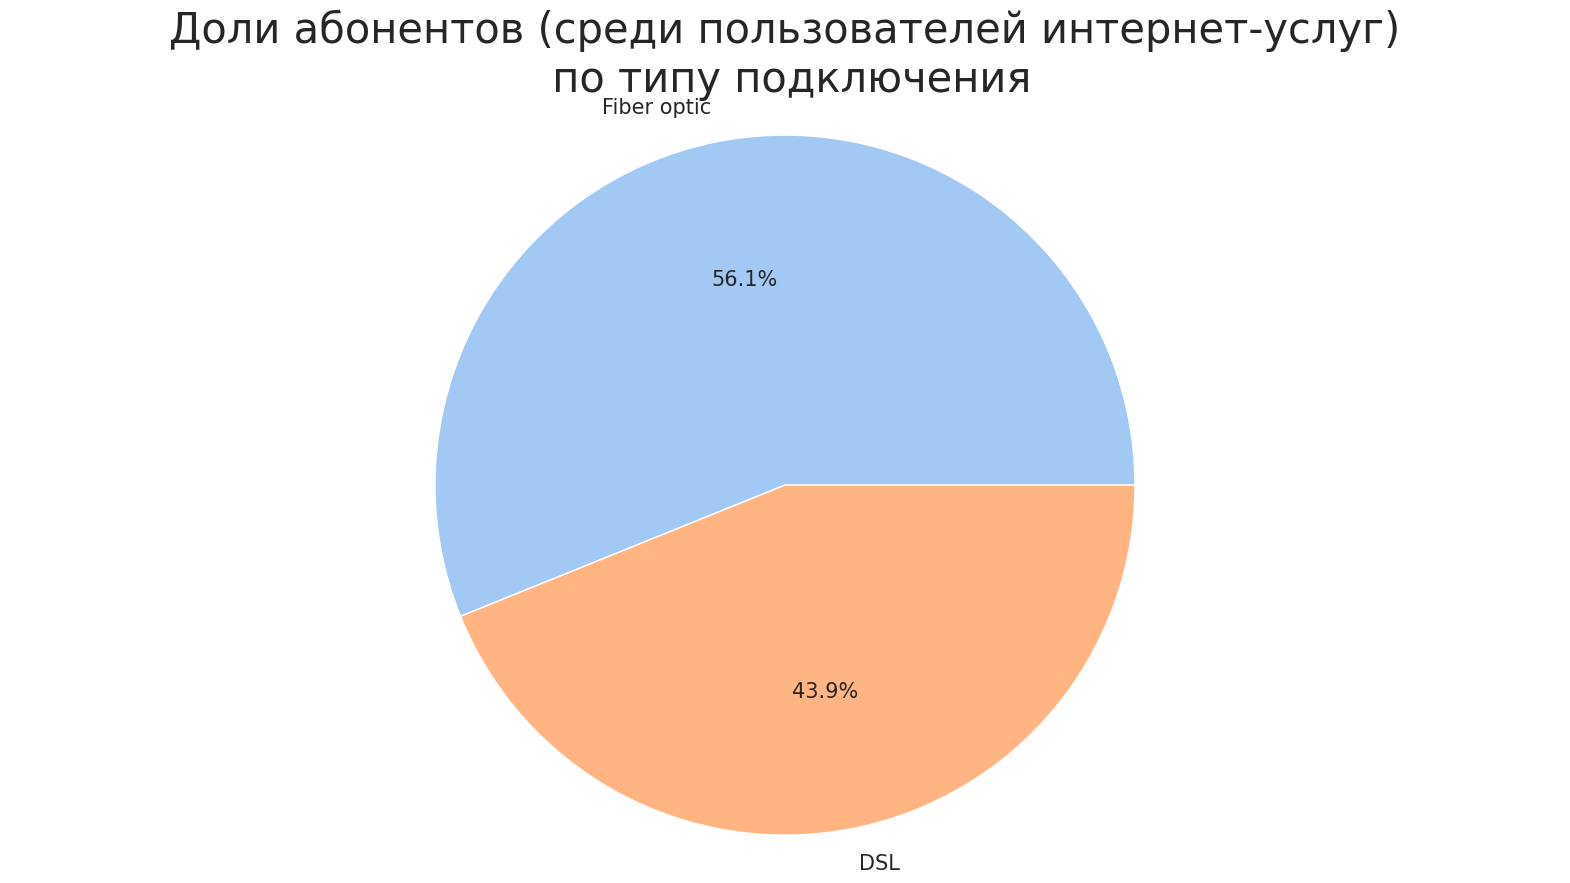

In [ ]:
# визуализируем по типу подключения
internet['internet_service'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по типу подключения', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большая часть клиентов из тех, кто пользуется услугами интернета, подключены с помощью оптоволоконного кабеля, что говорит о стремлении компании к новым технологиям.

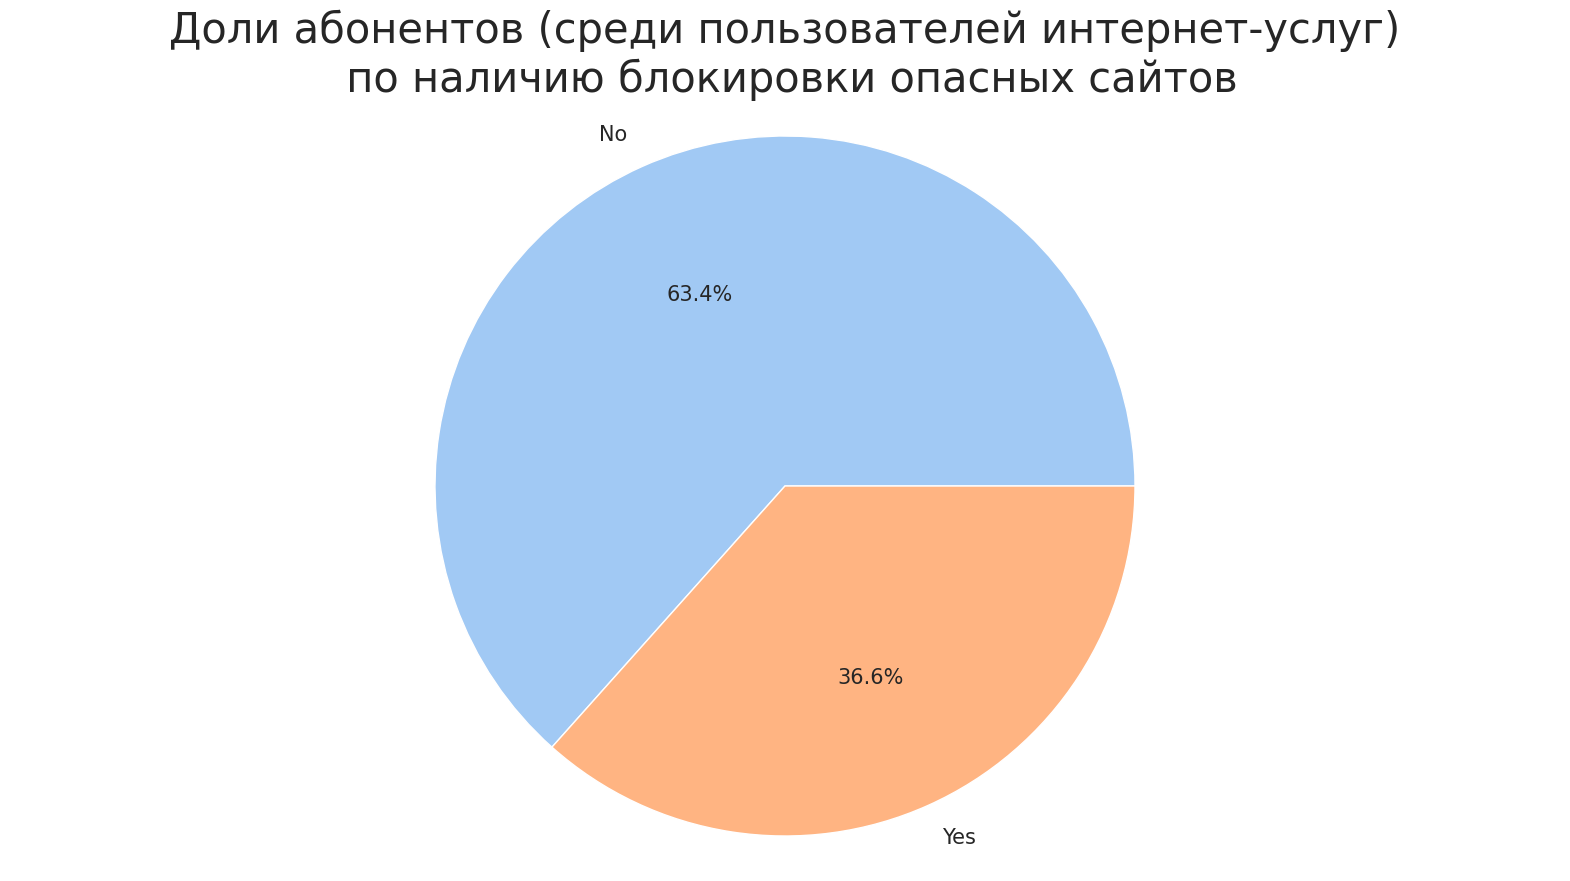

In [ ]:
# визуализируем по блокировке опасных сайтов
internet['online_security'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по наличию блокировки опасных сайтов', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большая часть клиентов из тех, кто пользуется интернет-услугами не использует услугу блокировки опасных сайтов. Возможно, они справляются с проблемой собственными силами (например, установкой специализированного ПО на личном ПК), либо по каким-либо причинам не считают важным наличие данной возможности.

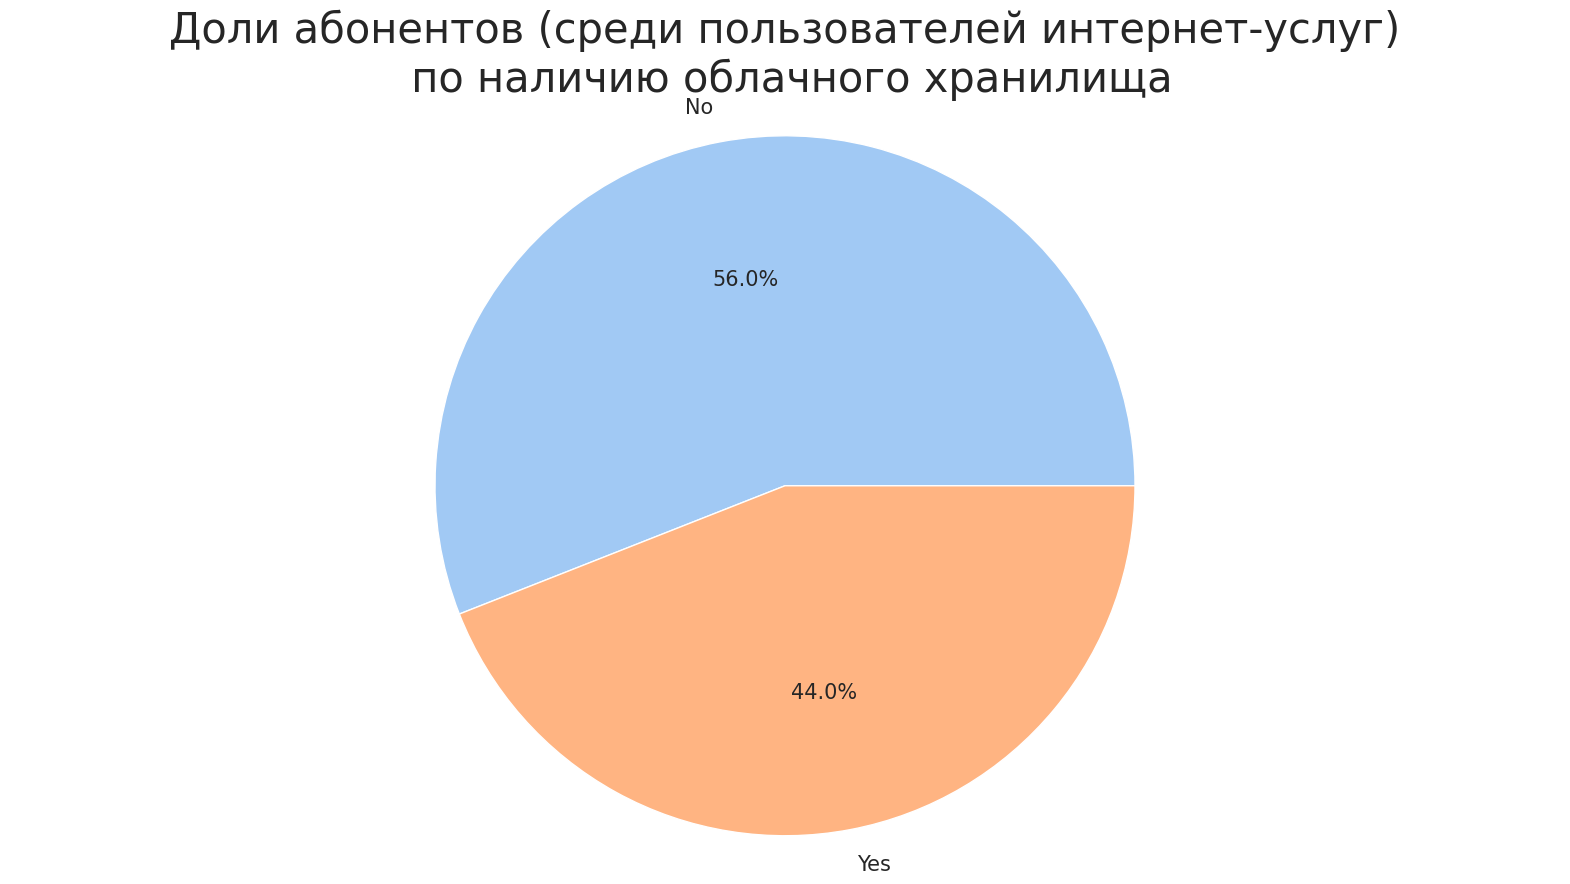

In [ ]:
# визуализируем по наличию облачного хранилища
internet['online_backup'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по наличию облачного хранилища', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большая часть клиентов из тех, кто пользуется интернет-услугами не использует услугу облачного хранилища. Возможно, они пользуются облачным хранилищем от другого поставщика услуги, либо не используют его вовсе.

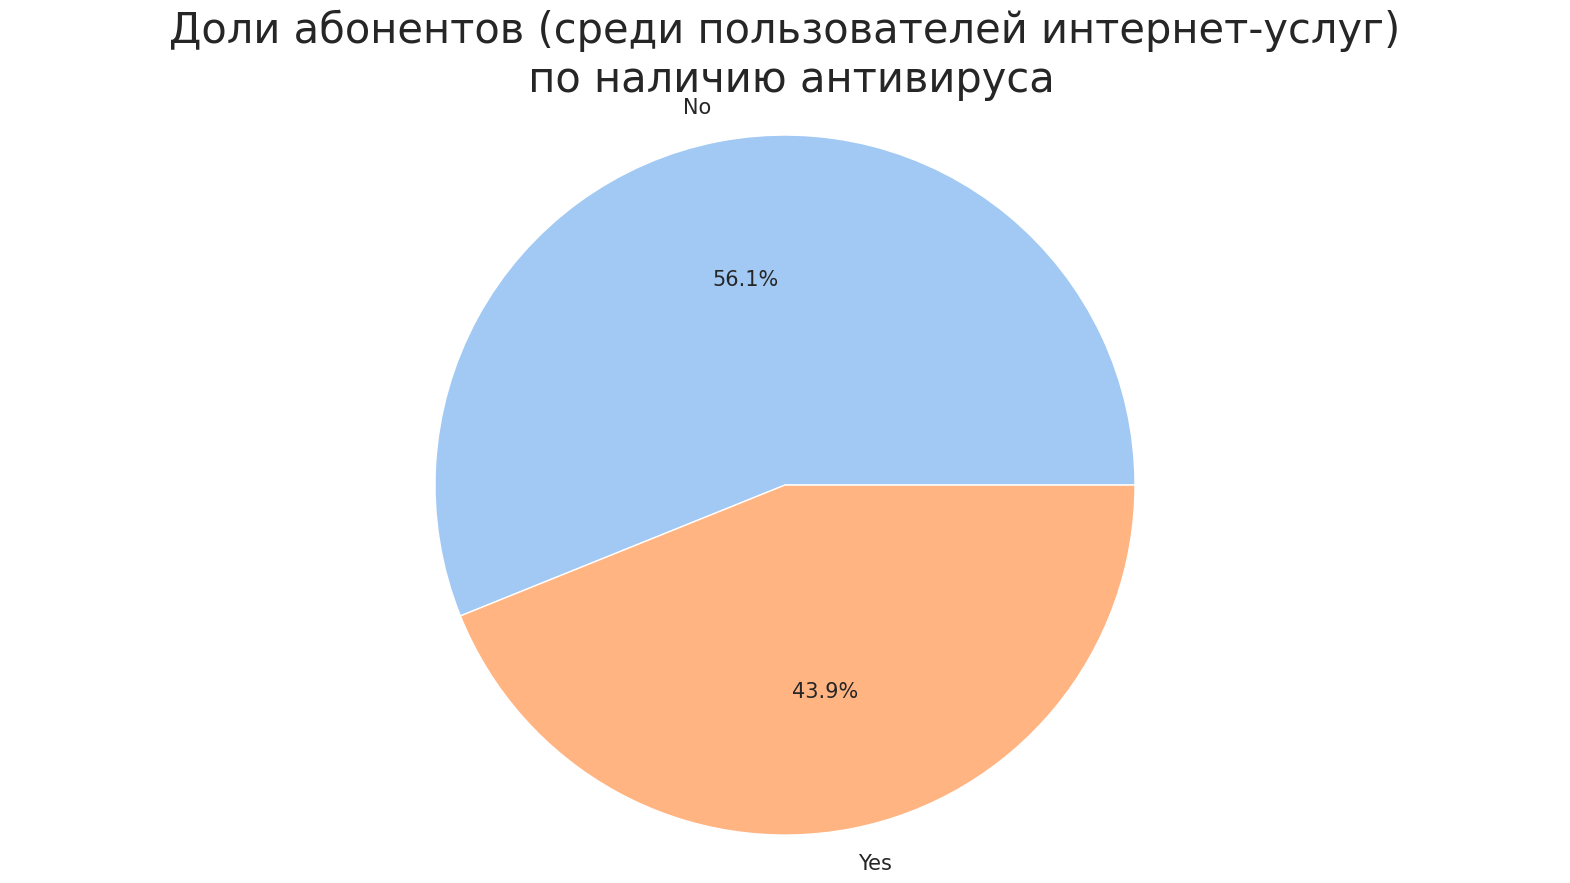

In [ ]:
# визуализируем по наличию антивируса
internet['device_protection'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по наличию антивируса', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Больше половины клиентов из тех, кто пользуется интернет-услугами не использует услугу по предоставлении антивируса от нашего заказчика. Возможно, они пользуются встроенными защитными функциями системы своих устройств либо используют антивирус от других поставщиков.

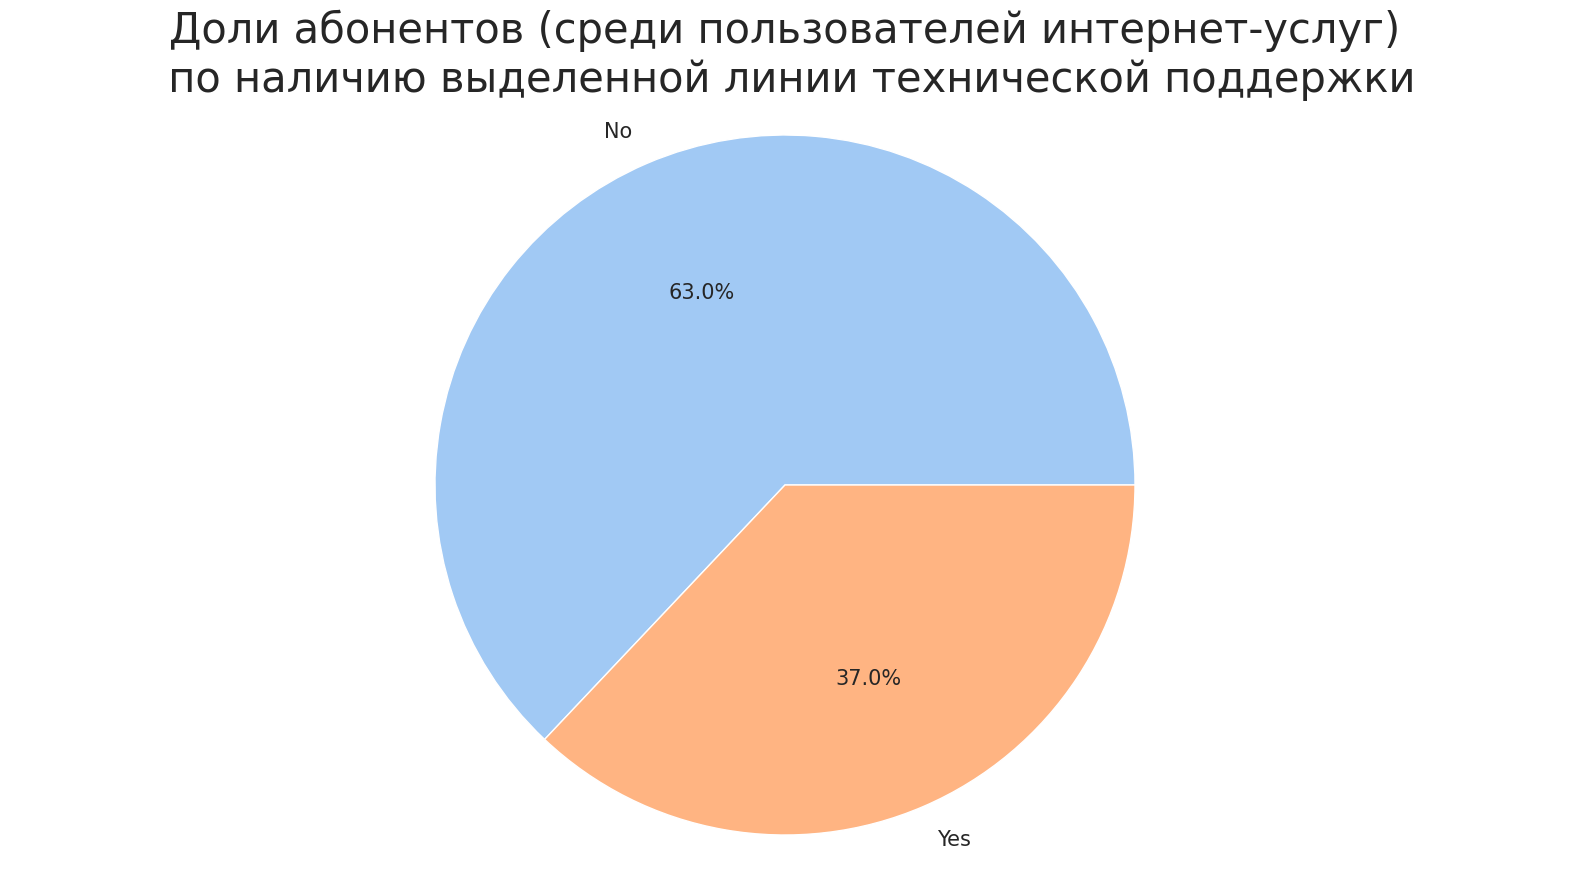

In [ ]:
# визуализируем по наличию выделенной линии технической поддержки
internet['tech_support'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по наличию выделенной линии технической поддержки', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большинство клиентов среди тех, кто пользуется интернет-услугами, не использует услугу по наличию выделенной линии техподдержки. Это вполне логично, так как при качественной работе интернет-услуг необходимость обращаться в техподдержку не слишком велика для большиства клиентов.

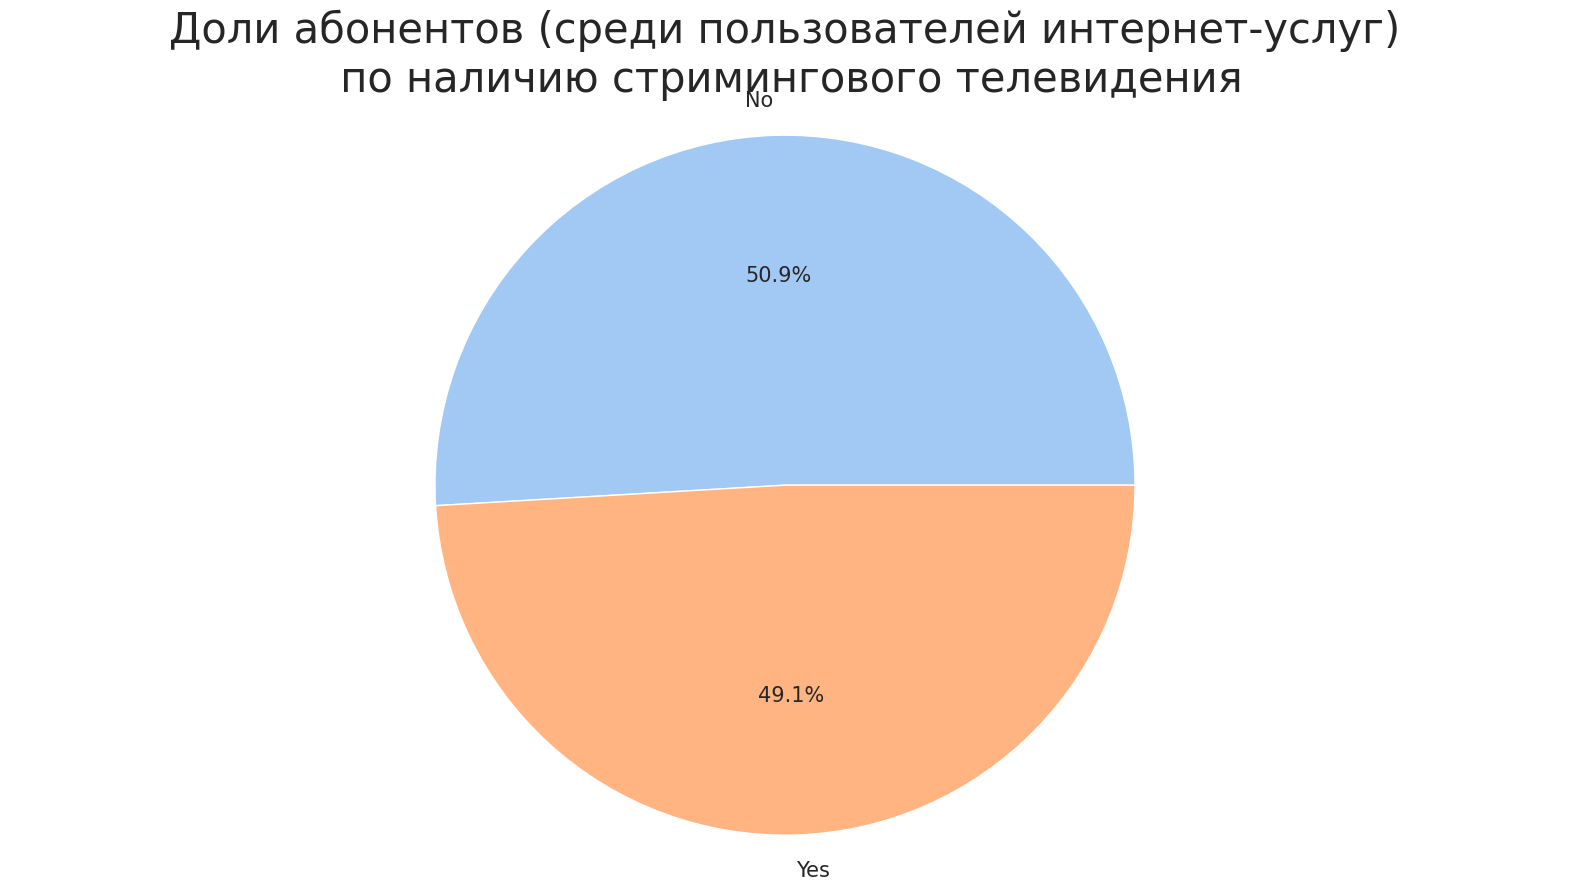

In [ ]:
# визуализируем по наличию стримингового телевидения
internet['streaming_tv'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по наличию стримингового телевидения', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доли тех, кто использует и не использует услугу стримингового телевидения среди пользователей интернет услуг сопоставимы.

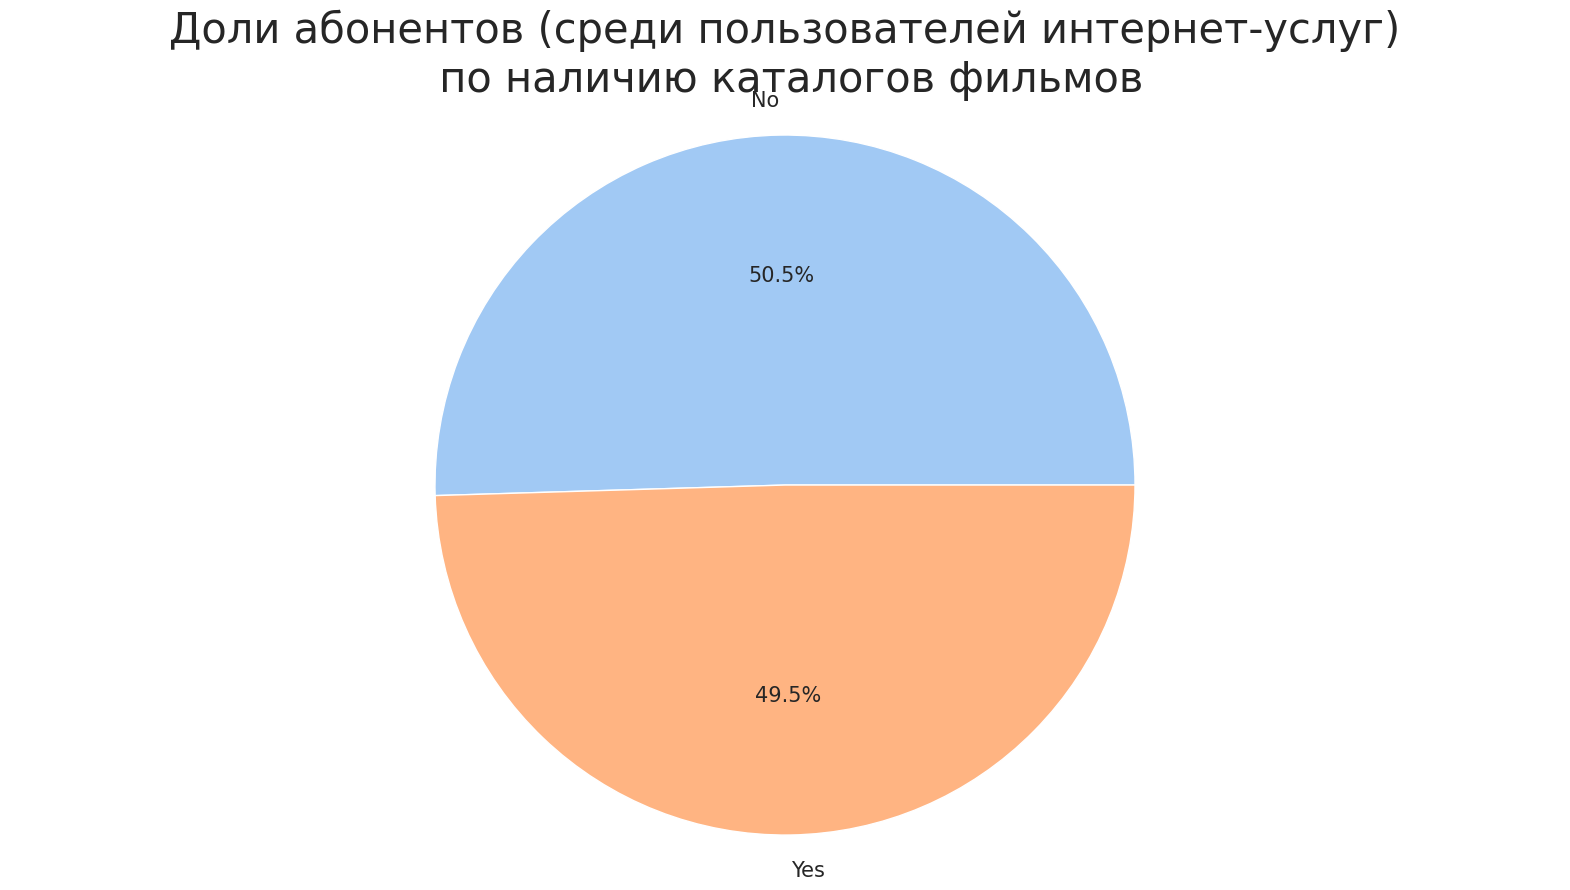

In [ ]:
# визуализируем по наличию каталогов фильмов
internet['streaming_movies'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей интернет-услуг)\n по наличию каталогов фильмов', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Доли клиентов, пользующихся и не пользующихся каталогами фильмов среди пользователей интернет-услуг сопоставимы.

### **`phone`**

Здесь мы также изучим в разрезе пользователей услуги.

In [ ]:
# вспоминаем названия столбцов
phone.columns

Index(['customer_id', 'multiple_lines'], dtype='object')

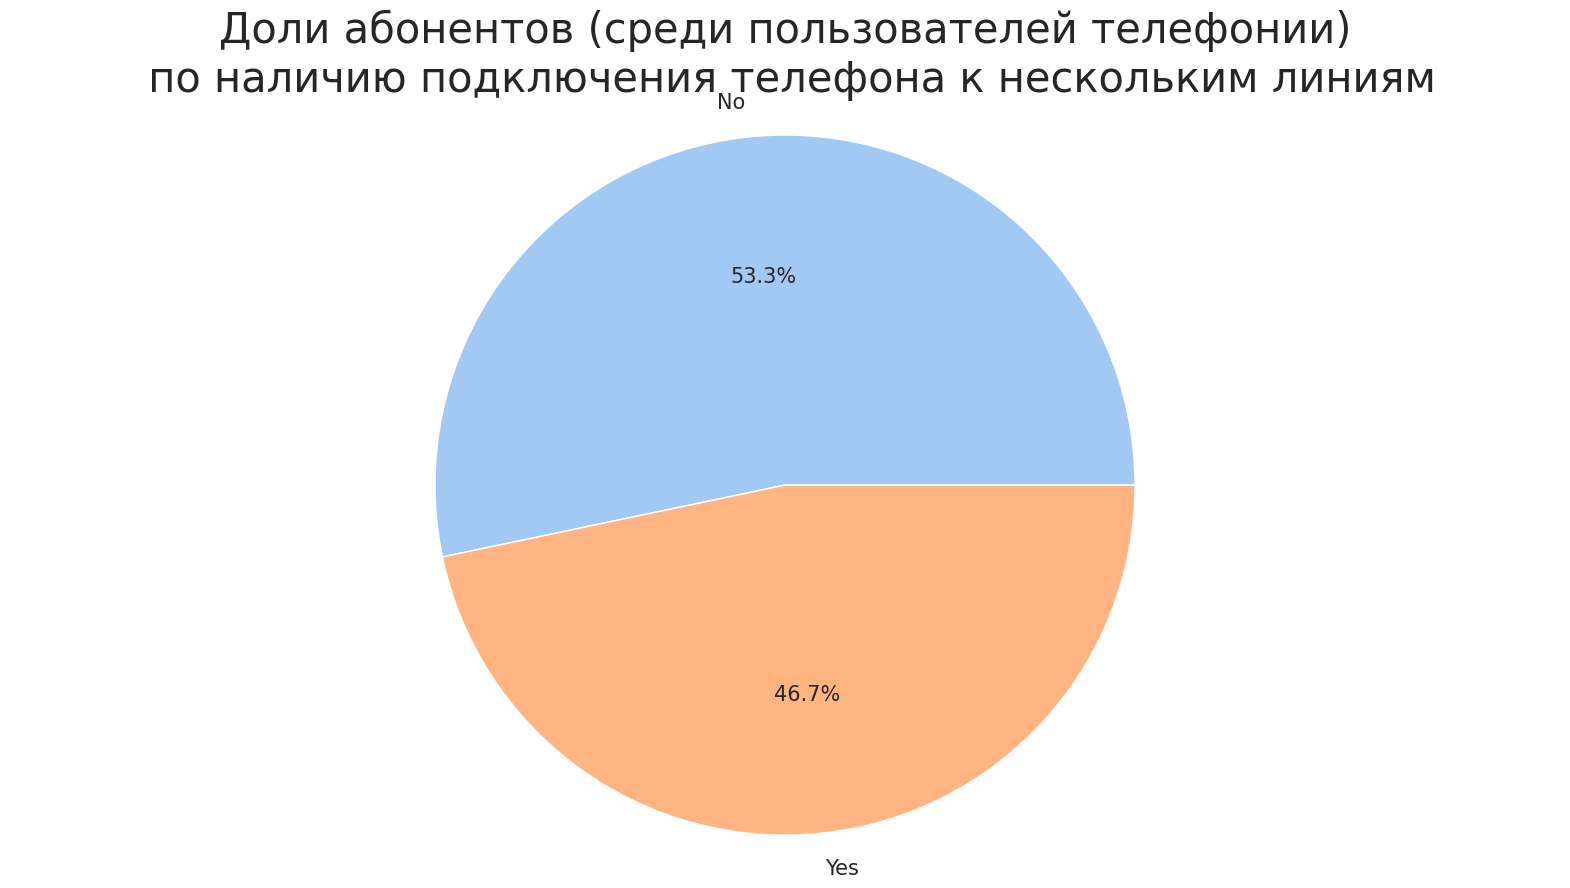

In [ ]:
# визуализируем по наличию подключения телефона к нескольким линиям
phone['multiple_lines'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди пользователей телефонии)\n по наличию подключения телефона к нескольким линиям', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Больше половины пользователей телефонии не используют услугу подключения телефона к нескольким линиям одновременно. Что выглядит логичным, ведь такая услуга обычно больше полезна огранизациям, чем обычным абонентам.

### **Выводы**

Мы изучили каждую таблицу по-отдельности.

Для таблицы `'contract'` (информация о договорах с клиентами) мы обнаружили, что:
- Контракты за исследуемый период заключались относительно равномерно.
- Небольшое количество контрактов, попавших в базу данных, были заключены еще в 2013 году. Большая их часть все еще действует, соответственно и общая сумма трат у таких клиентов большая.
- Самые ранние контракты из попавших в базу были расторгнуты в 2014 году. Таких контрактов немного и суммы общих трат у них разные.
- Большая часть (55%) клиентов предпочитают оплачивать услуги ежемесячно. Доли абонентов, оплачивающих два раза в год и раз в год составляют 24,1% и 20,9% соответственно.
- Большая часть клиентов (59,2%) имеет электронный расчетный лист.
- По способу оплаты большинство (33,6%) с небольшим перевесом относительно других вариантов составляет электронная оплата. Доли остальных вариантов (оплата по почте, автоматическая через банковский перевод, автоматический с кредитной карты) довольно близки (22,9%, 21,9% и 21,6% соответственно).
- Для ежемесячных трат:
  - Гистограмма ежемесячных трат имеет несколько пиков (то есть у нас три условные группы клиентов). Среднее и медиана не слишком близки, выбросы не обнаружены. Это можно вероятно объяснить разным количеством подключенных услуг либо разными тарифами в разный период времени.
  - Никто из клиентов не потратил менее 18 или более 119 условных единиц за месяц, средняя трата составила около 70 единиц.
- Для общих трат за период действия контракта:
 - Гистограмма распределения общих трат имеет один пик и смещена влево. Что можно предварительно объяснить тем, что многие абоненты пользуются небольшим количеством услуг, а также у нас не так много (относительно всей выборки) клиентов-"долгожителей".
  - Средняя и медина сильно отличаются, что вместе с большим стандартным отклонением говорит о неравномерности данных в выборке. Средняя сумма трат составила около 1345 условных единиц за период действия контракта.
  - Также обнаружены аномалии. При их изучении заметили, что таких клиентов много, и все они являются "долгожителями" - заключили договор еще в начале переиода наблюдения, и практически все из них являются абонентами на момент выгрузки данных. То есть это - "особая група" и мы не можем исключить данных клиентов из выборки.

Для таблицы `'personal'` (персональные данные клиентов):
  - По полу доли клиентов практически равны. Мужчин лишь ненамного больше (50.5%), чем женщин (49.5%).
  - Доля пенсионеров (16.2%) гораздо меньше тех, кто ими не является (83.8%).
  - Доли имеющих и не имеющих супруга/супруги абонентов сопоставимы (48.3% и 51.7% соттветственно).
  - Большая часть (70%) абонентов не имеет детей.

Для таблицы `'internet'` (информация об интернет-услугах) - лишь те абоненты, которые пользуются интернет-услугами:
- Большая часть (56.1%) этих клиентов подключены с помощью оптоволоконного кабеля, что говорит о стремлении компании к новым технологиям.
- Большая часть этих клиентов (63.4%) не использует услугу блокировки опасных сайтов от нашего заказчика. Возможно, они справляются с проблемой собственными силами (например, установкой специализированного ПО на личном ПК), либо по каким-либо причинам не считают важным наличие данной возможности.
- Больше половины этих клиентов (56%) не использует услугу облачного хранилища от нашего заказчика. Возможно, они пользуются облачным хранилищем от другого поставщика услуги, либо не используют его вовсе.
- Больше половины этих клиентов (56.1%) не использует услугу по предоставлении антивируса от нашего заказчика. Возможно, они пользуются встроенными защитными функциями системы своих устройств либо используют антивирус от других поставщиков.
- Большинство этих клиентов (63%) не использует услугу по наличию выделенной линии техподдержки. Это вполне логично, так как при качественной работе интернет-услуг необходимость обращаться в техподдержку не слишком велика для большиства клиентов.
- Доли тех, кто использует и не использует услугу стримингового телевидения среди пользователей интернет услуг сопоставимы (49.1% и 50.9% соответственно).
- Доли клиентов, пользующихся и не пользующихся каталогами фильмов среди пользователей интернет-услуг сопоставимы (49.5% и 50.5%).

Для таблицы `'phone'` (информация об слугах телефонии):
- Больше половины (53.3%) пользователей телефонии не используют услугу подключения телефона к нескольким линиям одновременно. Что выглядит логичным, ведь такая услуга обычно больше полезна огранизациям, чем обычным абонентам.



## **Дополнительная работа**

### **Дополнительная работа с данными, создание и анализ новых признаков**

Создадим целевой признак сразу в закодированном виде (клиент расторг контракт - 1, клиент остался - 0).

In [ ]:
# создаём столбец exit: 1 если есть дата (ушел), 0 если NaT (остался)
contract['exit'] = (~contract['end_date'].isna()).astype(int)
contract.head(10)  # проверка

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,exit
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84",0
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60",0
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0
5,9305-CDSKC,2019-03-01,NaT,Month-to-month,Yes,Electronic check,99.65,"1,150.96",0
6,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,"2,058.21",0
7,6713-OKOMC,2019-04-01,NaT,Month-to-month,No,Mailed check,29.75,300.48,0
8,7892-POOKP,2017-07-01,NaT,Month-to-month,Yes,Electronic check,104.80,"3,573.68",0
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,"1,628.35",1


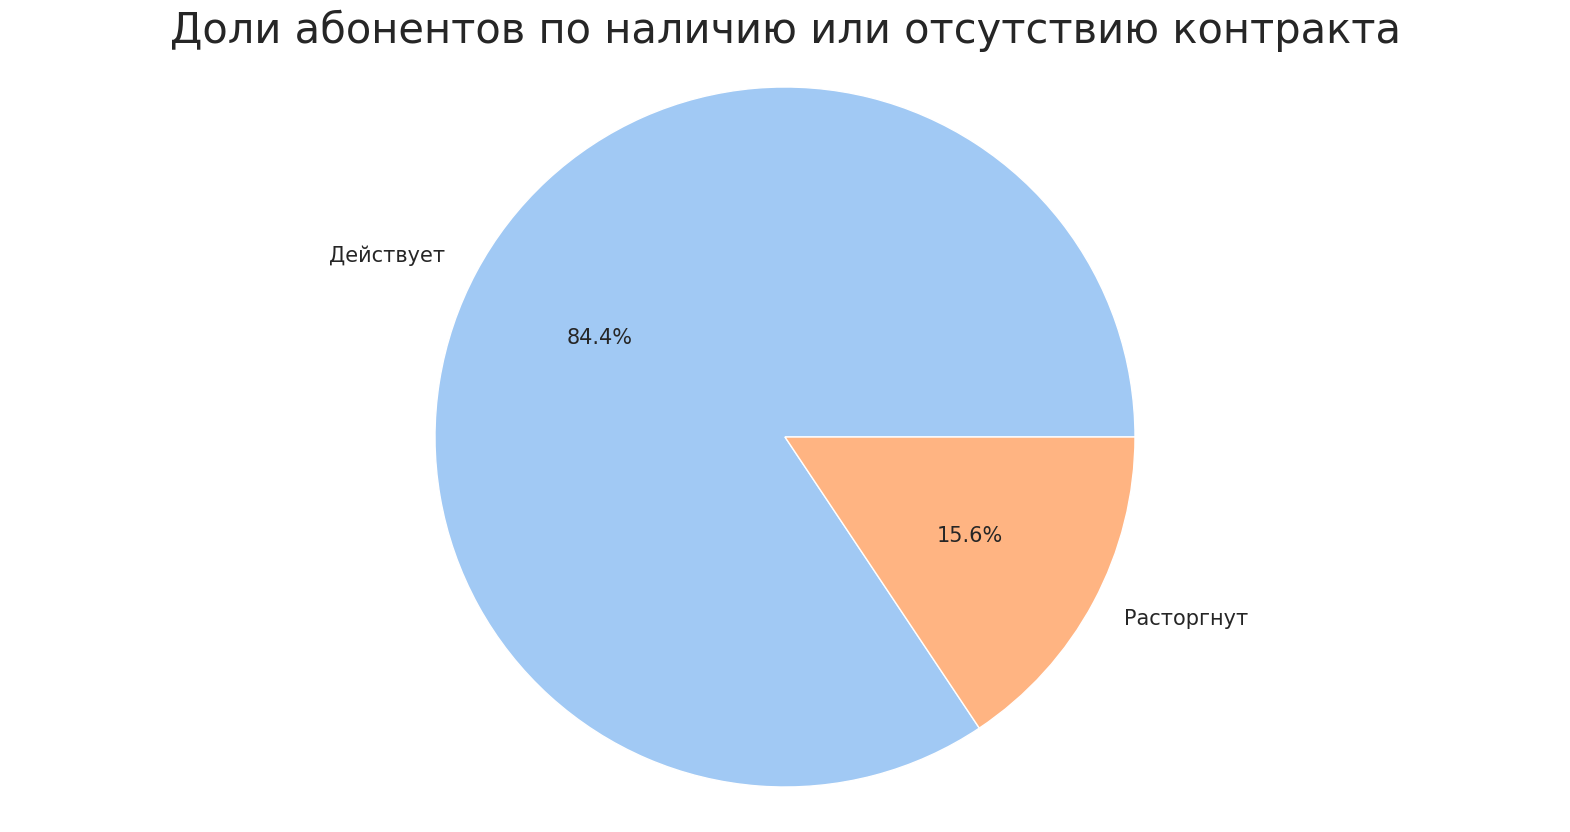

In [ ]:
# визуализируем доли оставшихся и ушедших клиентов
contract['exit'].value_counts().plot(kind='pie',
                                   labels=['Действует', 'Расторгнут'],  # добавлены подписи
                                   grid=True,
                                   figsize=(20,10),
                                   fontsize=15,
                                   autopct='%1.1f%%')

plt.title('Доли абонентов по наличию или отсутствию контракта', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Признак успешно создан, и доля ушедших клиентов совпадает с ранее наблюдавшейся при изучении пропусков (с поправкой на округление).

Создадим новый признак - длительность действия контракта в днях как более информативный, чем даты.

In [ ]:
# создаем функцию для получения разницы в днях между датами
def lftm(df):
    df['date'] = df['end_date'] # копируем столбец с датой расторжения
    df['date'] = df['date'].fillna(datetime.strptime('2020-02-01', '%Y-%m-%d')) # заполняем пропуски датой загрузки
    df['contract_day'] = (df['date'] - df['begin_date']).dt.days # сохраняем количество дней разницы
    df = df.drop('date', axis=1)
    return df

In [ ]:
# применяем функцию
contract = lftm(contract)
contract.head(10) # проверка

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,exit,contract_day
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0,31
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84",0,1036
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0,123
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60",0,1371
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0,153
5,9305-CDSKC,2019-03-01,NaT,Month-to-month,Yes,Electronic check,99.65,"1,150.96",0,337
6,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,"2,058.21",0,671
7,6713-OKOMC,2019-04-01,NaT,Month-to-month,No,Mailed check,29.75,300.48,0,306
8,7892-POOKP,2017-07-01,NaT,Month-to-month,Yes,Electronic check,104.80,"3,573.68",0,945
9,6388-TABGU,2014-12-01,2017-05-01,One year,No,Bank transfer (automatic),56.15,"1,628.35",1,882


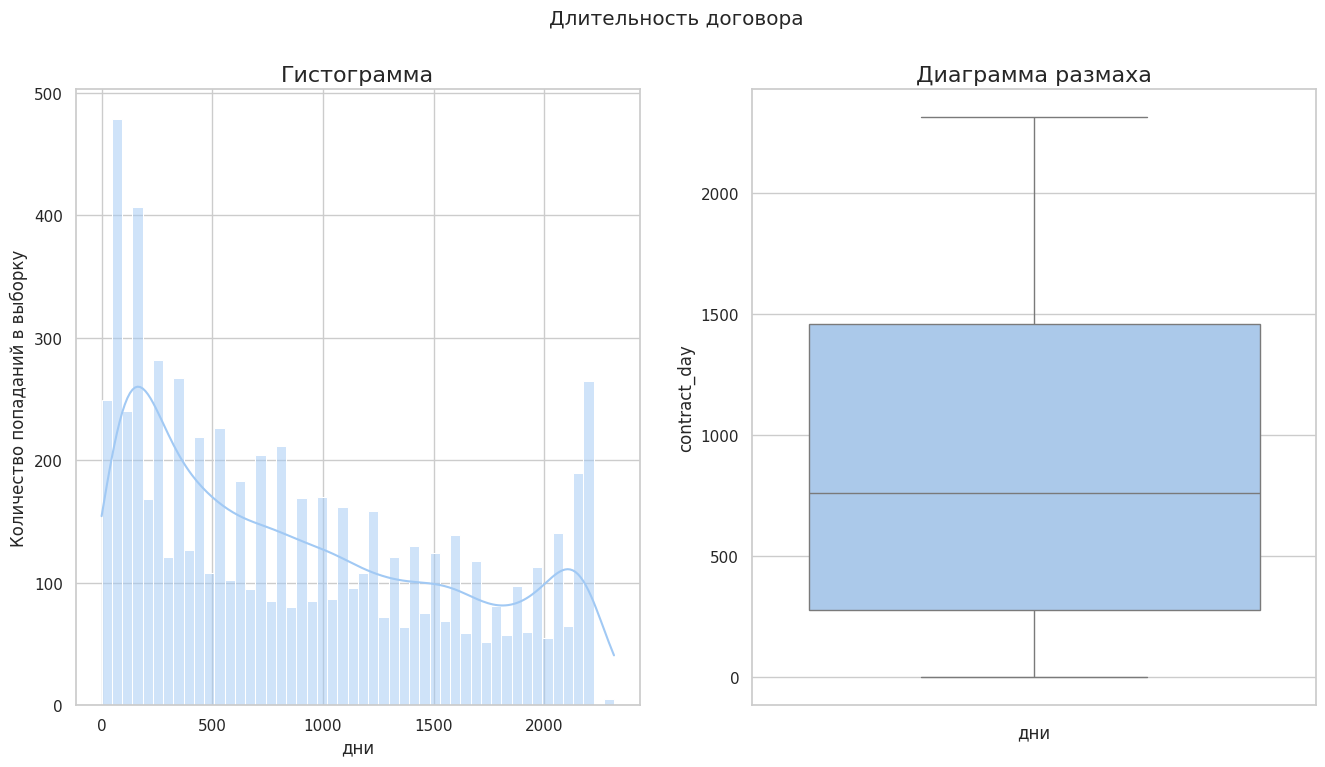

count   7,043.00
mean      898.56
std       683.13
min         0.00
25%       276.00
50%       761.00
75%     1,461.00
max     2,314.00
Name: contract_day, dtype: float64


In [ ]:
# визуализируем по количеству дней контракта
# Вызов функции discr_num и ее вывод
print(discr_num(contract['contract_day'],
                   'Длительность договора',
                   'дни'))

Гистограмма распределения имеет несколько пиков, первый из которых смещен влево. Возможно, около года назад проходила какая-либо акция, привлекшая много новых клиентов, большая часть которых все еще осталсь абонентами заказчика.

Вторым пиком являются клиенты-старожилы, которых мы наблюдали ранее.

Выбросы не обнаружены.

Средняя и медиана не близки, что вместе с большим стандартным отклонением говорит о неравномерности в данных. Средняя длительность контракта - около 900 дней.

Чтобы работать дальше и провести некоторый анализ уже в разрезе всех абонентов, которых мы отберем в работу с моделями, нам необходимо объединить таблицы.

In [ ]:
# объединяем первые две таблицы
full_df = contract.merge(personal, on='customer_id', how='left') # объединение
full_df.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   exit               7043 non-null   int64         
 9   contract_day       7043 non-null   int64         
 10  gender             7043 non-null   object        
 11  senior_citizen     7043 non-null   object        
 12  partner            7043 non-null   object        
 13  dependents         7043 non-null   object        
dtypes: datet

Присоединение прошло успешно - то есть о каждом из клиентов в данных имеется персональная информация.

In [ ]:
# присоединяем третью
full_df = full_df.merge(internet, on='customer_id', how='left') # объединение
full_df.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   exit               7043 non-null   int64         
 9   contract_day       7043 non-null   int64         
 10  gender             7043 non-null   object        
 11  senior_citizen     7043 non-null   object        
 12  partner            7043 non-null   object        
 13  dependents         7043 non-null   object        
 14  internet

In [ ]:
# присоединяем четвертую
full_df = full_df.merge(phone, on='customer_id', how='left') # объединение
full_df.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
 8   exit               7043 non-null   int64         
 9   contract_day       7043 non-null   int64         
 10  gender             7043 non-null   object        
 11  senior_citizen     7043 non-null   object        
 12  partner            7043 non-null   object        
 13  dependents         7043 non-null   object        
 14  internet

Количество и доля пропусков в full_df:


,Количество,"Доля, %"
customer_id,0,0.00
begin_date,0,0.00
end_date,5942,84.37
type,0,0.00
paperless_billing,0,0.00
payment_method,0,0.00
monthly_charges,0,0.00
total_charges,11,0.16
exit,0,0.00
contract_day,0,0.00




 === Визуализация пропусков в full_df: ===



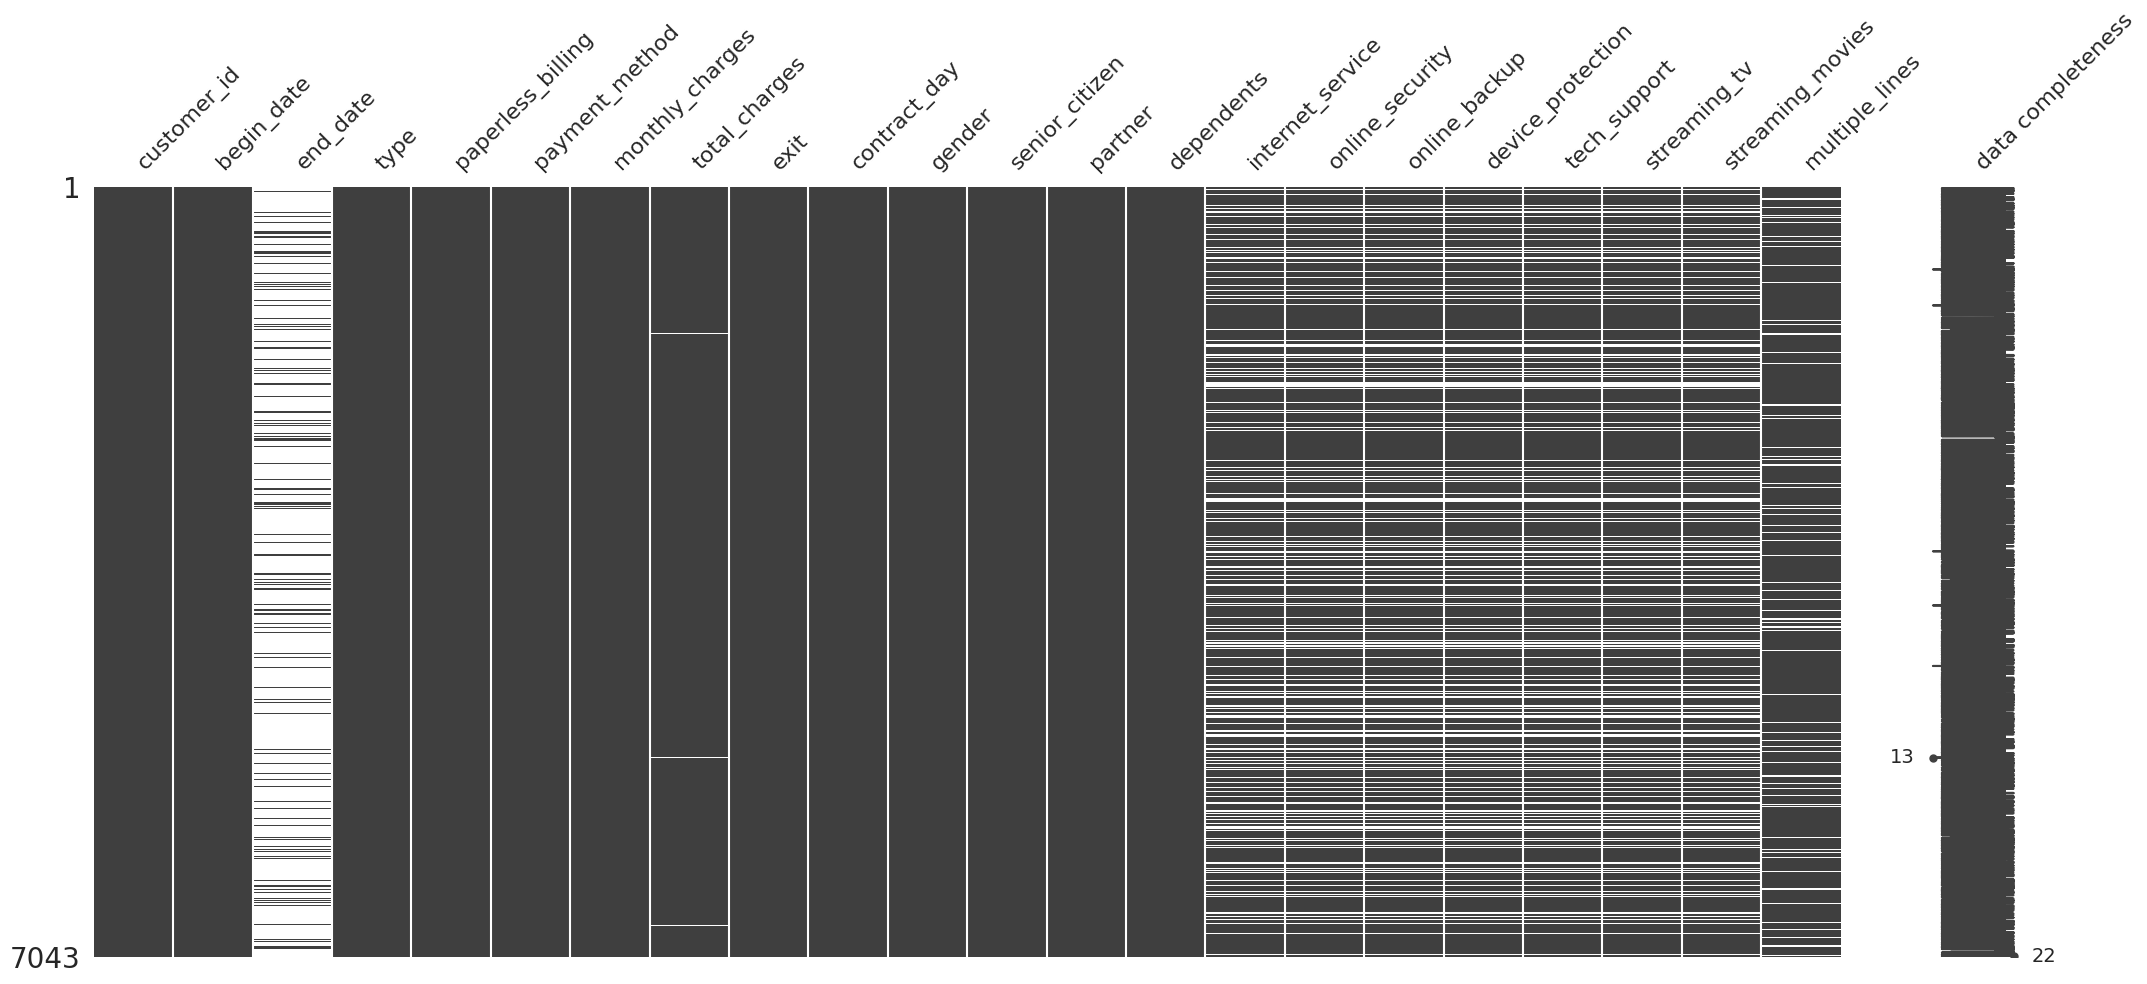

In [ ]:
# смотрим структуру пропусков
pass_miss(full_df,'full_df')

Появились пропуски, что логично, ведь не все клиенты пользуются сразу двумя услугами.

Заполним пропуски указанием на это.

In [ ]:
# заполняем пропуски в пересекающихся столбцах
full_df[full_df.columns.intersection(internet.columns)] = full_df[full_df.columns.intersection(internet.columns)].fillna('No used internet')
full_df[full_df.columns.intersection(phone.columns)] = full_df[full_df.columns.intersection(phone.columns)].fillna('No used phone')
# проверяем успешность замены
full_df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,exit,contract_day,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No used phone
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84",0,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60",0,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No used phone
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


Количество и доля пропусков в full_df:


,Количество,"Доля, %"
customer_id,0,0.00
begin_date,0,0.00
end_date,5942,84.37
type,0,0.00
paperless_billing,0,0.00
payment_method,0,0.00
monthly_charges,0,0.00
total_charges,11,0.16
exit,0,0.00
contract_day,0,0.00




 === Визуализация пропусков в full_df: ===



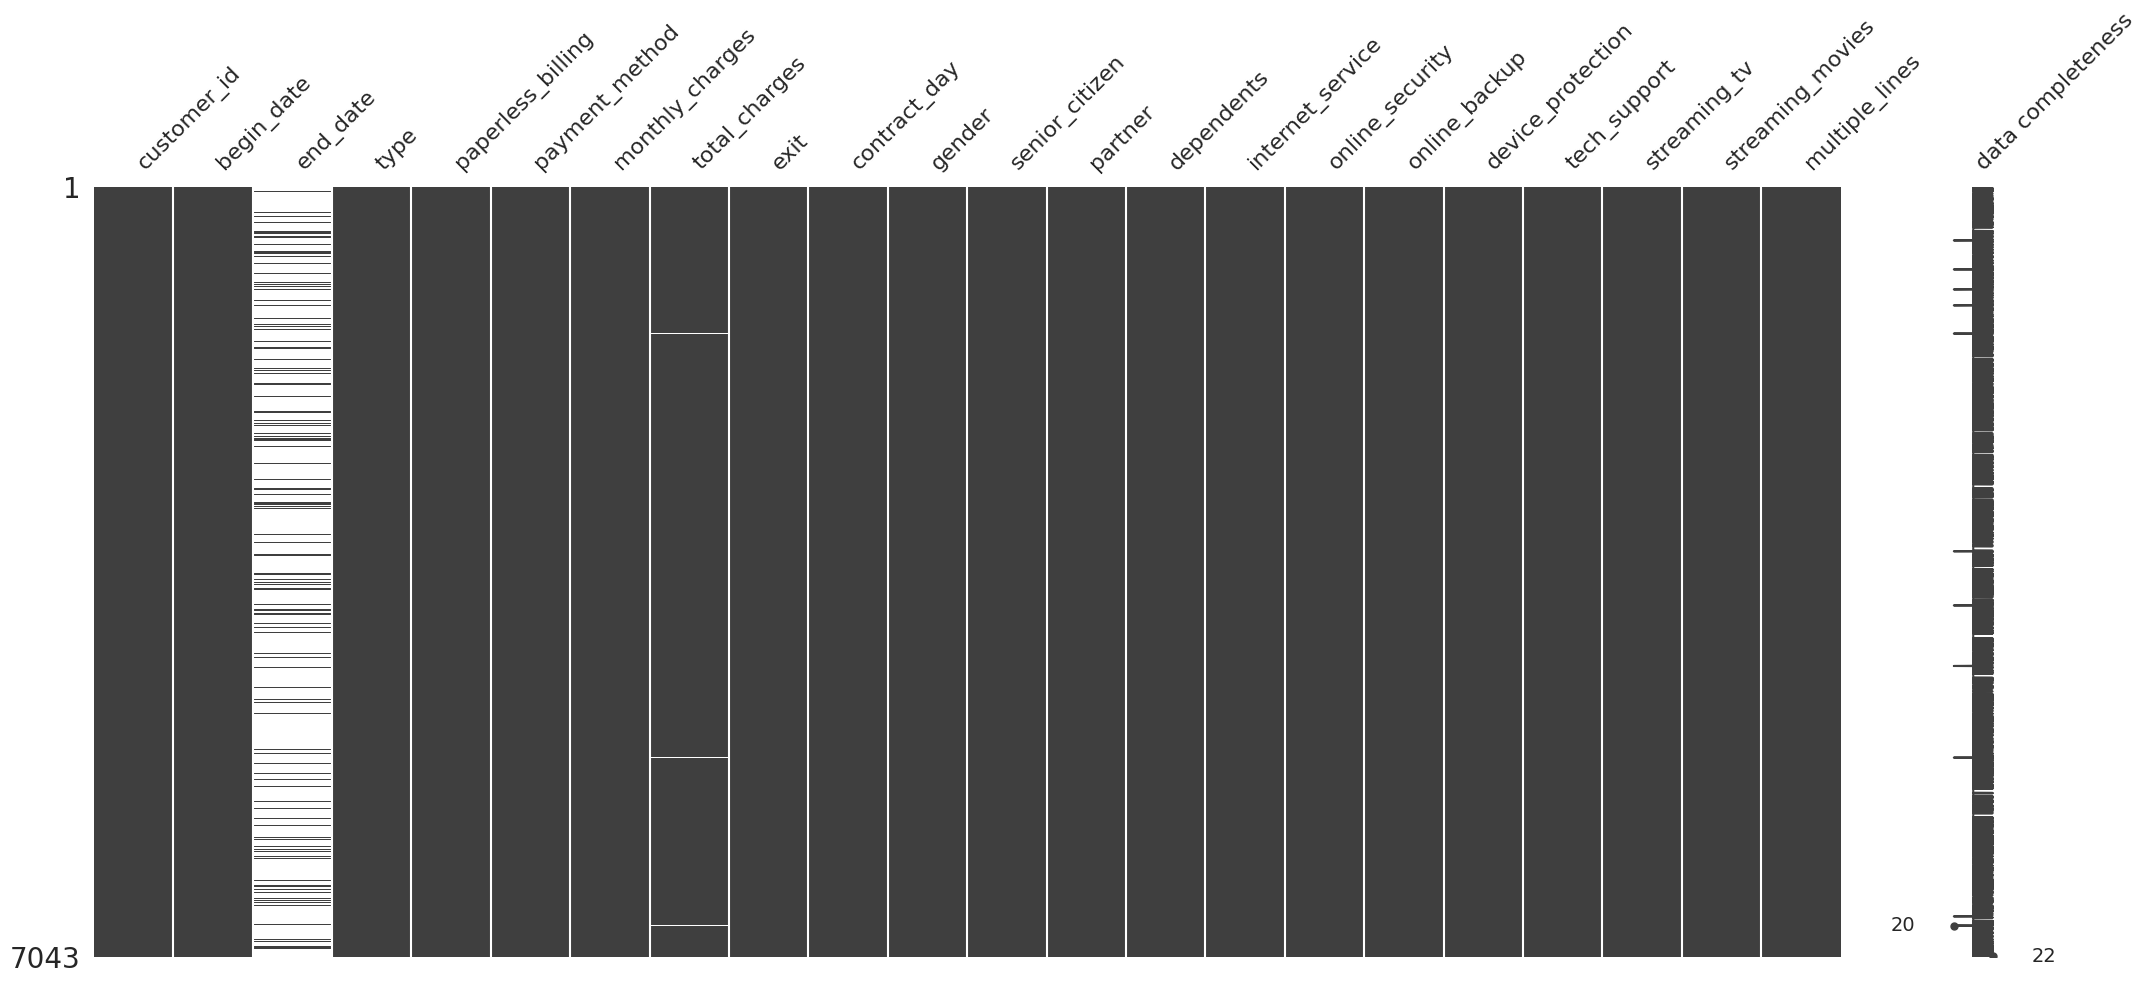

In [ ]:
# смотрим структуру пропусков
pass_miss(full_df,'full_df')

Также для большей наглядности создадим столбец с указанием количества используемых интернет услуг.

In [ ]:
# создаем новый столбец 'num_int_options' с количеством "Yes" в каждой строке, относящейся к интернет-услугам
full_df['num_int_options'] = (full_df[full_df.columns.intersection(internet.columns)] == 'Yes').sum(axis=1)
# задаем тип категория, так как "полноценночисловым" он не является: имеет ограниченное количество вариантов и четкую иерархию
full_df['num_int_options'] = full_df['num_int_options'].astype('category')
# проверка успешности создания
print(full_df['num_int_options'].dtypes)
full_df.head()

category


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,exit,contract_day,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,num_int_options
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No used phone,1
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84",0,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,2
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,2
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60",0,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No used phone,3
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,0


Как мы помним, у нас были клиенты, которые заключили контракт в день выгрузки базы. Мы не будем их удалять, чтобы модель могла обучиться оценке риска оттока новых клиентов.

У данных клиентов разные способы и частота оплаты. Поэтому заполним пропуски в общих тратах теми же суммами, что были уплачены ими за наступающий первый месяц пользования услугами.

In [ ]:
# заполняем пропуски
full_df['total_charges'] = full_df['total_charges'].fillna(full_df['monthly_charges'])
full_df.info() # проверяем

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1101 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   exit               7043 non-null   int64         
 9   contract_day       7043 non-null   int64         
 10  gender             7043 non-null   object        
 11  senior_citizen     7043 non-null   object        
 12  partner            7043 non-null   object        
 13  dependents         7043 non-null   object        
 14  internet

Создадим новый датасет для будущей работы.

In [ ]:
# создаем копию для будущей работы
full_df_new = full_df.copy()
full_df_new.head() # проверка

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,exit,contract_day,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,num_int_options
0,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,31.04,0,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No used phone,1
1,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,"2,071.84",0,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,2
2,3668-QPYBK,2019-10-01,NaT,Month-to-month,Yes,Mailed check,53.85,226.17,0,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,2
3,7795-CFOCW,2016-05-01,NaT,One year,No,Bank transfer (automatic),42.30,"1,960.60",0,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No used phone,3
4,9237-HQITU,2019-09-01,NaT,Month-to-month,Yes,Electronic check,70.70,353.50,0,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,0


Также удалим ненужные столбцы.

In [ ]:
# удаляем столбцы с датами, чтобы избежать утечки
full_df_new = full_df_new.drop(['begin_date', 'end_date'], axis=1)

# вызов функции discr_num и ее вывод
first_discr(full_df_new,'full_df_new', 15) # проверка


 === Первые 15 строк в full_df_new: ===



,customer_id,type,paperless_billing,payment_method,monthly_charges,total_charges,exit,contract_day,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,num_int_options
0,7590-VHVEG,Month-to-month,Yes,Electronic check,29.85,31.04,0,31,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,No used phone,1
1,5575-GNVDE,One year,No,Mailed check,56.95,"2,071.84",0,1036,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,2
2,3668-QPYBK,Month-to-month,Yes,Mailed check,53.85,226.17,0,123,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,2
3,7795-CFOCW,One year,No,Bank transfer (automatic),42.30,"1,960.60",0,1371,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No used phone,3
4,9237-HQITU,Month-to-month,Yes,Electronic check,70.70,353.50,0,153,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,0
5,9305-CDSKC,Month-to-month,Yes,Electronic check,99.65,"1,150.96",0,337,Female,0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes,3
6,1452-KIOVK,Month-to-month,Yes,Credit card (automatic),89.10,"2,058.21",0,671,Male,0,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes,2
7,6713-OKOMC,Month-to-month,No,Mailed check,29.75,300.48,0,306,Female,0,No,No,DSL,Yes,No,No,No,No,No,No used phone,1
8,7892-POOKP,Month-to-month,Yes,Electronic check,104.80,"3,573.68",0,945,Female,0,Yes,No,Fiber optic,No,No,Yes,Yes,Yes,Yes,Yes,4
9,6388-TABGU,One year,No,Bank transfer (automatic),56.15,"1,628.35",1,882,Male,0,No,Yes,DSL,Yes,Yes,No,No,No,No,No,2



 === Общая информация о данных в full_df_new: ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        7043 non-null   object  
 1   type               7043 non-null   object  
 2   paperless_billing  7043 non-null   object  
 3   payment_method     7043 non-null   object  
 4   monthly_charges    7043 non-null   float64 
 5   total_charges      7043 non-null   float64 
 6   exit               7043 non-null   int64   
 7   contract_day       7043 non-null   int64   
 8   gender             7043 non-null   object  
 9   senior_citizen     7043 non-null   object  
 10  partner            7043 non-null   object  
 11  dependents         7043 non-null   object  
 12  internet_service   7043 non-null   object  
 13  online_security    7043 non-null   object  
 14  online_backup      7043 non-null   object  
 15  dev

None


 === Размер датасета full_df_new:===
    (7043, 21)


 === Явные дубликаты в full_df_new:===
Количество: 0
Процент: 0.00 %


### **Дополнительный анализ итогового датасета**

Теперь мы дополнительно проанализируем наш датасет в разрезе интернет-услуг для всех пользователей, на которых мы будем обучать модель, с учетом ранее проведенных манипуляций над данными

Анализ по данным контрактов и персональным данным производить дополнительно не будем, так как строк удалено было не так много, а значит не ожидается существенных изменений в распределении данных.

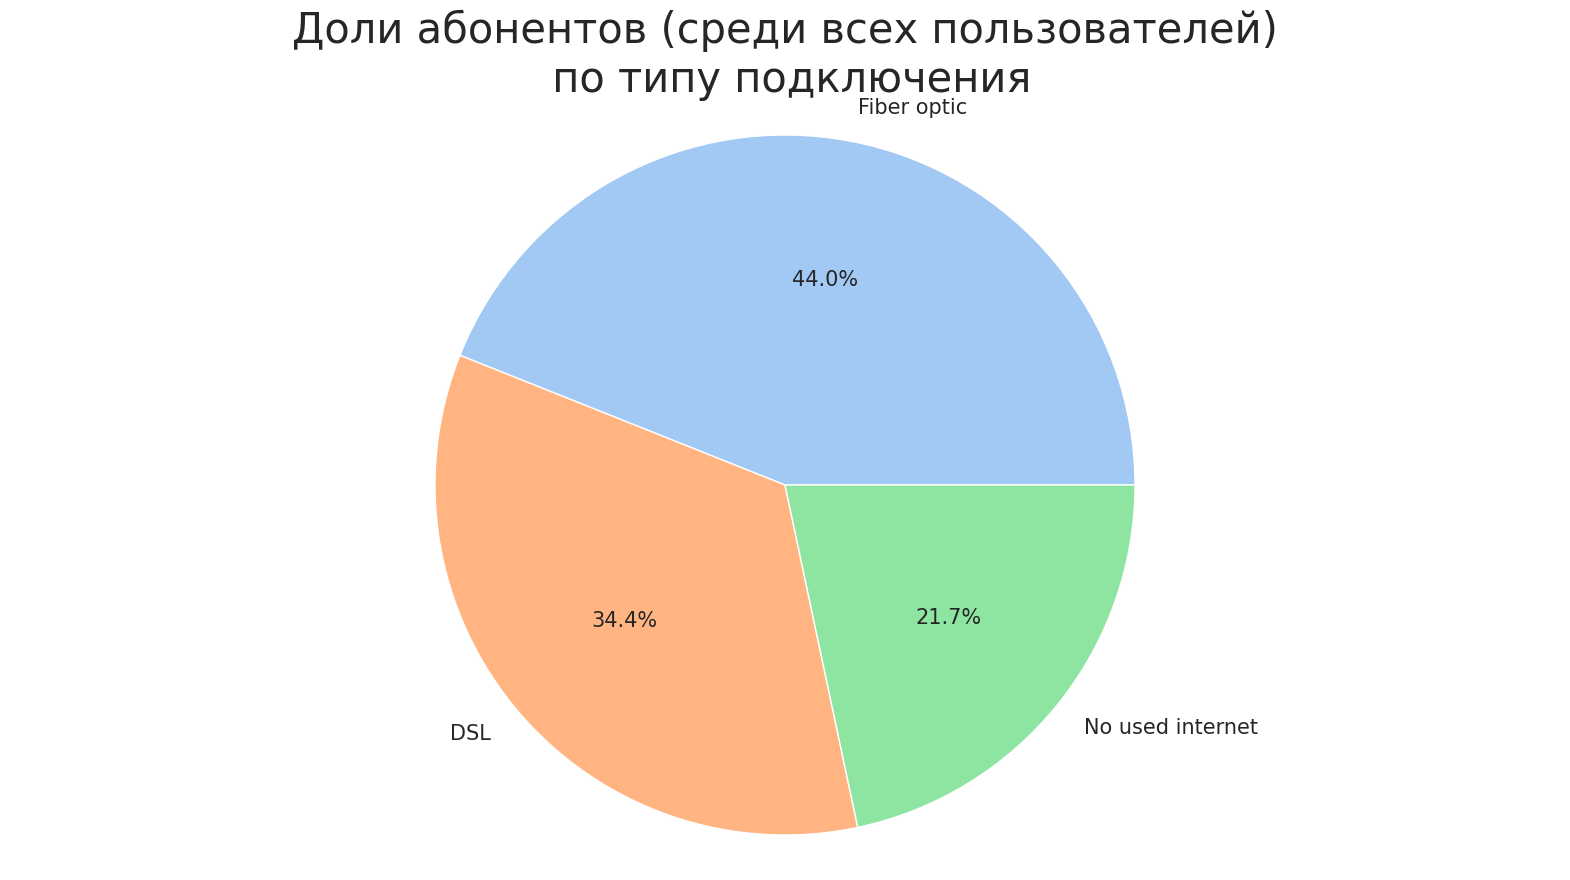

In [ ]:
# визуализируем по типу подключения
full_df_new['internet_service'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по типу подключения', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

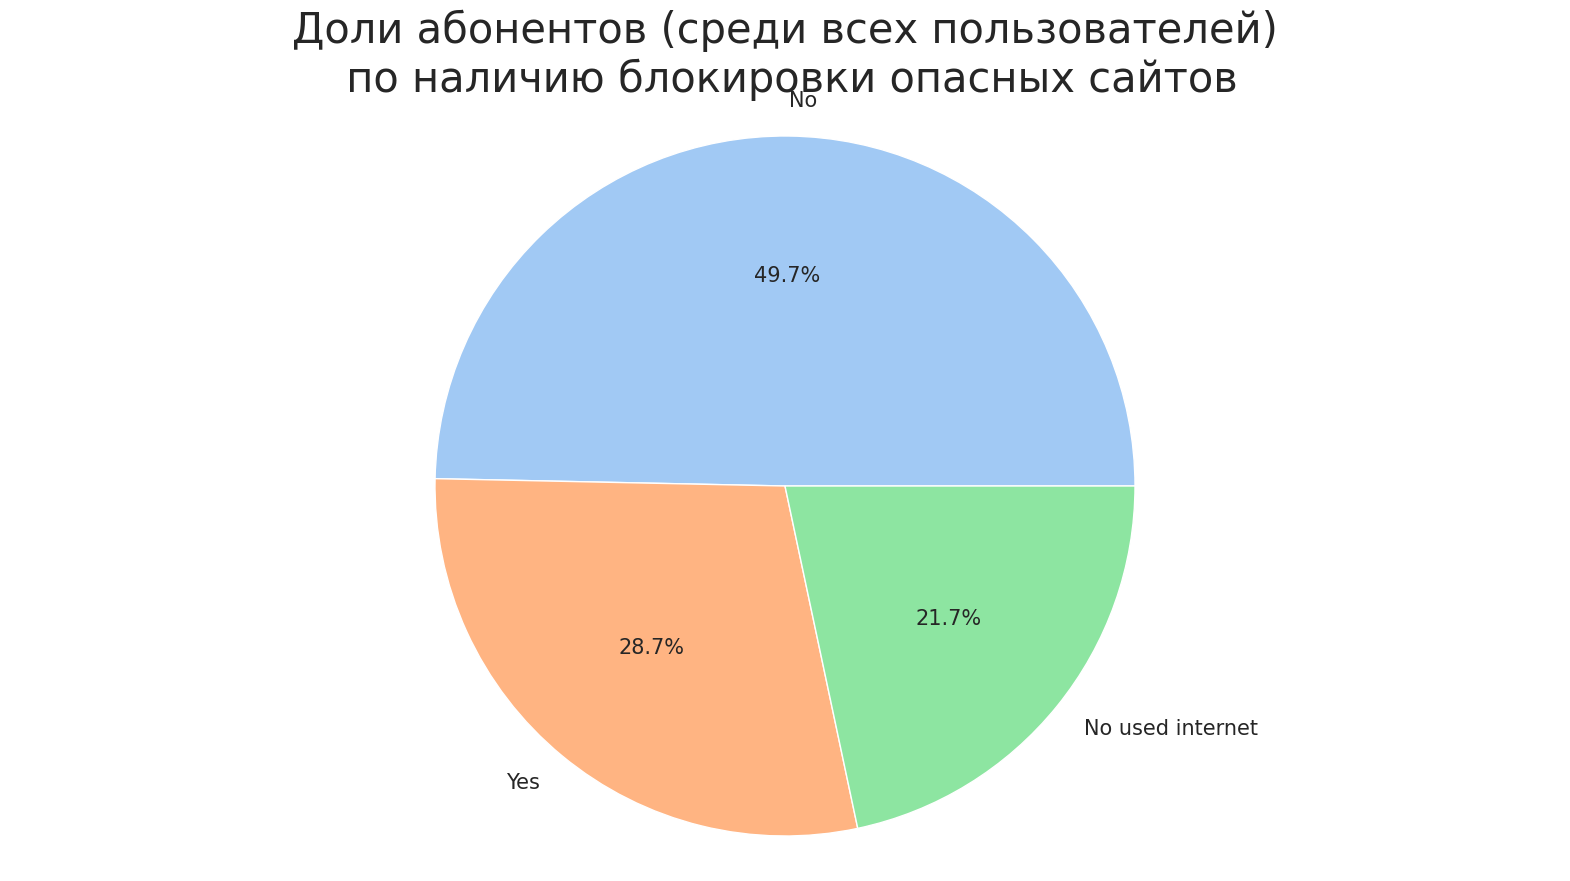

In [ ]:
# визуализируем по блокировке опасных сайтов
full_df_new['online_security'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию блокировки опасных сайтов', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

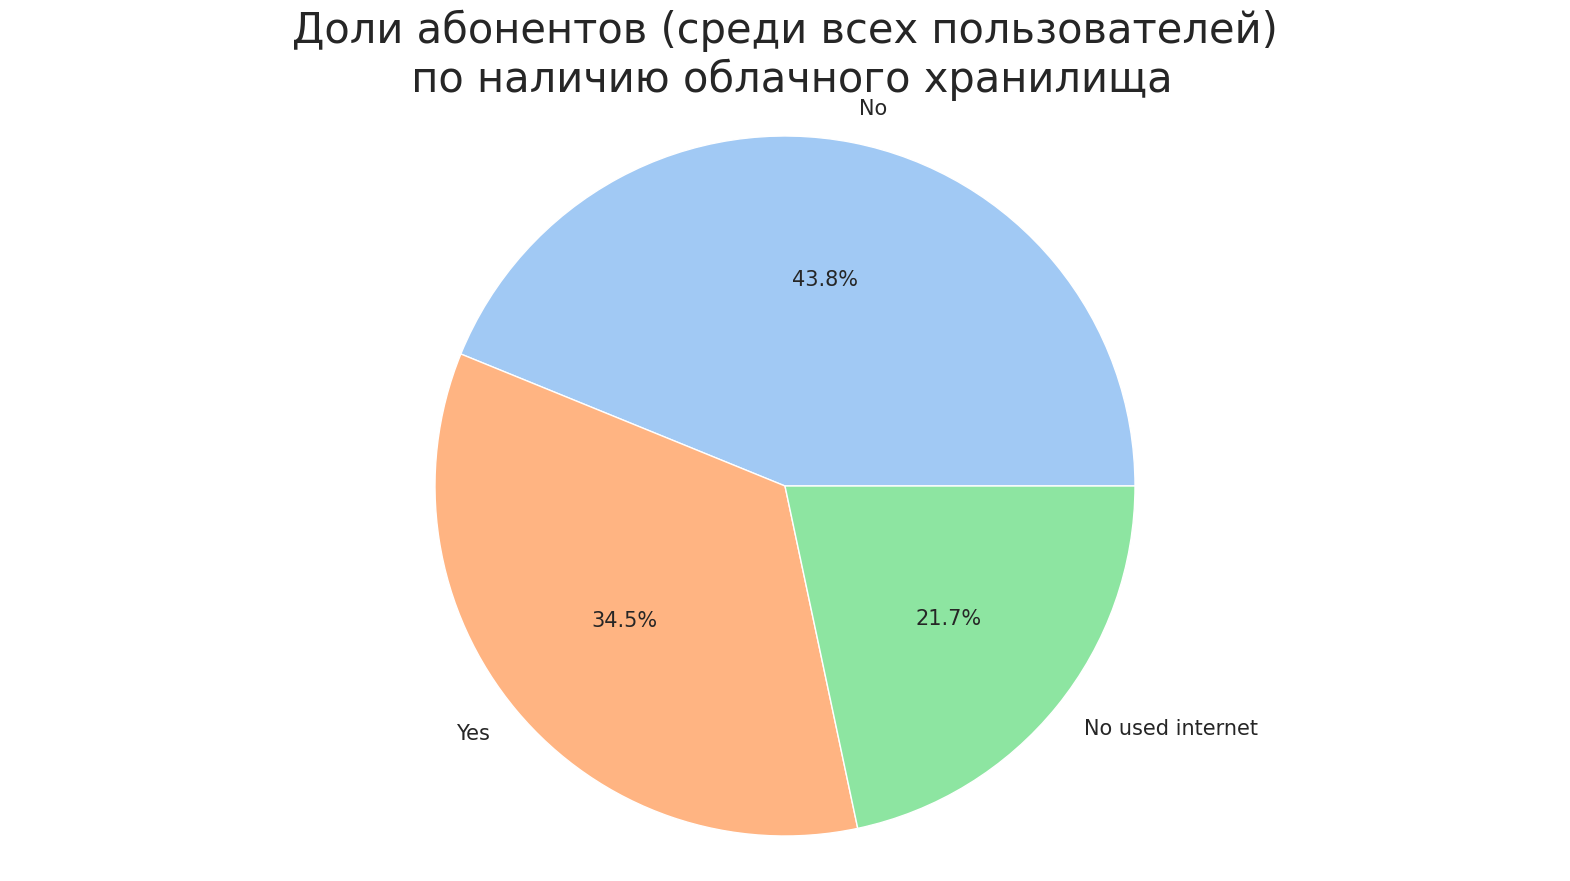

In [ ]:
# визуализируем по наличию облачного хранилища
full_df_new['online_backup'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию облачного хранилища', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

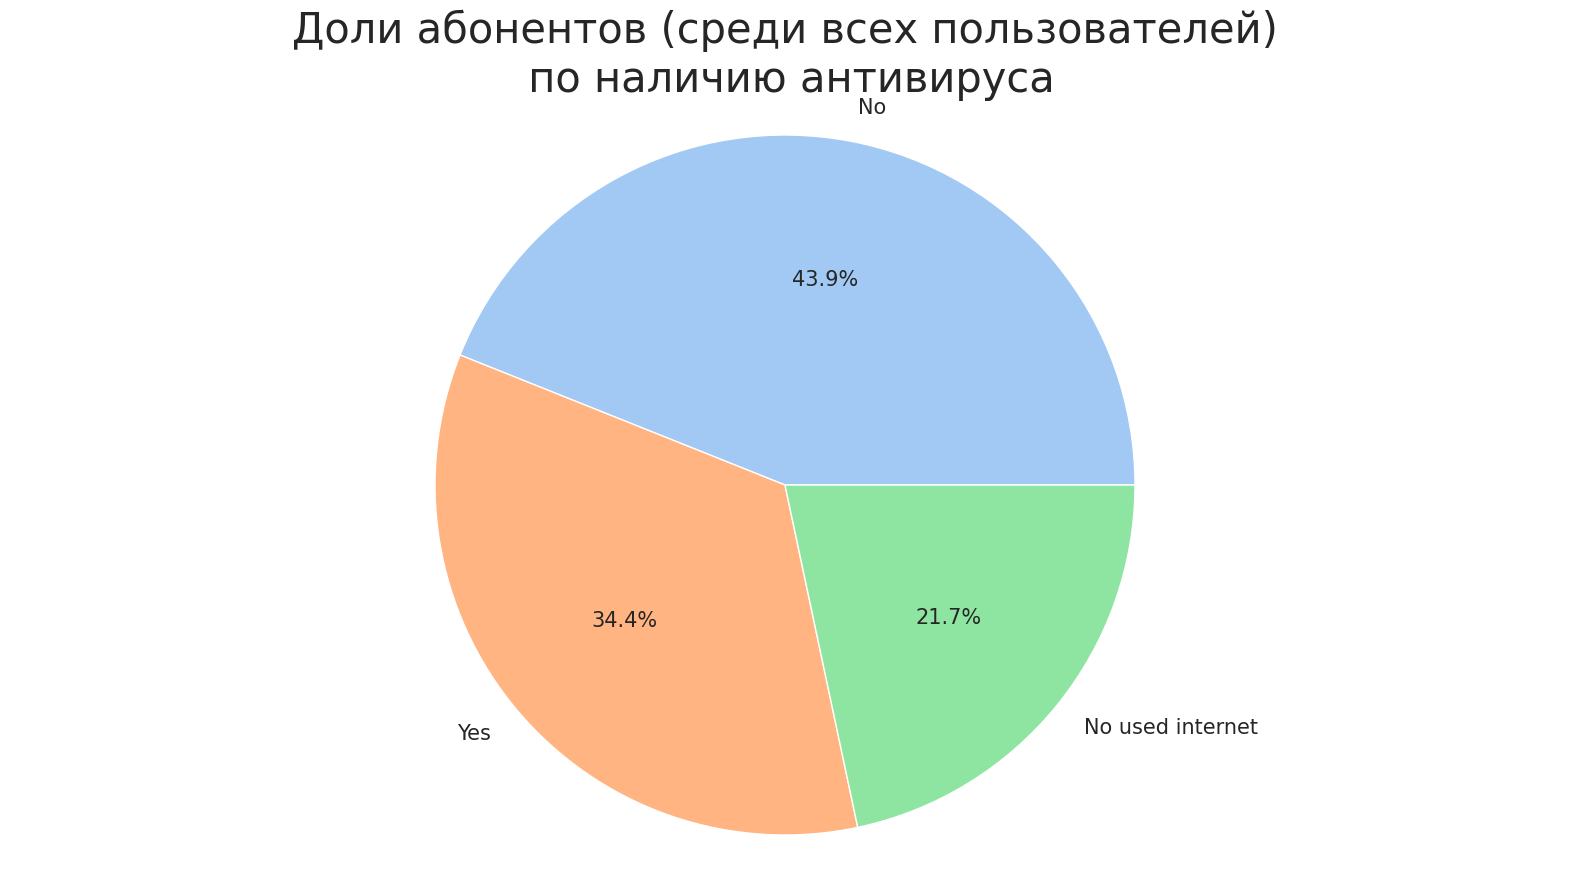

In [ ]:
# визуализируем по наличию антивируса
full_df_new['device_protection'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию антивируса', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

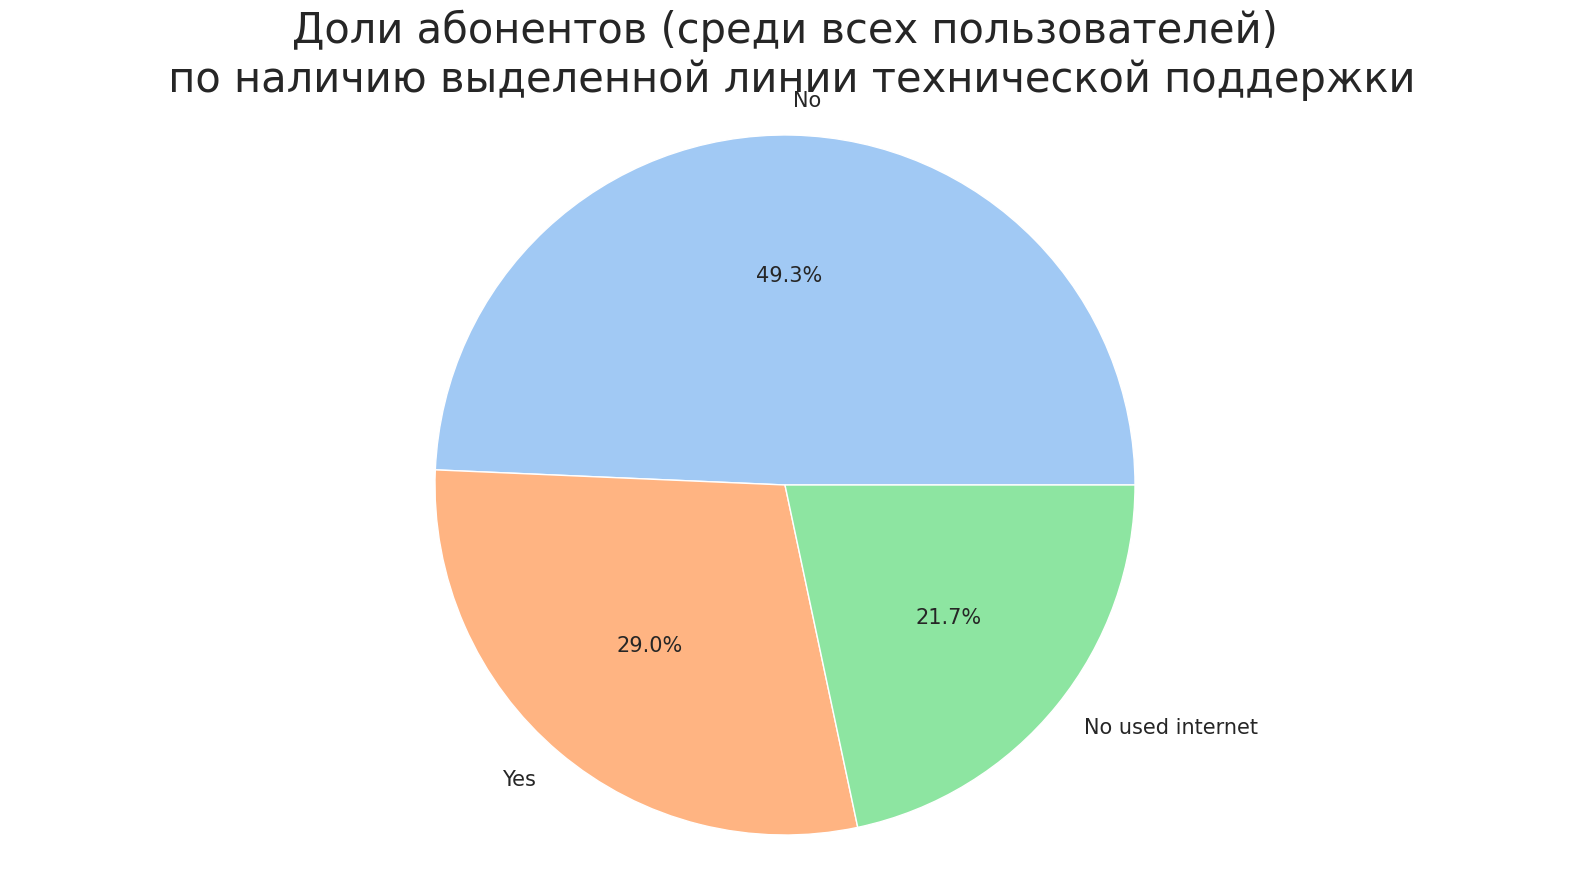

In [ ]:
# визуализируем по наличию выделенной линии технической поддержки
full_df_new['tech_support'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию выделенной линии технической поддержки', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

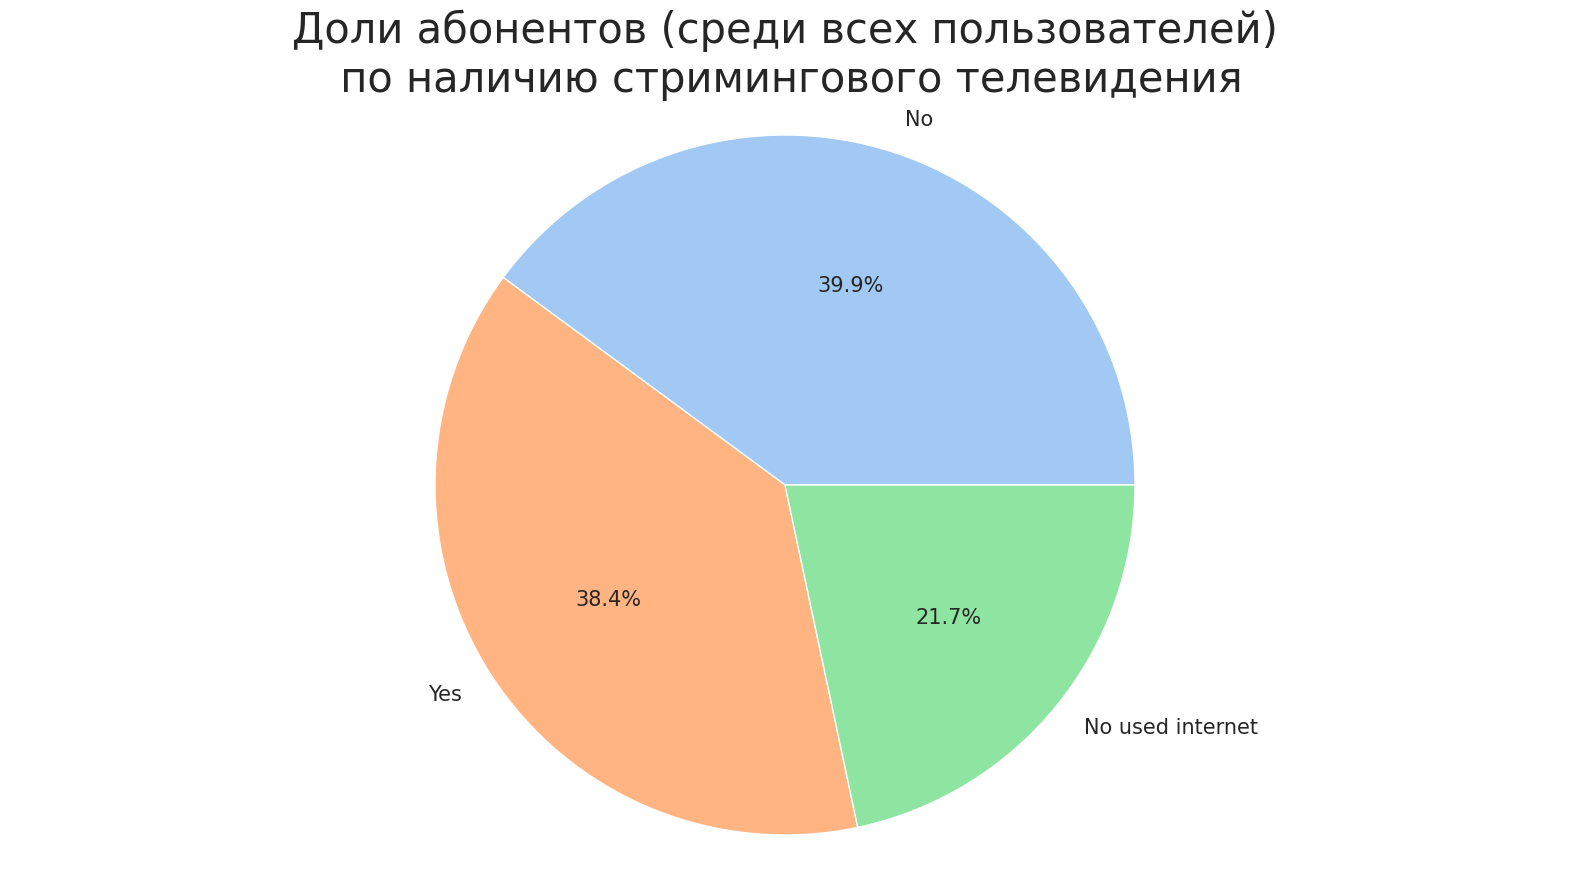

In [ ]:
# визуализируем по наличию стримингового телевидения
full_df_new['streaming_tv'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию стримингового телевидения', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

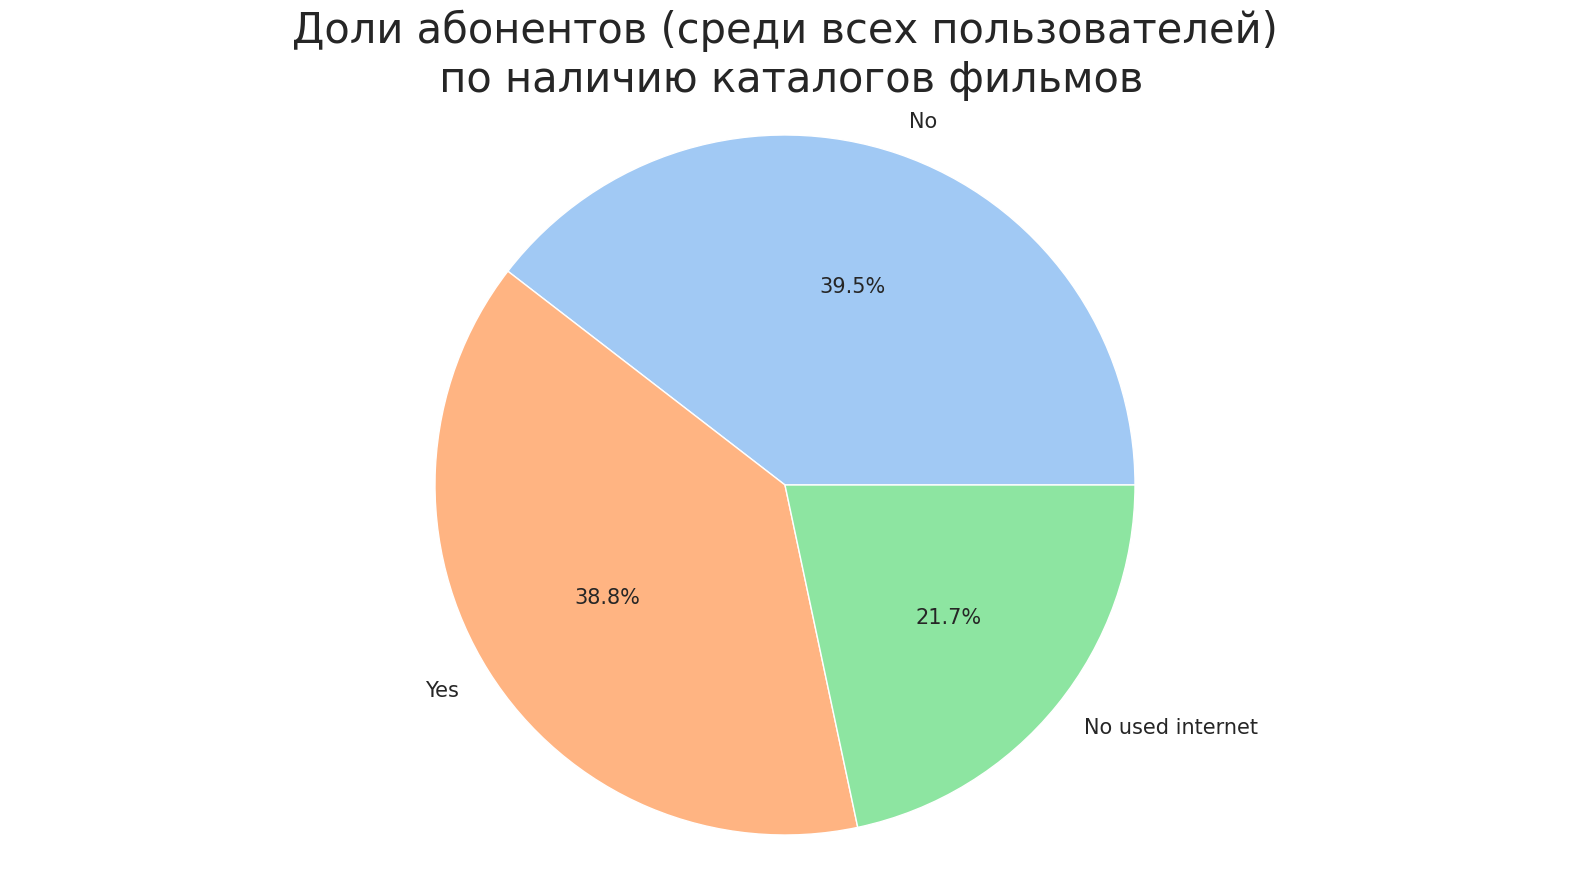

In [ ]:
# визуализируем по наличию каталогов фильмов
full_df_new['streaming_movies'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию каталогов фильмов', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Процент пользователей, не пользующийся интернет - услугами для каждой из услуг одинаков и составляет более 21%.



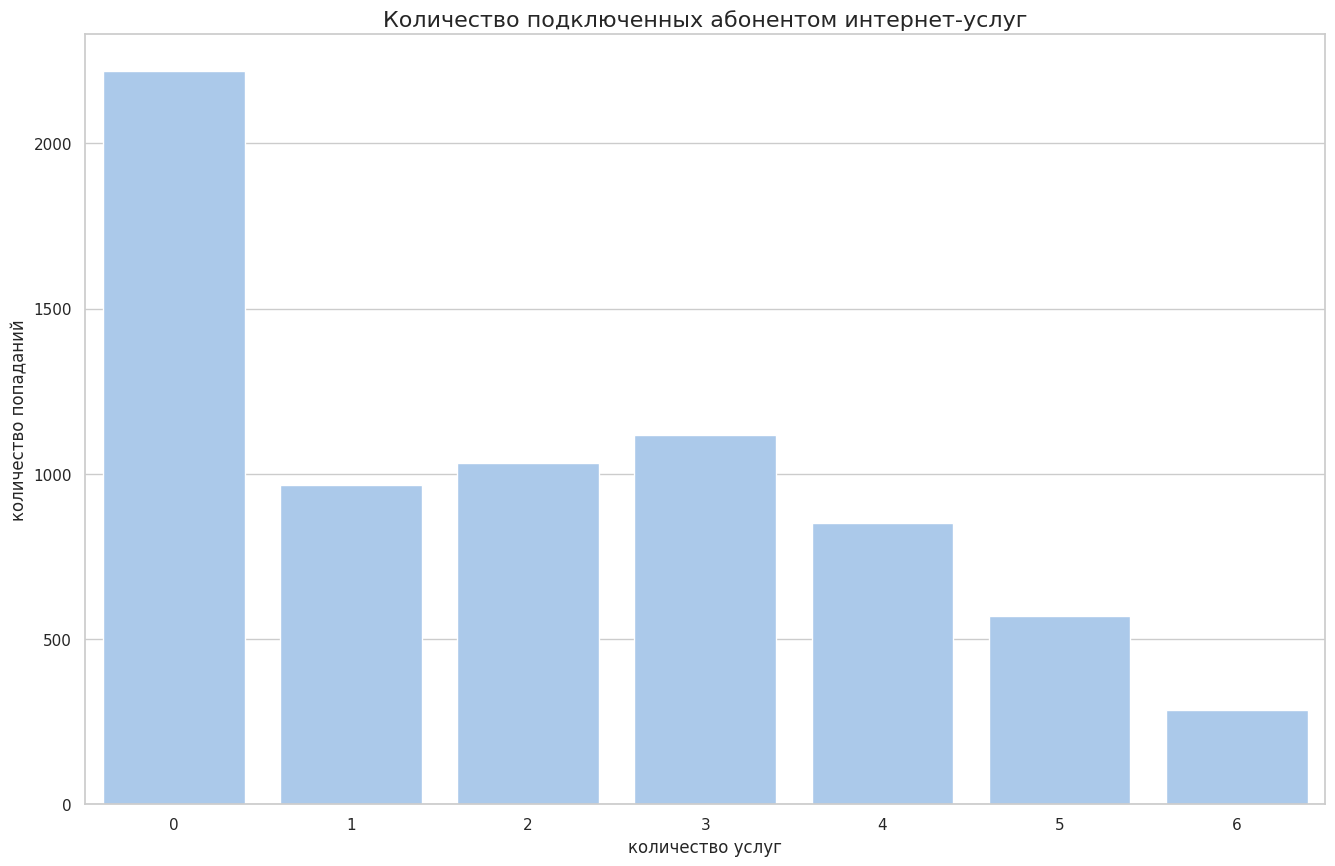

In [ ]:
# график для дискретного признака (на каждое уникальные значение признака строит свою корзину)
plt.figure(figsize=(16,10))

sns.countplot(x=full_df_new['num_int_options'])

plt.title('Количество подключенных абонентом интернет-услуг')
plt.xlabel('количество услуг')
plt.ylabel('количество попаданий')

plt.show()

У многих не подключено ни одной услуги. Большинство из остальны подключают от 1 до 3 услуг. Тех же, кто подключают все 6 услуг меньшинство.

Посмотрим также для телефонии.

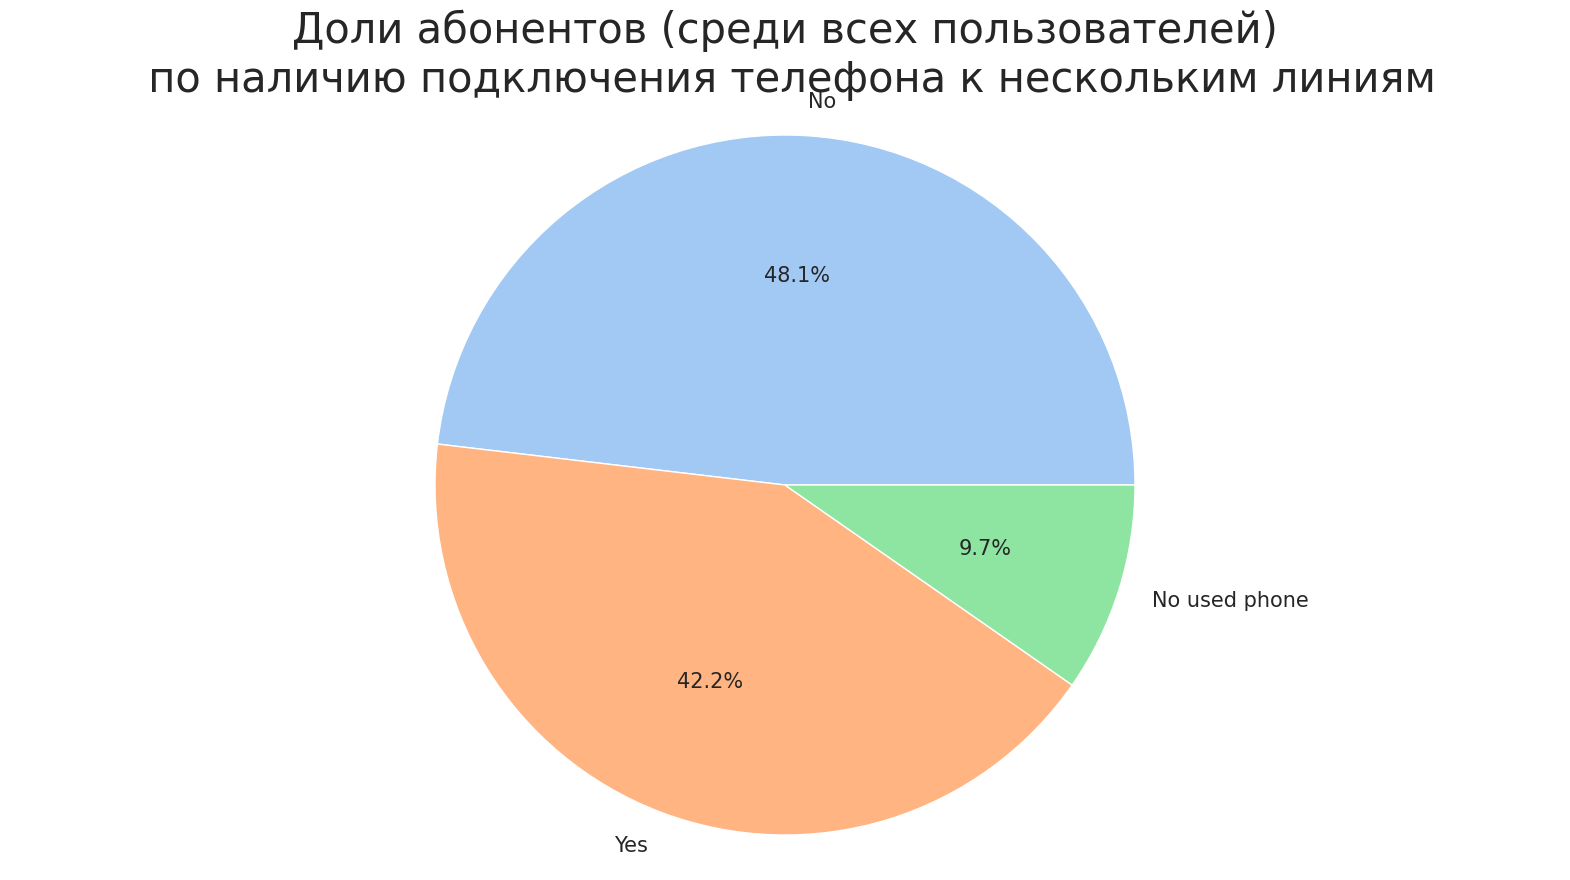

In [ ]:
# визуализируем по наличию подключения телефона к нескольким линиям
full_df_new['multiple_lines'].value_counts().plot(kind = 'pie', grid = True,\
                                     figsize = (20,10), fontsize=15, autopct='%1.1f%%')

plt.title('Доли абонентов (среди всех пользователей)\n по наличию подключения телефона к нескольким линиям', fontsize=30)
plt.axis('equal')
plt.ylabel('', fontsize=13)

plt.show()

Большая часть абонентов пользуется услугами телефонии. Доля клиентов, которые не пользуются телефонией составляет менее 10%.

### **Выводы**

Мы провели дополнительную работу по подготовке данных:

1. Создан новый (целевой) признак `'exit'` на основе столбца с датой окончания контракта:
- Расторгнутый контракт обозачен как 1, дейтвующий - как 0.
- Доля ушедших клиентов совпадает (84.4%) с ранее наблюдавшейся при изучении пропусков (с поправкой на округление).

2. Создан новый признак `'contract_day'`- длительность действия контракта в днях как более информативный, чем даты.
- Гистограмма распределения имеет несколько пиков, первый из которых смещен влево. Возможно, около года назад проходила какая-либо акция, привлекшая много новых клиентов, большая часть которых все еще осталсь абонентами заказчика.
- Вторым пиком являются клиенты-старожилы, многих из которых мы наблюдали ранее.
- Выбросы не обнаружены.
- Средняя и медиана не близки, что вместе с большим стандартным отклонением говорит о неравномерности в данных. Средняя длительность контракта - около 900 дней.

3. Объединили четыре таблицы в одну.
- Для каждого из клиентов имеется персональная информация.
- Не каждый клиент пользуется одновременно и телефонией и интернет-услугами, поэтому образовавшиеся пропуски были заполнены указанием на неиспользование подобных услуг.

4. Создан новый признак `'num_int_options'` с указанием количества подключенных интернет услуг.

5. Получен итоговый датасет, из которого были удалены столбцы с датами для избежание утечек данных.

6. Проведен дополнительный анализ итогового датасета по интернет-услугам и услугам телефонии.
- Доля тех, кто не пользуется интернет-услугами составила 21.7%.
- У многих абонентов не подключено ни одной услуги. Большинство из остальных подключают от 1 до 3 услуг. Тех же, кто подключают все 6 услуг меньшинство.
- В разрезе каждой из услуг (с учетом доли не использующих интернет-услуги, которая для всех одинакова):
  - Количество клиентов подключеных с помощью оптоволоконного кабеля составила 44%, на долю технологии DSL пришлось 34.4%.
  - Количество клиентов, использующих услугу блокировки опасных сайтов составила 28.7%, не использующих - 49.7%.
  - Количество клиентов, использующих услугу облачного хранилища составила 34.5%, не использующих - 43.8%.
  - Количество клиентов, использующих услугу по предоставлении антивируса составила 34.4%, не использующих - 43.9%.
  - Количество клиентов, использующих услугу по наличию выделенной линии техподдержки составила 29%, не использующих - 49.3%.
  - Количество клиентов, использующих услугу по наличию стримингового телевидения составила 38.4%, не использующих - 39.9%.
  - Количество клиентов, использующих каталоги фильмов составила 38.8%, не использующих - 39.5%.
- Количество клиентов, не использующих телефонию составило лишь 9.7%, использующих услугу по подключению телефонов к нескольким линиям составило 42.2%, не использующих данную услугк - 48.1%.


## **Портрет уходящего клиента**

Теперь нам нужно узнать, чем же отличается клиент, который ушел, от клиента, который остался. В этом нам поможет портрет уходящего клиента.

In [ ]:
def plot_categorical_pie_charts(data, categorical_columns, exit_column='exit'):
    """
    Строит парные круговые диаграммы для категориальных признаков,
    сравнивая распределения при exit=1 и exit=0.
    Одинаковые категории получают одинаковые цвета в обеих диаграммах.
    Общая легенда размещается между графиками.

    Параметры:
    ----------
    data : pandas.DataFrame
        Датафрейм с данными для анализа
    categorical_columns : list
        Список категориальных столбцов для визуализации
    exit_column : str, optional (default='exit')
        Название столбца с бинарным признаком (1/0)
    """

    # Разделяем данные на две группы по значению exit-колонки
    exit_1 = data[data[exit_column] == 1]  # Данные для exit=1
    exit_0 = data[data[exit_column] == 0]  # Данные для exit=0

    # Определяем структуру subplot (строки x колонки)
    n_rows = len(categorical_columns)  # По строке на каждый признак
    n_cols = 2  # Всегда две колонки (exit=1 и exit=0)

    # Создаем фигуру с динамическим размером по количеству строк
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

    # Добавляем общий заголовок для всех графиков
    fig.suptitle('Портрет абонента: категориальные признаки', y=1.02, fontsize=16, fontweight='bold')

    # Обработка случая с одним признаком (axes становится 1D массивом)
    if n_rows == 1:
        axes = axes.reshape(1, -1)  # Преобразуем в 2D массив 1x2

    # Строим диаграммы для каждого категориального признака
    for i, col in enumerate(categorical_columns):
        # Получаем все уникальные категории для текущего столбца (из обеих групп)
        all_categories = sorted(pd.concat([exit_0[col], exit_1[col]]).unique())

        # Создаем цветовую карту для всех категорий
        # Используем цветовую схему tab20 (20 различных цветов)
        colors = plt.cm.tab20(range(len(all_categories)))
        color_map = {cat: colors[j] for j, cat in enumerate(all_categories)}

        # =============================================
        # Первый график в паре - для exit=1 (слева)
        # =============================================
        counts_1 = exit_1[col].value_counts()  # Считаем частоты категорий

        # Функция для форматирования подписей с % и абсолютным числом
        def make_autopct_1(values):
            def my_autopct(pct):
                total = sum(values)
                val = int(round(pct*total/100.0))
                return f'{pct:.1f}%\n({val})'
            return my_autopct

        # Строим круговую диаграмму с назначенными цветами:
        wedges_1, _, autotexts_1 = axes[i, 0].pie(
            counts_1,
            colors=[color_map[cat] for cat in counts_1.index],  # Используем нашу цветовую карту
            autopct=make_autopct_1(counts_1),
            startangle=90,
            pctdistance=0.85,
        )
        axes[i, 0].set_title(f'{col} (ушел)')  # Заголовок графика

        # =============================================
        # Второй график в паре - для exit=0 (справа)
        # =============================================
        counts_0 = exit_0[col].value_counts()  # Считаем частоты категорий

        # Аналогичная функция для exit=0
        def make_autopct_0(values):
            def my_autopct(pct):
                total = sum(values)
                val = int(round(pct*total/100.0))
                return f'{pct:.1f}%\n({val})'
            return my_autopct

        # Строим вторую диаграмму с теми же цветами для категорий:
        wedges_0, _, autotexts_0 = axes[i, 1].pie(
            counts_0,
            colors=[color_map[cat] for cat in counts_0.index],  # Используем ту же цветовую карту
            autopct=make_autopct_0(counts_0),
            startangle=90,
            pctdistance=0.85,
        )
        axes[i, 1].set_title(f'{col} (остался)')

        # =============================================
        # ОБЩАЯ ЛЕГЕНДА МЕЖДУ ГРАФИКАМИ
        # =============================================

        # Собираем все уникальные категории из обеих диаграмм
        unique_categories = list(set(counts_1.index.tolist() + counts_0.index.tolist()))

        # Создаем элементы для легенды
        patches = [plt.Rectangle((0,0),1,1, fc=color_map[cat]) for cat in unique_categories]

        # Размещаем легенду между графиками
        # Используем bbox_to_anchor для точного позиционирования
        axes[i, 0].legend(
            patches,
            unique_categories,
            title=col,
            loc='center',
            bbox_to_anchor=(1.25, 0.5),  # Смещаем вправо от левого графика
            fontsize=10,
            frameon=False
        )

        # Увеличиваем размер шрифта для подписей с числами
        for text in autotexts_1 + autotexts_0:
            text.set_fontsize(10)

    # Автоматически регулируем отступы между графиками
    plt.tight_layout()

    # Добавляем дополнительное пространство для легенды
    plt.subplots_adjust(wspace=0.4)

    plt.show()

In [ ]:
# вспоминаем названия столбцов
full_df_new.columns

Index(['customer_id', 'type', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'exit', 'contract_day', 'gender',
       'senior_citizen', 'partner', 'dependents', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'multiple_lines',
       'num_int_options'],
      dtype='object')

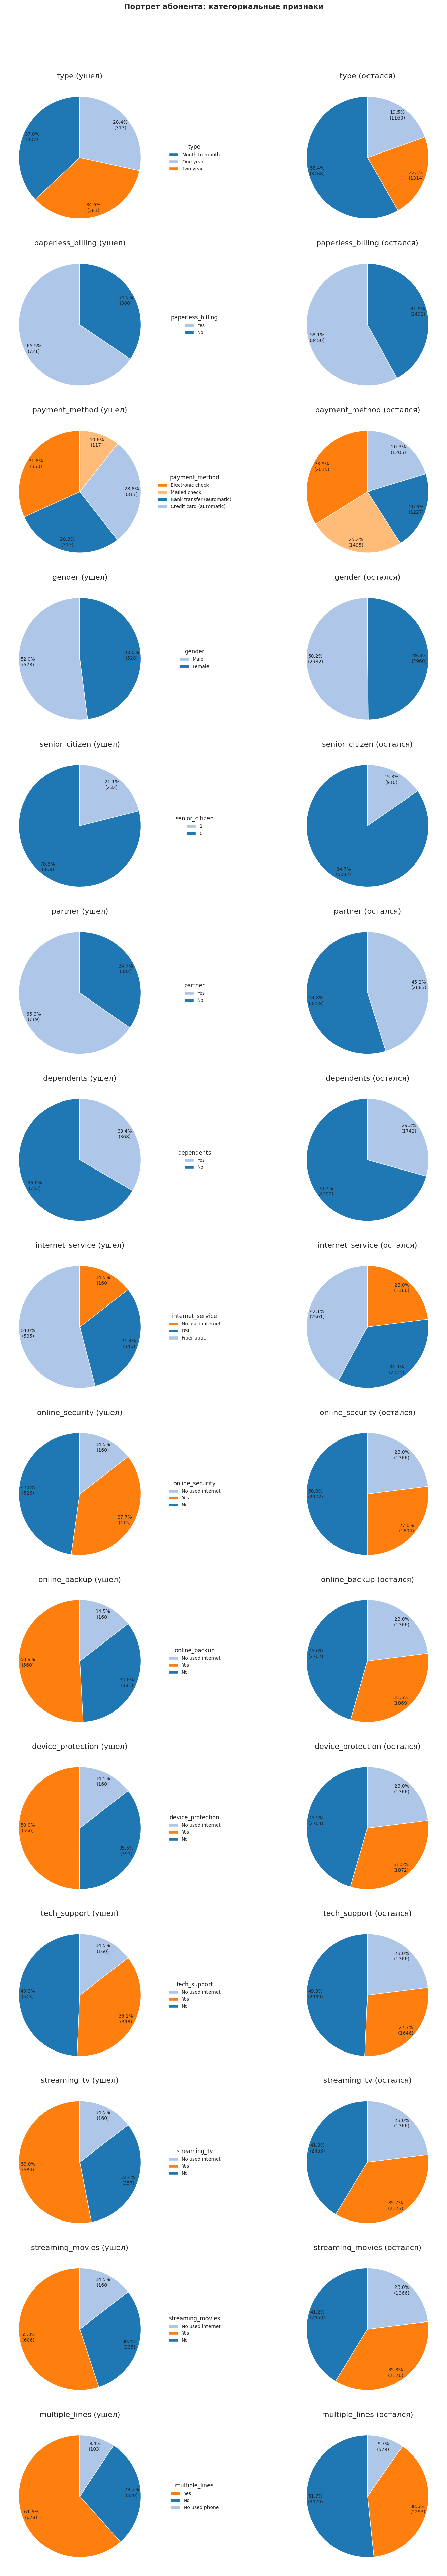

In [ ]:
# Вызываем функцию для категориальных столбцов
plot_categorical_pie_charts(full_df_new, full_df_new.drop(['customer_id', 'monthly_charges', 'total_charges', 'contract_day', 'exit', 'num_int_options'], axis=1).columns)

По многим (но не всем) категориальным параметрам структура ушедших и оставшихся клиентов отличается.

Среди тех, кто ушел (в сравнении с оставшимися):
- нет сильного преимущества у какого-либо типа (по частоте) оплаты (а вот большая часть оставшихся предпочитают платить раз в месяц;
- доля электронных расчетных листов больше;
- гораздо реже платят по почте, и гораздо чаще - автоматически по кредитным картам.
- ситуация по полу практически не отличается.
- доля пенсионеров несколько выше (это можно объяснить выбытием из-за смертности, например)
- доля одиноких гораздо меньше;
- доля имеющих детей немного больше;
- доля пользователей интернет-услуг меньше;
- значительно выше доля пользователей оптоволоконного подключения;
- значительно выше доля пользователей блокировки опасных сайтов;
- занчительно выше доля пользователей облачного хранилища;
- доля пользователей антивирусом значительно выше;
- доля пользователей стриминговым телевидением значительно выше;
- доля пользователей каталогом фильмов значительно выше.

In [ ]:
def visualize_numeric_with_stats(data, numeric_columns, exit_column='exit'):
    """
    Визуализирует числовые признаки с разделением по exit.
    Все графики и статистики выводятся в одной фигуре с общим заголовком.

    Параметры:
    ----------
    data : pandas.DataFrame
        Исходный датафрейм с данными
    numeric_columns : list
        Список числовых столбцов для анализа
    exit_column : str, optional (default='exit')
        Название столбца с бинарным признаком
    """

    # Разделяем данные по значению exit
    exit_1 = data[data[exit_column] == 1]
    exit_0 = data[data[exit_column] == 0]

    # Создаем фигуру с динамическим размером
    n_features = len(numeric_columns)
    fig = plt.figure(figsize=(16, 6 * n_features), constrained_layout=True)

    # Общий заголовок для всех графиков
    fig.suptitle('Портрет абонента: анализ числовых признаков',
                fontsize=16, fontweight='bold', y=1.02)

    # Цвета для групп
    palette = {0: 'skyblue', 1: 'salmon'}

    # Создаем grid layout
    # Для каждого признака: 2 строки (графики + таблица) и 2 колонки
    gs = fig.add_gridspec(n_features * 2, 2, height_ratios=[3, 1]*n_features)

    for i, col in enumerate(numeric_columns):
        # Индексы для текущего признака
        row_graph = i * 2
        row_table = i * 2 + 1

        # =============================================
        # Нормированная гистограмма с наложением распределений
        # =============================================
        ax_hist = fig.add_subplot(gs[row_graph, 0])
        sns.histplot(
            data=exit_0[col].dropna(),
            bins=50,
            color=palette[0],
            kde=True,
            alpha=0.5,
            label='exit=0',
            ax=ax_hist,
            stat='density',
            common_norm=False
        )
        sns.histplot(
            data=exit_1[col].dropna(),
            bins=50,
            color=palette[1],
            kde=True,
            alpha=0.5,
            label='exit=1',
            ax=ax_hist,
            stat='density',
            common_norm=False
        )
        ax_hist.set_title(f'{col}: Нормированная гистограмма распределения')
        ax_hist.set_ylabel('Плотность вероятности')  # Подпись оси Y
        ax_hist.legend(title='Группа')

        # =============================================
        # Boxplot для сравнения групп
        # =============================================
        ax_box = fig.add_subplot(gs[row_graph, 1])
        plot_data = pd.melt(
            data[[col, exit_column]].dropna(),
            id_vars=exit_column,
            value_vars=[col]
        )
        sns.boxplot(
            data=plot_data,
            x='value',
            y='variable',
            hue=exit_column,
            palette=palette,
            orient='h',
            ax=ax_box
        )
        ax_box.set_title(f'{col}: Сравнение распределений')
        ax_box.set_xlabel(col)  # Подпись оси X
        ax_box.legend(title='Группа')

        # =============================================
        # Таблица с описательной статистикой
        # =============================================
        ax_stats = fig.add_subplot(gs[row_table, :])
        ax_stats.axis('off')

        # Получаем статистики
        stats_0 = exit_0[col].describe().to_frame('exit=0')
        stats_1 = exit_1[col].describe().to_frame('exit=1')
        stats = pd.concat([stats_1, stats_0], axis=1)

        # Форматируем числа
        stats = stats.applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else str(x))

        # Создаем таблицу
        table = ax_stats.table(
            cellText=stats.values,
            rowLabels=stats.index,
            colLabels=stats.columns,
            loc='center',
            cellLoc='center',
            bbox=[0, 0, 1, 1]
        )

        # Настройка стиля таблицы
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.8)

    plt.show();

/tmp/ipython-input-93-3331516212.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stats = stats.applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else str(x))
/tmp/ipython-input-93-3331516212.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stats = stats.applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else str(x))
/tmp/ipython-input-93-3331516212.py:104: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stats = stats.applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else str(x))


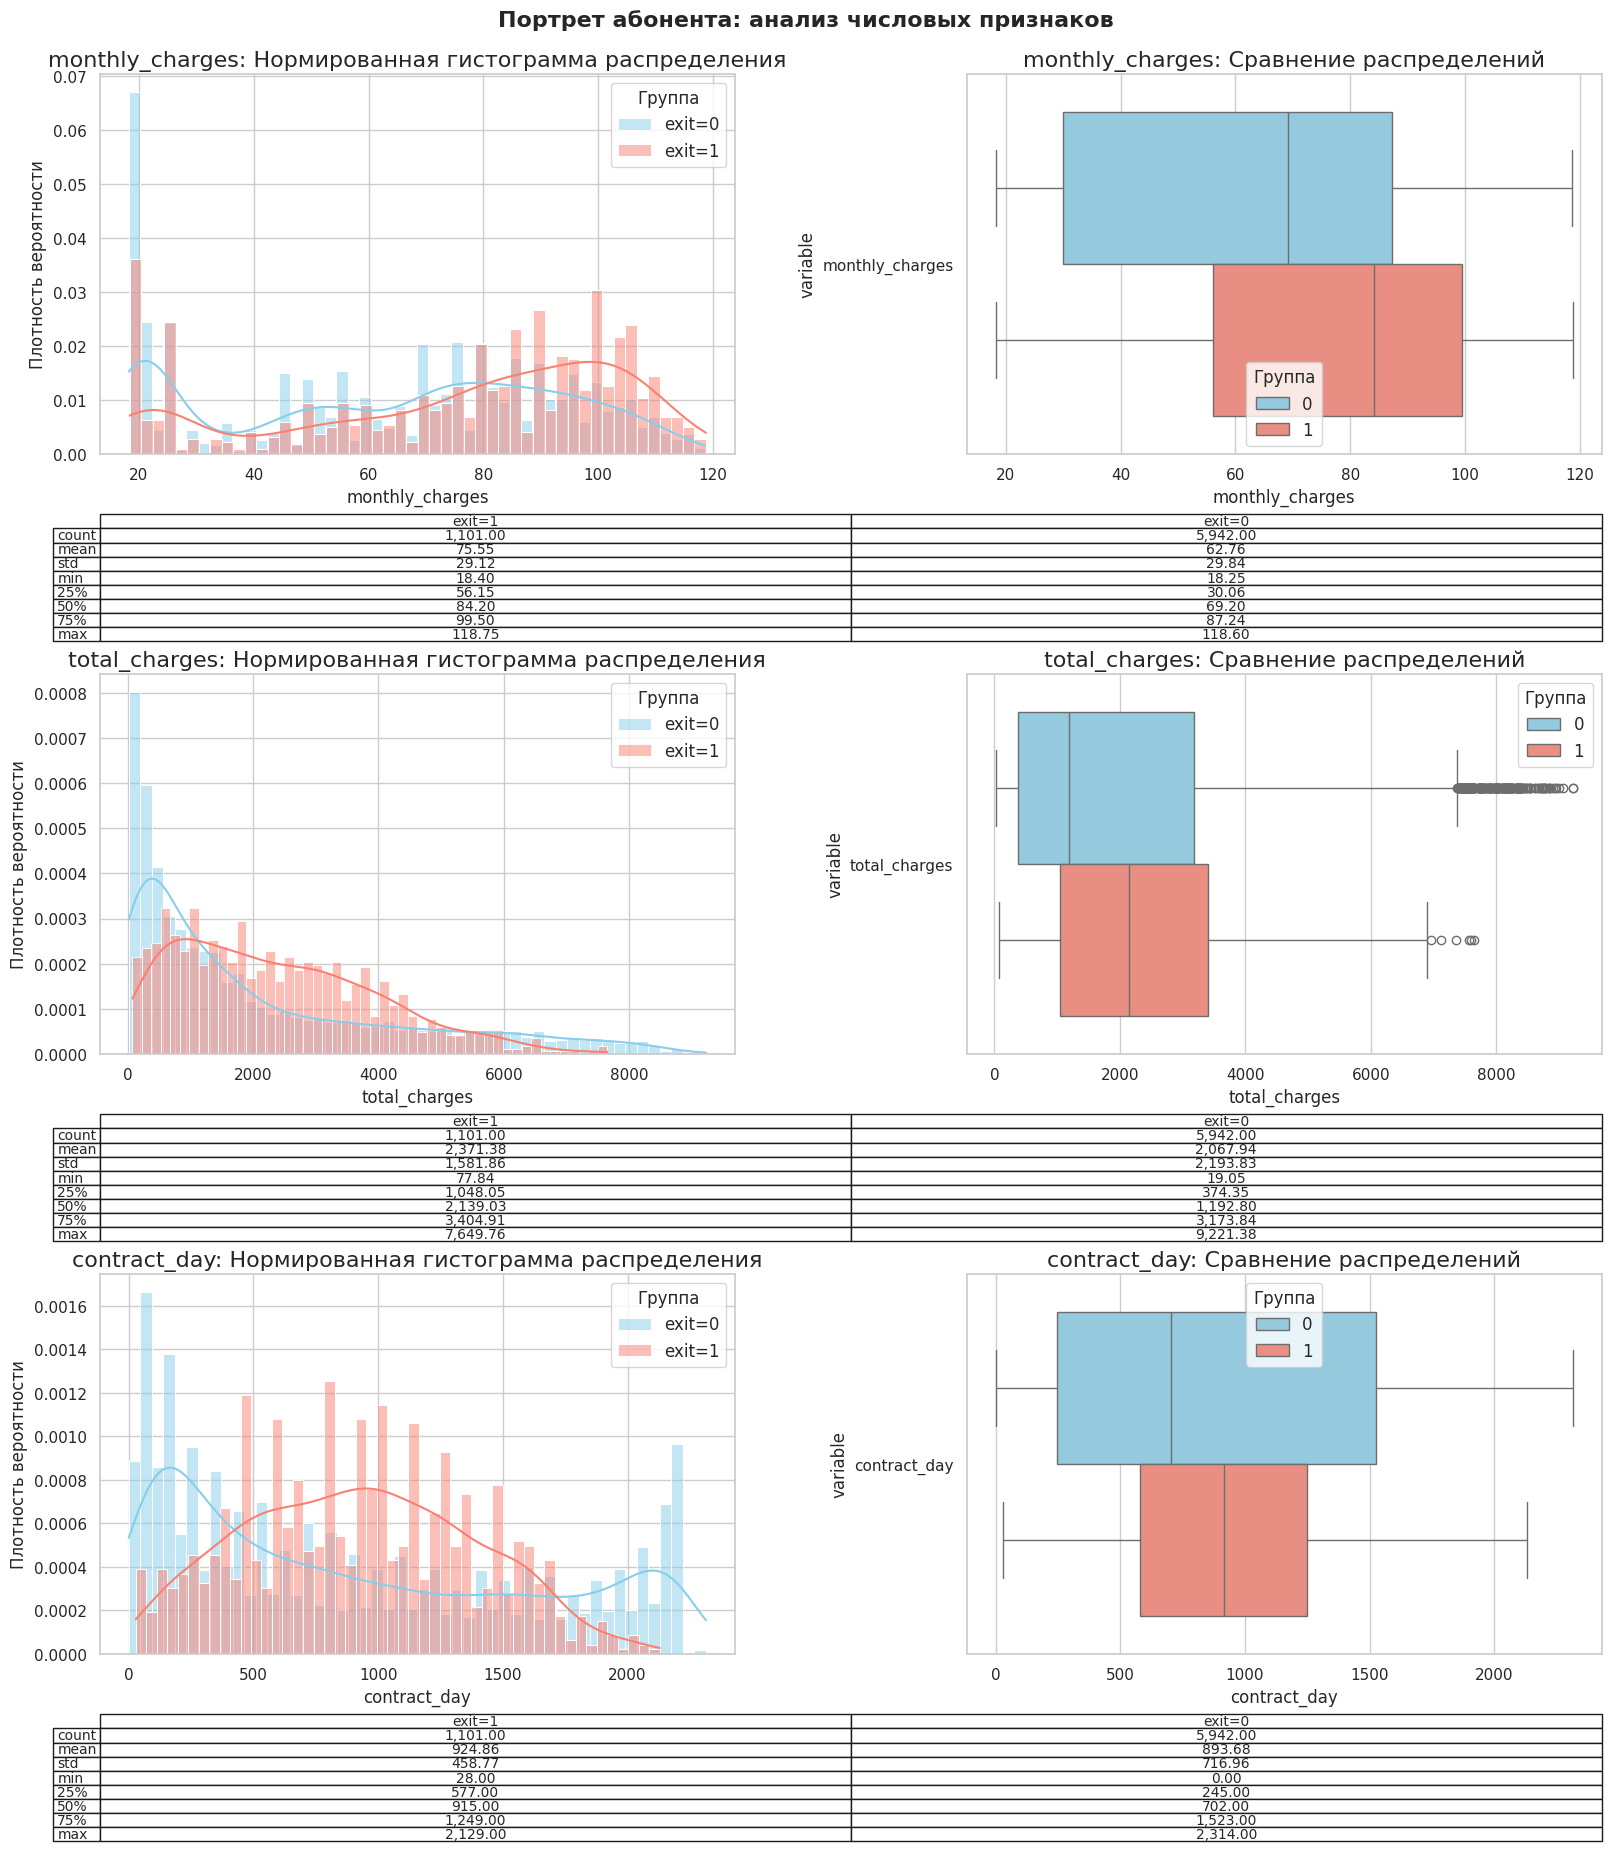

In [ ]:
# Визуализация
visualize_numeric_with_stats(full_df_new, ['monthly_charges', 'total_charges', 'contract_day'])

В среднем ушедшие клиенты тратили больше в месяц и за период действия контракта больше, чем оставшиеся. Также у оставшися мы наблюдаем три пика (три потенциальные группы), а у оставшихся - два (один из которых схож с одним из пиков оставшихся, но меньше).

Среди ушедших также имеются выбросы по общим тратам (мы уже наблюдали этих клиентов ранее). Также можно заметить, что гистограмма общих трат оставшихся похоже на нормальнное распределение и имеет один ярковыраженный пик и смещена влево. Пик же ушедших имеет более пологий спуск справа.

По проведенному времени виден лишь один пик около тысячного дня (возможно, следует дополнительно поощрять клиентов за столь долгую лояльность), а диапазон "характерного срока" для контракта также уже. При этом в среднем ушедшие провели в качестве абонентов больше дней, чем оставшиеся. Возможно, на это также повлиял недавний прилив новых абонентов.

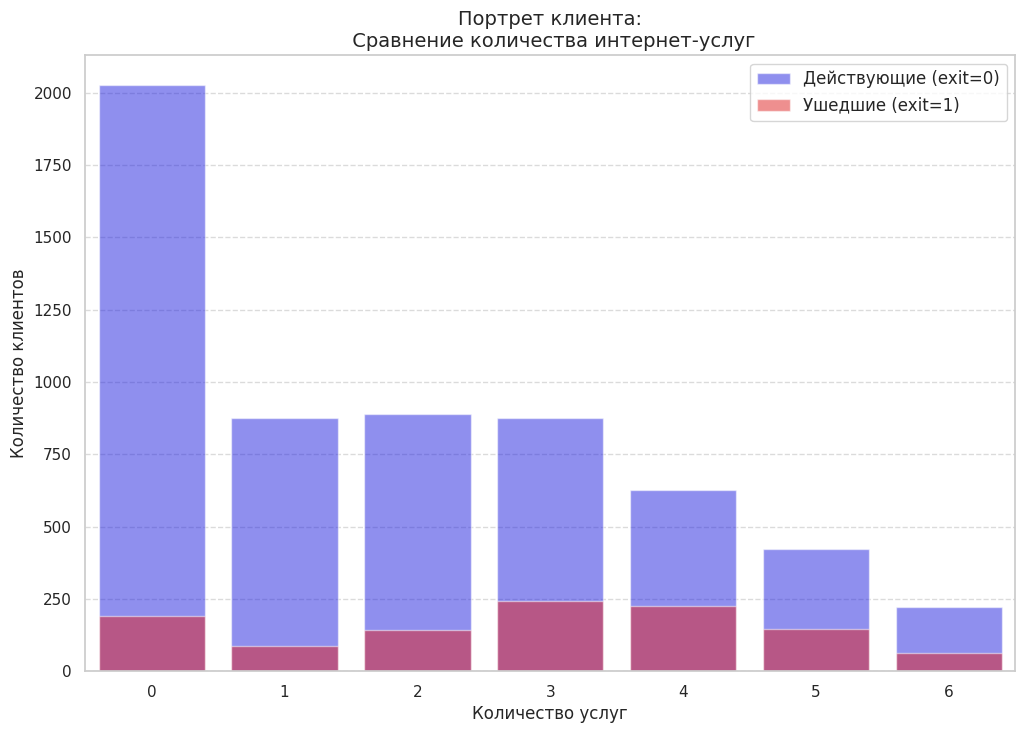

In [ ]:
plt.figure(figsize=(12, 8))

# График для действующих клиентов (exit=0)
sns.countplot(
    x=full_df_new[full_df_new['exit'] == 0]['num_int_options'],
    color='blue',
    alpha=0.5,  # Полупрозрачность для наглядности
    label='Действующие (exit=0)'
)

# График для ушедших клиентов (exit=1)
sns.countplot(
    x=full_df_new[full_df_new['exit'] == 1]['num_int_options'],
    color='red',
    alpha=0.5,
    label='Ушедшие (exit=1)'
)

# Настройки отображения
plt.title('Портрет клиента:\n Сравнение количества интернет-услуг', fontsize=14)
plt.xlabel('Количество услуг', fontsize=12)
plt.ylabel('Количество клиентов', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Большее количество ушедших клиентов либо не подключало интернет вообще (но в общей массе ушедших доля таких клиентов значительно ниже таковых у оставшихся), либо подключало 3-4 услуги.

<div class="alert alert-info">

<h2> <b> 💡 Комментарий студента v2💡</b> <a class="tocSkip"> </h2>

Поправила вывод.
</div>

### **Выводы**

Мы построили графики для сравнения ушедших и оставшихся клиентов, чтоб составить портрет ушедшего клиента. В результате мы смогли увидеть, что по многим (но не всем) параметрам структура ушедших и оставшихся клиентов отличается.

Среди тех, кто ушел (в сравнении с оставшимися):
- нет сильного преимущества у какого-либо типа (по частоте) оплаты (а вот большая часть оставшихся предпочитают платить раз в месяц;
- ситуация по полу практически не отличается;
- меньше доля пользователей интернет-услуг (при этом большее количество ушедших клиентов либо не подключало интернет вообще (но в общей массе ушедших доля таких клиентов значительно ниже таковых у оставшихся), либо подключало 3-4 услуги);
- гораздо меньше доля одиноких;
- гораздо реже платят по почте, и гораздо чаще - автоматически по кредитным картам;
- немного больше доля имеющих детей;
- несколько выше доля пенсионеров (это можно объяснить выбытием из-за смертности, например);
- больше доля электронных расчетных листов;
- значительно выше доли пользователей оптоволоконного подключения, блокировки опасных сайтов,  облачного хранилища, антивирусом, стриминговым телевидением, каталогом фильмов - то есть такие клиенты более интернет-активны.
- в среднем ушедшие клиенты тратили больше в месяц и за период действия контракта больше, чем оставшиеся. Также у оставшися мы наблюдаем три пика (три потенциальные группы), а у оставшихся - два (один из которых схож с одним из пиков оставшихся, но меньше).
- реди ушедших также имеются выбросы по общим тратам (мы уже наблюдали этих клиентов ранее). Также можно заметить, что гистограмма общих трат оставшихся похоже на нормальнное распределение и имеет один ярковыраженный пик и смещена влево. Пик же ушедших имеет более пологий спуск справа.
- по проведенному времени виден лишь один пик около тысячного дня (возможно, следует дополнительно поощрять клиентов за столь долгую лояльность), а диапазон "характерного срока" для контракта также уже. При этом в среднем ушедшие провели в качестве абонентов больше дней, чем оставшиеся. Возможно, на это также повлиял недавний прилив новых абонентов.

## **Корреляционный анализ**

Кроме протрета необходимо посмотреть корреляцию между признаками "описательным" и целевым, чтобы определиться, что брать в дальнейшую работу.

In [ ]:
full_df_new.columns # вспоминаем название столбцов

Index(['customer_id', 'type', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'exit', 'contract_day', 'gender',
       'senior_citizen', 'partner', 'dependents', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies', 'multiple_lines',
       'num_int_options'],
      dtype='object')

In [ ]:
# неприрывные значения
interval_cols = ['monthly_charges', 'total_charges','contract_day']

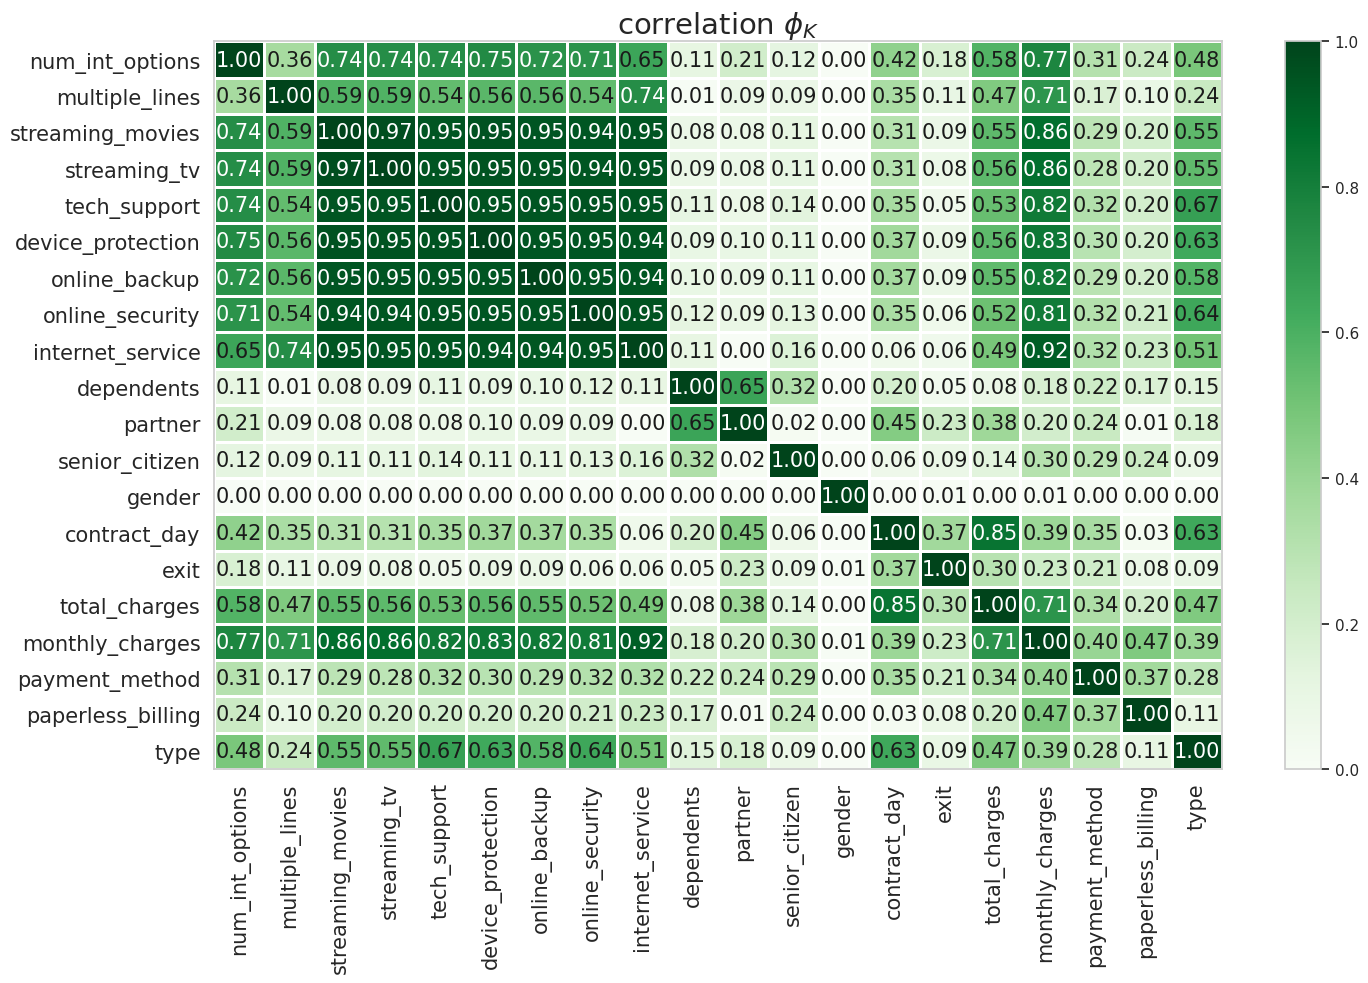

In [ ]:
# считаем корреляции
phik_overview = full_df_new.drop('customer_id', axis=1).phik_matrix(interval_cols=interval_cols)

# матрица корреляции
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(15, 10)
)

Ожидаемо высокая степень зависимости количества интернет-услуг с самими услугами. Также высока зависимость между самими интернет-услугами (возможно, некоторые из них идут в "пакетной связке"). Поэтому использовать количество интернет услуг вместо каждой из них в отдельности имеет смысл для избежания утечки данных.

Также можно заметить и связь между ежемесячными тратами и интернет услугами, что логично: больше подключаешь - больше платишь. И с общими тратами (как суммой ежемесячных).

Наличие детей ожидаемо связано с наличием партнера, а также статусом пенсионера/не пенсионера.

Пол имеет ожидаемо низкую корреляцию - исключим его. Также исключим часть столбцов с интернет-услугами, высоко коррелирующих между собой, и столбец с id покупателя за ненадобностью). После этого мы снова вернемся к матрице для нового изучения.


In [ ]:
# удаляем
full_df_new = full_df_new.drop(['gender', 'internet_service', 'customer_id',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_tv', 'streaming_movies'], axis=1)

In [ ]:
full_df_new.info() # проверка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   type               7043 non-null   object  
 1   paperless_billing  7043 non-null   object  
 2   payment_method     7043 non-null   object  
 3   monthly_charges    7043 non-null   float64 
 4   total_charges      7043 non-null   float64 
 5   exit               7043 non-null   int64   
 6   contract_day       7043 non-null   int64   
 7   senior_citizen     7043 non-null   object  
 8   partner            7043 non-null   object  
 9   dependents         7043 non-null   object  
 10  multiple_lines     7043 non-null   object  
 11  num_int_options    7043 non-null   category
dtypes: category(1), float64(2), int64(2), object(7)
memory usage: 612.6+ KB


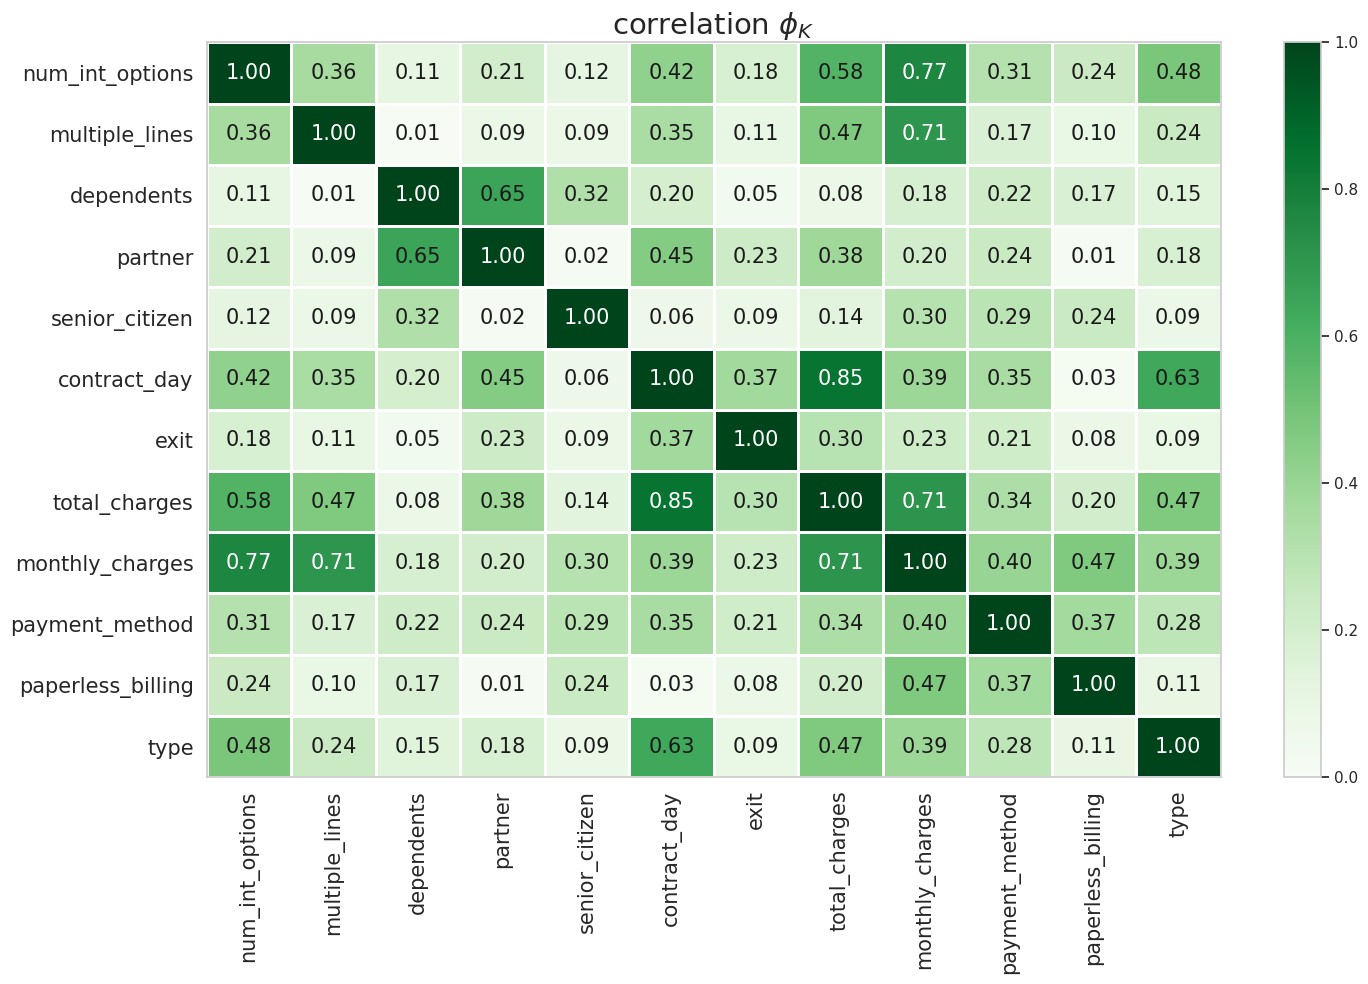

In [ ]:
# считаем корреляции
phik_overview = full_df_new.phik_matrix(interval_cols=interval_cols)

# матрица корреляции
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(15, 10)
)

Мы избавились от малоинформативного признака, а также от признаков с близкой к мультиколлинеарности степенью связи между собой (во избежание утечки данных).

Высокой степени зависимости между целевым и остальными признаками не обнаружено. Но разной степени связи есть со всеми признаками. Наиболее высокая из них (умеренной силы) - с количеством дней и общими тратами, слабой - с ежемесячными. То есть (вкупе с наблюдаемым ранее) - необходимо обращать внимание на клиентов-"долгожителей" и поощрять их за лояльность оператору.

Дополнительно проведем проверку на дубликаты, которые могли появиться после удаления столбцов.

In [ ]:
# проверяем дубликаты
print(color.BLUE + color.BOLD +f"Количество дубликатов в подготовленном датасте: "+ color.END + f"{full_df_new.duplicated().sum()}")

Количество дубликатов в подготовленном датасте: 13


Хоть мы и точно знаем, что это разные клиенты, но, чтобы избежать утечки, удалим дубликаты.

In [ ]:
# удаляем
full_df_new = full_df_new.drop_duplicates()
# проверяем дубликаты
print(color.BLUE + color.BOLD +f"Количество дубликатов в подготовленном датасте: "+ color.END + f"{full_df_new.duplicated().sum()}")

Количество дубликатов в подготовленном датасте: 0


### **Выводы**

Мы провели корреляционный анализ признаков, в результате чего:
- Заметили высокую степень связи между различными интернет-услугами, что может говорить об их "пакетном" подключении;
- Также заметили связь между тратами клиента (ежемесячными и общими) и интернет услучами (и их количеством), что логично: чем больше подключаешь, тем больше платишь;
- Обнаружили, что наличие детей ожидаемо связано с наличием партнера, а также статусом пенсионера/не пенсионера;
- Удалили малоинформационный признак `'gender'`, а также большую часть признаков, связанных с интеренет-услугами (во избежание утечек признаков и мультиколлинеарности), оставив их производный признак с количеством интернет-услуг ();
- Сильной связи между целевым признаком и остальными не выявлено, однако со всеми признаками есть  связи разной степени. Наиболее высокая из них (умеренной силы) - с количеством дней и общими тратами, слабой - с ежемесячными. То есть (вкупе с наблюдаемым ранее) - необходимо обращать внимание на клинтов-"долгожителей" и поощрять их за лояльность оператору.

Также мы удалили образовавшиеся в процессе подготовки дубликаты для избежания утечки данных.

## **Работа с моделями**

### **Разбиение на выборки**

In [ ]:
# смотрим на датасет, его столбцы и их типы данных
# вызов функции discr_num и ее вывод
first_discr(full_df_new,'full_df_new', 5)


 === Первые 5 строк в full_df_new: ===



,type,paperless_billing,payment_method,monthly_charges,total_charges,exit,contract_day,senior_citizen,partner,dependents,multiple_lines,num_int_options
0,Month-to-month,Yes,Electronic check,29.85,31.04,0,31,0,Yes,No,No used phone,1
1,One year,No,Mailed check,56.95,"2,071.84",0,1036,0,No,No,No,2
2,Month-to-month,Yes,Mailed check,53.85,226.17,0,123,0,No,No,No,2
3,One year,No,Bank transfer (automatic),42.30,"1,960.60",0,1371,0,No,No,No used phone,3
4,Month-to-month,Yes,Electronic check,70.70,353.50,0,153,0,No,No,No,0



 === Общая информация о данных в full_df_new: ===

<class 'pandas.core.frame.DataFrame'>
Index: 7030 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   type               7030 non-null   object  
 1   paperless_billing  7030 non-null   object  
 2   payment_method     7030 non-null   object  
 3   monthly_charges    7030 non-null   float64 
 4   total_charges      7030 non-null   float64 
 5   exit               7030 non-null   int64   
 6   contract_day       7030 non-null   int64   
 7   senior_citizen     7030 non-null   object  
 8   partner            7030 non-null   object  
 9   dependents         7030 non-null   object  
 10  multiple_lines     7030 non-null   object  
 11  num_int_options    7030 non-null   category
dtypes: category(1), float64(2), int64(2), object(7)
memory usage: 666.3+ KB


None


 === Размер датасета full_df_new:===
    (7030, 12)


 === Явные дубликаты в full_df_new:===
Количество: 0
Процент: 0.00 %


In [ ]:
# задаем целевой признак
target = 'exit'

In [ ]:
# функция подготовки данных перед подбором моделей и их параметров
# вариант 1 (модифицированный)
def data_preprocessing(data, target_name):

    # Перемешивание объектов
    # для их лучшего распределения в выборках
    data = shuffle(data, random_state=RANDOM_STATE)

    # Разделение датафреймов на целевую и нецелевую выборку
    features = data.drop([target_name], axis=1)
    target = data[target_name]

    # Разделение целевой и нецелевой выборки
    # на обучающие и тестовые выборки
    X_train,  X_test, y_train, y_test = train_test_split(
        features,
        target,
        shuffle = True, # перемешивание, больше нужно для задач классификации
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        # учтем неравномерность выборки по целевому
        stratify=data[target_name] # стратификация по указанному признаку
    )

    return X_train, X_test, y_train, y_test

In [ ]:
# разделение обучающего датафрейма на целевую и тестовую выборку
X_train, X_test, y_train, y_test = data_preprocessing(full_df_new, target)

In [ ]:
# проверка разбиения по количеству
print(color.BLUE + color.BOLD + f"Размер X_train: "\
      + color.END + f"{X_train.shape}")
print(color.BLUE + color.BOLD + f"Размер X_test: "\
      + color.END + f"{X_test.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train: "\
      + color.END + f"{y_train.shape}")
print(color.BLUE + color.BOLD + f"Размер y_test: "\
      + color.END + f"{y_test.shape}")

Размер X_train: (5272, 11)
Размер X_test: (1758, 11)
Размер y_train: (5272,)
Размер y_test: (1758,)


In [ ]:
# проверка разбиения по долям
print(color.BLUE + color.BOLD + f'Доля тренировочных признаков: '\
      + color.END + f'{X_train.shape[0]/full_df_new.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля тренировочных целей: '\
      + color.END + f'{y_train.shape[0]/full_df_new.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля тестовых признаков: '\
      + color.END + f'{X_test.shape[0]/full_df_new.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля тестовых целей: '\
      + color.END + f'{y_test.shape[0]/full_df_new.shape[0]:.2f}')
print(color.BLUE + color.BOLD + f'Доля положительных целей на тренировочных данных: '\
     + color.END + f'{y_train.astype("int").mean():.2f}')
print(color.BLUE + color.BOLD + f'Доля положительных целей на тестовых данных: '\
      + color.END + f'{y_test.astype("int").mean():.2f}')

Доля тренировочных признаков: 0.75
Доля тренировочных целей: 0.75
Доля тестовых признаков: 0.25
Доля тестовых целей: 0.25
Доля положительных целей на тренировочных данных: 0.16
Доля положительных целей на тестовых данных: 0.16


#### **Вывод**
Разбиение на выборки прошло успешно.

### **Dummy-модель**

Базовая, необходима для более объективного сравнения качества лучших моделей.

In [ ]:
# создаем словарь для сравнения
models_dict = {}

In [ ]:
# для дамми-модели не нужна подготовка признаков
# выберем лучшую из стратегий (функция адаптирована под тип задачи и ее метрику)
# (однако в данном случае GridSearchCV для DummyClassifier - весьма избыточно, учитывая, что нам эта оценка нужна просто для успокоения,
# а в случае с AUC-ROC там всегда будет ~0.5 независимо от стратегии)

# функция с дамми-моделью
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Dummy_Classifier(X_train, y_train):

    # инициализация модели
    model = DummyClassifier(random_state=RANDOM_STATE)

    # определение стратегий для дамми-классификатора
    # (определение сетки гиперпараметров)
    param_grid = {
        'strategy': ['stratified', 'most_frequent', 'prior', 'uniform']
        # 'stratified' - предсказывает согласно распределению классов в обучающих данных
        # 'most_frequent' - всегда предсказывает самый частый класс
        # 'prior' - всегда предсказывает класс с наибольшим априорным распределением
        # 'uniform' - предсказывает классы равномерно случайно
    }

    # создание GridSearchCV
    grid_search = GridSearchCV(
        estimator=model, # модель
        param_grid=param_grid, # параметры
        scoring='roc_auc', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        cv=5, # количество фолдов для кросс-валидации
        n_jobs=-1, # все ядра
        verbose=1  # не отключаем вывод
    )

    # обучение модели
    grid_search.fit(X_train, y_train)

    # получение результатов
    best_model = grid_search.best_estimator_
    best_roc_auc = grid_search.best_score_  # Лучшее значение ROC-AUC
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучший ROC-AUC на валидации: "
          + color.END + f"{best_roc_auc:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшая стратегия: "
          + color.END + f"{best_params['strategy']}\n")

    # возвращаем словарь с результатами
    return {
        'model': best_model,
        'best_score': best_roc_auc,  # ROC-AUC score
        'best_params': best_params, # лучшие параметры
        'grid_search': grid_search  # опционально - если нужен объект GridSearchCV
    }

In [ ]:
# тренируем модель
# вызов функции и сохранение результатов
%time result_dc = Dummy_Classifier(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучший ROC-AUC на валидации: 0.5028
Лучшая стратегия: stratified

CPU times: user 267 ms, sys: 9.32 ms, total: 277 ms
Wall time: 736 ms


In [ ]:
# добавляем в словарь
models_dict['DummyClassifier'] = {
    'ROC-AUC': round(result_dc['best_score'], 4),
    'params': result_dc['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,ROC-AUC,params
DummyClassifier,0.50,{'strategy': 'stratified'}


#### **Вывод**

Основой для сравнения качества моделей станет ROC-AUC=0.50, которую показала лучшая из Дамми-моделей (предсказывавшая результат на основе распределения классов в исходной выборке).

### **RandomForestClassifier**

In [ ]:
# функция с моделью случайного леса
# вместе с подготовкой данных и перебором параметров
# (так как она основана на деревьях - досточно ORD для категорий,
# числовые признаки масштабировать не требуется)
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Random_Forest_Classifier(X_train, y_train):

    # Подготовка признаков для дерева решений
    # преобразуем данные согласно их типу
    ensemble_transformer = make_column_transformer(
    (
        OrdinalEncoder(
            dtype='int16', #  кодирует категориальные переменные в 16-битные целые числа
            handle_unknown='use_encoded_value', # определяет, как обрабатывать неизвестные категории
            unknown_value=-1 # присваивает значение -1 неизвестным категориям
        ), make_column_selector(dtype_include=['category', 'object']) # типы, к которым применяем
    ),
    remainder='passthrough' # пропустить неизвестные значения
    )

    # Создание пайплайна
    pipe_rf = make_pipeline(
    ensemble_transformer,
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1, # все ядра
         # автоматически вычисляет веса классов обратно пропорциональными их частотам в обучающей выборке
        # в текущей задаче может быть не обязательно, но лучше подстаховаться, так дисбаланс все же есть
        class_weight='balanced',
        verbose=0 # отключаем вывод информации
    )
    )


    """
    n_estimators: Количество деревьев в лесу.
    Большее значение может улучшить точность, но увеличит время обучения.
    """

    # Сетка гиперпараметров
    param_grid_rf = {
        'randomforestclassifier__n_estimators': [10, 25, 50],            # количество деревьев в лесу
        'randomforestclassifier__criterion': ['gini', 'entropy'], # критерий для разбиения (индекс Джини или энтропия)
        'randomforestclassifier__max_depth': [10, 25, 50],     # максимальная глубина дерева
        'randomforestclassifier__min_samples_split': [5, 10],         # минимальное число примеров для разбиения узла
        'randomforestclassifier__min_samples_leaf': [2, 4],           # минимальное число примеров в листе
        # сколько признаков будет рассматриваться при разбиении узла в дереве
        #'randomforestclassifier__max_features': ['sqrt', 'log2']
    }

    # Создание экземпляра GridSearchCV для Случайного леса
    grid_search = GridSearchCV(
                    estimator=pipe_rf,  # Используем только пайплайн
                    param_grid=param_grid_rf, # параметры
                    cv=5, # количество фолдов, сократили для ускорения
                    scoring='roc_auc', # метрика
                    refit=True, # переобучить лучшую модель на всех данных
                    #verbose=0, # отключаем вывод
                    verbose=1 , # не отключаем вывод
                    n_jobs=-1 # все ядра
                        )

    # обучение на обучающей выборке с перебором всех комбинаций гиперпараметров
    grid_search.fit(X_train, y_train)

    # получение результатов
    best_model = grid_search.best_estimator_ # лучшая модели с оптимальными гиперпараметрами
    best_roc_auc = grid_search.best_score_  # лучшее значение ROC-AUC
    best_params = grid_search.best_params_ # параметры лучшей модели

    print(color.BLUE + color.BOLD + f"\nЛучший ROC-AUC на валидации: "\
          + color.END + f"{best_roc_auc:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{best_params}\n")

    # возвращаем словарь с результатами
    return {
        'model': best_model,
        'best_score': best_roc_auc,  # ROC-AUC score
        'best_params': best_params, # лучшие параметры
        #'grid_search': grid_search  # опционально - если нужен объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_rf = Random_Forest_Classifier(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Лучший ROC-AUC на валидации: 0.8163
Лучшие параметры: {'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 50}

CPU times: user 6.9 s, sys: 209 ms, total: 7.11 s
Wall time: 1min 14s


In [ ]:
# Добавляем в словарь
models_dict['RandomForestClassifier'] = {
    'ROC-AUC': round(result_rf['best_score'], 4),
     'params': result_rf['best_params']
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,ROC-AUC,params
DummyClassifier,0.50,{'strategy': 'stratified'}
RandomForestClassifier,0.82,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 50}"


#### **Вывод**
Модель Случайного леса показала результат гораздо лучше базовой, но недостаточный для требуемого уровня.

### **LGBMClassifier**

In [ ]:
# функция с моделью LGBMClassifier
# вместе с подготовкой данных и перебором параметров
# (так как она основана на деревьях - досточно ORD для категорий,
# числовые признаки масштабировать не требуется)
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def LGBM_Classifier(X_train, y_train):

    # подготовка признаков для дерева решений
    # преобразуем данные согласно их типу
    ensemble_transformer = make_column_transformer(
    (
        OrdinalEncoder(
            dtype='int16', #  кодирует категориальные переменные в 16-битные целые числа
            handle_unknown='use_encoded_value', # определяет, как обрабатывать неизвестные категории
            unknown_value=-1 # присваивает значение -1 неизвестным категориям
        ), make_column_selector(dtype_include=['category', 'object']) # типы, к которым применяем
    ),
    remainder='passthrough' # пропустить неизвестные значения
    )

    # Создание пайплайна
    pipe_lgbm = make_pipeline(
        ensemble_transformer,
        LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,  # все ядра
            class_weight='balanced',  # автоматическая балансировка классов
            #verbose=0  # отключаем вывод информации
            verbose=1
        )
    )

    """
    n_estimators: Количество деревьев в лесу.
    Большее значение может улучшить точность, но увеличит время обучения.
    """

    # Сетка гиперпараметров
    param_grid_lgbm = {
        'lgbmclassifier__n_estimators': [50, 75, 100, 125, 150],            # количество деревьев в лесу
        # наличиствует некоторая несогласованность между глубиной и количеством листьев
        'lgbmclassifier__max_depth':[-1, 10, 20],     # максимальная глубина дерева, -1 - значит, что не задана
        #'lgbmclassifier__num_leaves':[10, 31], # количество листьев, в lbbm по-умолчанию 31
        'lgbmclassifier__num_leaves':[10, 31, 63], # количество листьев, в lbbm по-умолчанию 31
        'lgbmclassifier__learning_rate':[0.1, 0.5] # скорость обучения
    }

    # Создание (настройка) экземпляра GridSearchCV для LGBM
    grid_search = GridSearchCV(
                  estimator=pipe_lgbm,  # Используем только пайплайн
                  param_grid=param_grid_lgbm, # параметры
                  #cv=10, # количество фолдов
                  cv=5, # количество фолдов, сократили для ускорения
                  scoring='roc_auc', # метрика
                  refit=True, # переобучить лучшую модель на всех данных
                  #verbose=0, # отключаем вывод
                  # verbose=-1, # отключаем вывод совсем для новых версий lbbm,
                  # средний уровень вывода информации, не всегда срабатывает
                  verbose=1, # у pipe_lgbm тоже должно быть так
                  n_jobs=-1 # все ядра
                  )

    # обучение на обучающей выборке с перебором всех комбинаций гиперпараметров
    grid_search.fit(X_train, y_train)

    # получение результатов
    best_model = grid_search.best_estimator_ # лучшая модели с оптимальными гиперпараметрами
    best_roc_auc = grid_search.best_score_  # лучшее значение ROC-AUC
    best_params = grid_search.best_params_ # параметры лучшей модели

    print(color.BLUE + color.BOLD + f"\nЛучший ROC-AUC на валидации: "\
          + color.END + f"{best_roc_auc:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{best_params}\n")

    # возвращаем словарь с результатами
    return {
        'model': best_model,
        'best_score': best_roc_auc,  # ROC-AUC score
        'best_params': best_params, # лучшие параметры
        #'grid_search': grid_search  # опционально - если нужен объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_lbbm = LGBM_Classifier(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[LightGBM] [Info] Number of positive: 826, number of negative: 4446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 716
[LightGBM] [Info] Number of data points in the train set: 5272, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Лучший ROC-AUC на валидации: 0.8653
Лучшие параметры: {'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__num_leaves': 10}

CPU times: user 10.7 s, sys: 733 ms, total: 11.4 s
Wall time: 10min 35s


In [ ]:
# Добавляем в словарь
models_dict['LGBMClassifier'] = {
    'ROC-AUC': round(result_lbbm['best_score'], 4),
    'params': result_lbbm['best_params'],
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,ROC-AUC,params
DummyClassifier,0.50,{'strategy': 'stratified'}
RandomForestClassifier,0.82,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 50}"
LGBMClassifier,0.87,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__num_leaves': 10}"


#### **Вывод**
Модель LGBMClassifier показала результат лучше, чем у Случайного леса, и превысила требуемый минимальный результат уровня (пока на кросс-валидации).

### **CatBoostClassifier**

In [ ]:
# функция с моделью CatBoostClassifier
# вместе с подготовкой данных и перебором параметров
# (так как она основана на деревьях - числовые признаки масштабировать не требуется,
# а с учетом особенностей данно модели, для категориальных нужно лишь предать их список,
# который будем получать внутри функции)
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

# с подачей списка извне
# def CatBoost_Classifier(X_train, y_train, cat_col_names):
# с получением внутри
def CatBoost_Classifier(X_train, y_train):

    # получаем список категориальных столбцов
    cat_col_names = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    # проверяем, есть ли вообще категориальные признаки
    if not cat_col_names:
        cat_col_names = None

    # Инициализация модели
    model_cb = CatBoostClassifier(
        random_state=RANDOM_STATE,
        cat_features=cat_col_names,  # явное указание категориальных столбцов
        auto_class_weights='Balanced',  # автоматическая балансировка классов
        verbose=0,  # отключаем вывод обучения
        thread_count=-1,  # использовать все ядра
        allow_writing_files=False  # запрещаем запись временных файлов
    )

    # задаем сетку гиперпараметров
    param_grid_cb = {
        'iterations': [75, 100, 125, 150, 175], # количество деревьев
        'depth': [4, 6, 8],  # глубина деревьев (используем depth вместо max_depth)
        'learning_rate': [0.1, 0.5, 0.7, 0.9] # скорость обучения
        }

    # создание экземпляра GridSearchCV для CatBoost
    grid_search = GridSearchCV(
        estimator=model_cb,
        param_grid=param_grid_cb,
        cv=3,  # количество фолдов
        scoring='roc_auc', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        verbose=1,  # вывод прогресса
        n_jobs=1,  # CatBoost не любит n_jobs=-1 с GridSearchCV
        error_score='raise'  # чтобы видеть реальные ошибки
    )


    # обучение на обучающей выборке с перебором всех комбинаций гиперпараметров
    grid_search.fit(X_train, y_train)

    # получение результатов
    best_model = grid_search.best_estimator_ # лучшая модели с оптимальными гиперпараметрами
    best_roc_auc = grid_search.best_score_  # лучшее значение ROC-AUC
    best_params = grid_search.best_params_ # параметры лучшей модели

    print(color.BLUE + color.BOLD + f"\nЛучший ROC-AUC на валидации: "\
          + color.END + f"{best_roc_auc:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{best_params}\n")

    # возвращаем словарь с результатами
    return {
        'model': best_model,
        'best_score': best_roc_auc,  # ROC-AUC score
        'best_params': best_params, # лучшие параметры
        #'grid_search': grid_search  # опционально - если нужен объект GridSearchCV
    }

In [ ]:
# тренируем модель
# вызов функции и сохранение результатов
# без ручной подачи категориальных столбцов
%time result_cb = CatBoost_Classifier(X_train, y_train)

Fitting 3 folds for each of 60 candidates, totalling 180 fits

Лучший ROC-AUC на валидации: 0.8550
Лучшие параметры: {'depth': 4, 'iterations': 175, 'learning_rate': 0.7}

CPU times: user 2min 30s, sys: 22.3 s, total: 2min 52s
Wall time: 1min 43s


In [ ]:
# Добавляем в словарь
models_dict['CatBoostClassifier'] = {
    'ROC-AUC': round(result_cb['best_score'], 4),
    'params': result_cb['best_params'],
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,ROC-AUC,params
DummyClassifier,0.50,{'strategy': 'stratified'}
RandomForestClassifier,0.82,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 50}"
LGBMClassifier,0.87,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__num_leaves': 10}"
CatBoostClassifier,0.85,"{'depth': 4, 'iterations': 175, 'learning_rate': 0.7}"


#### **Вывод**
Модель CatBoostClassifier показала почти лучший среди классических моделей результат, а также более высокую скорость обучения, чем близкая к ней по метрике модель LGBMClassifier.

### **Нейронная сеть**

Нейронная сеть обычно справляется хуже с табличными данными, чем классические модели. Однако требованием заказчика было рассмотреть и ее.

In [ ]:
def NeuralNetwork_Classifier(X_train, y_train, n_epochs=1000, batch_size=32, patience=10):
    """
    Функция для обучения нейронной сети с автоматическим определением типов признаков
    и кросс-валидацией. Возвращает лучшую модель и метрики.
    """

    # 1. Автоматическое определение типов признаков
    num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_ohe_features = X_train.select_dtypes(include=['object']).columns.tolist()
    cat_ord_features = X_train.select_dtypes(include=['category']).columns.tolist()

    # 2. Создание преобразователя признаков
    preprocessor = ColumnTransformer(
        transformers=[
            # стандартизация числовых признаков
            ('num', StandardScaler(), num_features),

            # One-Hot Encoding для строковых категорий
            ('ohe', OneHotEncoder(
                drop='first',        # избегаем дамми-ловушки
                handle_unknown='ignore',  # игнорируем новые категории
                sparse_output=False  # возвращаем numpy array вместо sparse matrix
            ), cat_ohe_features),

            # Ordinal Encoding для категориальных признаков
            ('ord', OrdinalEncoder(
                handle_unknown='use_encoded_value',  # для новых категорий
                unknown_value=-1                    # используем -1 для неизвестных
            ), cat_ord_features)
        ],
        remainder='passthrough'  # оставляем остальные признаки как есть
    )

    # 3. Подготовка данных
    X_train_processed = preprocessor.fit_transform(X_train)

    # 4. Кросс-валидация
    #(настройка)
    # стратифицированная кросс-валидация (сохраняет распределение классов)
    skf = StratifiedKFold(n_splits=5, # количество разделений
                          shuffle=True, # перемешивание
                          random_state=RANDOM_STATE)
    # инициализация переменных для хранения лучших результатов
    best_auc = 0
    best_model = None

    # обучение с кросс-валидацией
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed, y_train)):
        print(f"\nFold {fold + 1}")

        # разделение данных для текущего фолда
        X_train_fold, X_val_fold = X_train_processed[train_idx], X_train_processed[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # конвертация в тензоры PyTorch
        X_train_tensor = torch.FloatTensor(X_train_fold)
        y_train_tensor = torch.FloatTensor(y_train_fold.values)
        X_val_tensor = torch.FloatTensor(X_val_fold)
        y_val_tensor = torch.FloatTensor(y_val_fold.values)

        # создание DataLoader
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        # 5. Определение архитектуры сети
        class BinaryClassifier(nn.Module):
            # класс бинарного классификатора на PyTorch
            def __init__(self, input_size):
                super(BinaryClassifier, self).__init__()

                # первый полносвязный слой
                self.fc1 = nn.Linear(input_size, 64)
                self.bn1 = nn.BatchNorm1d(64)  # нормализация активаций
                self.drop1 = nn.Dropout(0.3)   # регуляризация

                # второй полносвязный слой
                self.fc2 = nn.Linear(64, 32)
                self.bn2 = nn.BatchNorm1d(32)
                self.drop2 = nn.Dropout(0.2)

                # выходной слой
                self.fc3 = nn.Linear(32, 1)
                self.sigmoid = nn.Sigmoid()  # для бинарной классификации

            def forward(self, x):
                # прямой проход через сеть
                x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
                x = self.drop2(torch.relu(self.bn2(self.fc2(x))))
                x = self.sigmoid(self.fc3(x))
                return x

        # инициализация модели
        model = BinaryClassifier(X_train_tensor.shape[1])
        # функция потерь (бинарная кросс-энтропия)
        criterion = nn.BCELoss()
        # оптимизатор (Adam с L2-регуляризацией)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

        # 6. Обучение с ранней остановкой
        best_fold_auc = 0
        early_stopping_counter = 0

        for epoch in range(n_epochs):
            # режим обучения
            model.train()

            # итерация по батчам
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_X).squeeze()  # предсказания
                loss = criterion(outputs, batch_y)  # вычисление потерь
                loss.backward()                     # обратное распространение
                optimizer.step()                    # обновление весов

            # валидация после эпохи
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor).squeeze()
                val_auc = roc_auc_score(y_val_tensor.numpy(), val_outputs.numpy())

                # проверка улучшения метрики
                if val_auc > best_fold_auc:
                    best_fold_auc = val_auc
                    early_stopping_counter = 0
                else:
                    early_stopping_counter += 1

                # ранняя остановка при отсутствии улучшений
                if early_stopping_counter >= patience:
                    print(f"Early stopping at epoch {epoch}, best AUC: {best_fold_auc:.4f}")
                    break

        # сохранение лучшей модели по кросс-валидации
        if best_fold_auc > best_auc:
            best_auc = best_fold_auc
            best_model = model
            print(f"New best model found with AUC: {best_auc:.4f}")

    # 7. Создание полного пайплайна для использования
    class NeuralNetPipeline:
        # класс-обертка для удобного использования модели
        def __init__(self, preprocessor, model):
            self.preprocessor = preprocessor  # преобразователь признаков
            self.model = model               # обученная модель

        def predict_proba(self, X):
            # возвращает вероятности классов
            X_processed = self.preprocessor.transform(X)  # преобразование признаков
            X_tensor = torch.FloatTensor(X_processed)     # в тензор
            self.model.eval()
            with torch.no_grad():
                probas = self.model(X_tensor).numpy()     # предсказания
            return np.column_stack([1-probas, probas])     # вероятности обоих классов

        def predict(self, X):
            # возвращает предсказанные классы (0 или 1)
            probas = self.predict_proba(X)[:, 1]  # вероятность положительного класса
            return (probas > 0.5).astype(int)     # пороговая классификация

    # создание итогового пайплайна
    pipeline = NeuralNetPipeline(preprocessor, best_model)

    # вывод результатов
    print(color.BLUE + color.BOLD + f"\nЛучший ROC-AUC на кросс-валидации: "
          + color.END + f"{best_auc:.4f}")

    # Возвращаем результаты
    return {
        'model': pipeline,        # обученный пайплайн
        'best_score': best_auc,   # лучшая метрика ROC-AUC
        'preprocessor': preprocessor  # преобразователь признаков (на случай если нужен отдельно)
    }

In [ ]:
# тренируем модель
# вызов функции и сохранение результатов
# без ручной подачи категориальных столбцов
%time result_nn = NeuralNetwork_Classifier(X_train, y_train)


Fold 1
Early stopping at epoch 27, best AUC: 0.8143
New best model found with AUC: 0.8143

Fold 2
Early stopping at epoch 25, best AUC: 0.8264
New best model found with AUC: 0.8264

Fold 3
Early stopping at epoch 23, best AUC: 0.8273
New best model found with AUC: 0.8273

Fold 4
Early stopping at epoch 33, best AUC: 0.8148

Fold 5
Early stopping at epoch 26, best AUC: 0.8503
New best model found with AUC: 0.8503

Лучший ROC-AUC на кросс-валидации: 0.8503
CPU times: user 55.3 s, sys: 722 ms, total: 56 s
Wall time: 58.1 s


In [ ]:
print("Минимум и максимум y_train:", y_train.min(), y_train.max())

Минимум и максимум y_train: 0 1


In [ ]:
# Добавляем в словарь
models_dict['NeuralNetworkClassifier'] = {
    'ROC-AUC': round(result_nn['best_score'], 4),
    'params': 'pass',
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,ROC-AUC,params
DummyClassifier,0.50,{'strategy': 'stratified'}
RandomForestClassifier,0.82,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 50}"
LGBMClassifier,0.87,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__num_leaves': 10}"
CatBoostClassifier,0.85,"{'depth': 4, 'iterations': 175, 'learning_rate': 0.7}"
NeuralNetworkClassifier,0.85,pass


#### **Вывод**
Вопреки ожиданиям нейронная сеть показала неплохую (близкую к требуемой) метрику на кросс-валидации.

### **Сравнение метрик моделей**

In [ ]:
# вывод моделей и их метрик с сортировкой по убыванию метрики с сортировкой
# вариант 3, словарь целиком
pd.DataFrame.from_dict(models_dict, orient='index').sort_values(by='ROC-AUC', ascending=False)

,ROC-AUC,params
LGBMClassifier,0.87,"{'lgbmclassifier__learning_rate': 0.5, 'lgbmclassifier__max_depth': -1, 'lgbmclassifier__n_estimators': 100, 'lgbmclassifier__num_leaves': 10}"
CatBoostClassifier,0.85,"{'depth': 4, 'iterations': 175, 'learning_rate': 0.7}"
NeuralNetworkClassifier,0.85,pass
RandomForestClassifier,0.82,"{'randomforestclassifier__criterion': 'entropy', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_leaf': 4, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 50}"
DummyClassifier,0.50,{'strategy': 'stratified'}


#### **Вывод**

Лучшую метрику на обучении продемонстрировала модель LGBMClassifier.

### **Выводы**

- Мы обучили одну базовую, три классических моделей и одну модель нейронной сети.
- Лучший результат при обучении продемонстрировала модель LGBMClassifier, которую мы и будем исследовать дальше.

## **Анализ лучшей модели**

Теперь нам необходимо узнать качество модели на тестовых данных и проанализировать ее.

In [ ]:
def display_model_performance_lgbm(y_true, y_pred_proba, model_name, threshold=0.5):
    """
    Визуализирует производительность модели LightGBM с русскоязычными подписями.

    Параметры:
    ----------
    y_true : array-like
        Истинные значения целевой переменной (0 или 1)
    y_pred_proba : array-like
        Вероятности положительного класса (как возвращает predict_proba()[:, 1] или predict())
    model_name : str
        Название модели (для заголовков)
    threshold : float, optional
        Порог для бинаризации вероятностей (по умолчанию 0.5)
    """

    # Преобразуем вероятности в бинарные предсказания
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Создаем фигуру с тремя subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # 1. Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    cmd = ConfusionMatrixDisplay(cm, display_labels=['0', '1'])
    cmd.plot(cmap='Blues', ax=ax1, values_format='d')
    ax1.set_title(f'Матрица ошибок для {model_name}', pad=20)
    ax1.set_xlabel('Предсказанный класс', labelpad=10)
    ax1.set_ylabel('Истинный класс', labelpad=10)
    ax1.xaxis.set_ticklabels(['Отрицательный', 'Положительный'])
    ax1.yaxis.set_ticklabels(['Отрицательный', 'Положительный'])

    # 2. ROC-кривая
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_title(f'ROC-кривая для {model_name}', pad=20)
    ax2.set_xlabel('False Positive Rate', labelpad=10)
    ax2.set_ylabel('True Positive Rate', labelpad=10)
    ax2.legend(loc="lower right")

    # 3. Кривая Precision-Recall
    prec, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_display = PrecisionRecallDisplay(precision=prec, recall=recall)
    pr_display.plot(ax=ax3)
    ax3.set_title(f'Кривая Precision-Recall для {model_name}', pad=20)
    ax3.set_xlabel('Recall (Полнота)', labelpad=10)
    ax3.set_ylabel('Precision (Точность положительного прогноза)', labelpad=10)
    ax3.legend(['Кривая PR'], loc='upper right')

    plt.tight_layout()
    plt.show()

    # Вычисление метрик
    accuracy = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Текстовый отчёт
    print("\n" + "="*50)
    print(color.BLUE + color.BOLD + f"ОТЧЕТ О ПРОИЗВОДИТЕЛЬНОСТИ МОДЕЛИ: " + color.END + f"{model_name}")
    print("="*50)
    print(color.BLUE + color.BOLD + f"\nОСНОВНЫЕ МЕТРИКИ (порог = {threshold:.2f}):" + color.END)
    print(f"Accuracy (Доля верных прогнозов): {accuracy:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Precision (Точность положительного прогноза): {precision:.4f}")
    print(f"Recall (Полнота): {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    print(color.BLUE + color.BOLD + f"\nДЕТАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК:" + color.END)
    total = tn + fp + fn + tp
    print(f"Истинно отрицательные (TN): {tn} ({tn/total:.1%})")
    print(f"Ложноположительные (FP): {fp} ({fp/total:.1%})")
    print(f"Ложноотрицательные (FN): {fn} ({fn/total:.1%})")
    print(f"Истинноположительные (TP): {tp} ({tp/total:.1%})")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


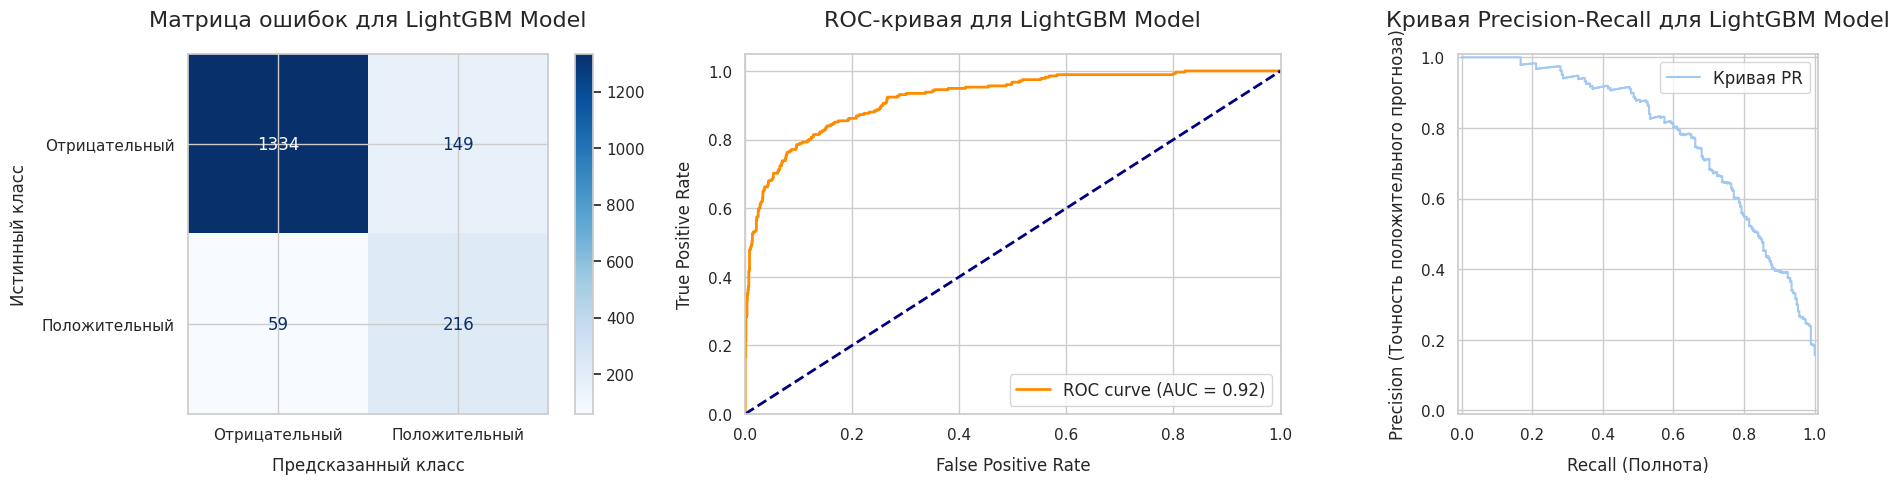


ОТЧЕТ О ПРОИЗВОДИТЕЛЬНОСТИ МОДЕЛИ: LightGBM Model

ОСНОВНЫЕ МЕТРИКИ (порог = 0.50):
Accuracy (Доля верных прогнозов): 0.8817
ROC-AUC: 0.9225
Precision (Точность положительного прогноза): 0.5918
Recall (Полнота): 0.7855
F1-score: 0.6750

ДЕТАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК:
Истинно отрицательные (TN): 1334 (75.9%)
Ложноположительные (FP): 149 (8.5%)
Ложноотрицательные (FN): 59 (3.4%)
Истинноположительные (TP): 216 (12.3%)


In [ ]:
# извлекаем лучшую модель из словаря
best_model_lbbm = result_lbbm['model']

# Визуализация
display_model_performance_lgbm(y_test,
                               # предсказание вероятности положительного класса
                               best_model_lbbm.predict_proba(X_test)[:, 1],
                               "LightGBM Model",
                               threshold=0.5)

Кривая Precision-Recall:

- Площадь под кривой (которая в некоторых местах достаточно ломаная): не слишком большая, хоть и больше 0.5.
- Форма кривой: Кривая начинается в левом верхнем углу (высокая точность при низкой полноте) и постепенно снижается по мере роста полноты.
- В левой части кривой: Когда модель предсказывает отток клиента, она очень уверенав этих прогнозах. Но при этом "ловит" мало реальных случаев.  
- В средней части кривой:  Модель жертвует точностью ради охвата большего числа реальных позитивных случаев.
- В правой части кривой: Модель становится менее избирательной, включая много ложноположительных срабатываний.  

Кривая AUC-PR:
- На графике кривая занимает большую площадь, что указывает на хорошее качество модели.

При этом доля верных ответов модели велика (на это может влиять несбалансированость классов), и цена разного типа может отличаеться.

То есть наша модель хорошо подходит для точеченых маркетинговых вмешательств, но при этом не сможет выявить все положительные случаи, так как склонна пропускать их при высоких порогах уверенности.

Поэтому потенциально необходимо подобрать наиболее подходящий для нас порог в заисимости от того, необходимо ли нам минимизировать ложные срабатывания или максимизировать охват.

Посмотрим на вклад признаков в прогноз модели.

In [ ]:
def feat_shap_lgbm(best_pipeline, X, feature_names=None):
    """
    Анализ важности признаков для LightGBM с помощью SHAP

    Параметры:
    ----------
    best_pipeline : sklearn.Pipeline
        Обученный пайплайн с LGBMClassifier
    X : pd.DataFrame или np.array
        Данные для анализа
    feature_names : list, optional
        Список названий признаков. Если None, будут использованы имена из DataFrame

    Возвращает:
    ----------
    shap_importance_df : pd.DataFrame
        DataFrame с важностью признаков
    """

    # Извлекаем модель из пайплайна
    lgbm_model = best_pipeline.named_steps['lgbmclassifier']

    # Применяем трансформации к данным (кроме последнего шага - модели)
    transformed_X = best_pipeline[:-1].transform(X)

    # Проверяем и обрабатываем имена признаков
    if feature_names is None:
        if hasattr(X, 'columns'):
            feature_names = X.columns.tolist()
        else:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]

    # Создаем explainer для LightGBM
    explainer = shap.TreeExplainer(
        lgbm_model,
        feature_perturbation="tree_path_dependent",
        model_output="raw"
    )

    # Вычисляем SHAP значения
    shap_values = explainer.shap_values(transformed_X)

    # Для бинарной классификации LightGBM возвращает список [shap_values_0, shap_values_1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1] if len(shap_values) == 2 else np.mean(shap_values, axis=0)

    # Создаем фигуру с увеличенной высотой
    plt.figure(figsize=(15, 10))

    # 1. График важности признаков
    plt.subplot(2, 1, 1)
    shap.summary_plot(
        shap_values,
        transformed_X,
        feature_names=feature_names,
        plot_type="bar",
        show=False,
        max_display=15
    )
    plt.title("Важность признаков (mean|SHAP|)", pad=20)
    plt.tight_layout()

    # 2. График влияния признаков
    plt.subplot(2, 1, 2)
    shap.summary_plot(
        shap_values,
        transformed_X,
        feature_names=feature_names,
        plot_type="dot",
        show=False,
        max_display=15
    )
    plt.title("Влияние признаков на прогноз", pad=20)
    plt.tight_layout()

    # Добавляем общий заголовок
    plt.suptitle("SHAP-анализ LightGBM модели", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

    # Создаем DataFrame с важностью признаков
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'feature': feature_names,
        'shap_importance': shap_importance
    }).sort_values('shap_importance', ascending=False)

    print("\nТоп-15 самых важных признаков по SHAP:")
    print(shap_importance_df.head(15).to_string(index=False))

    return shap_importance_df

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


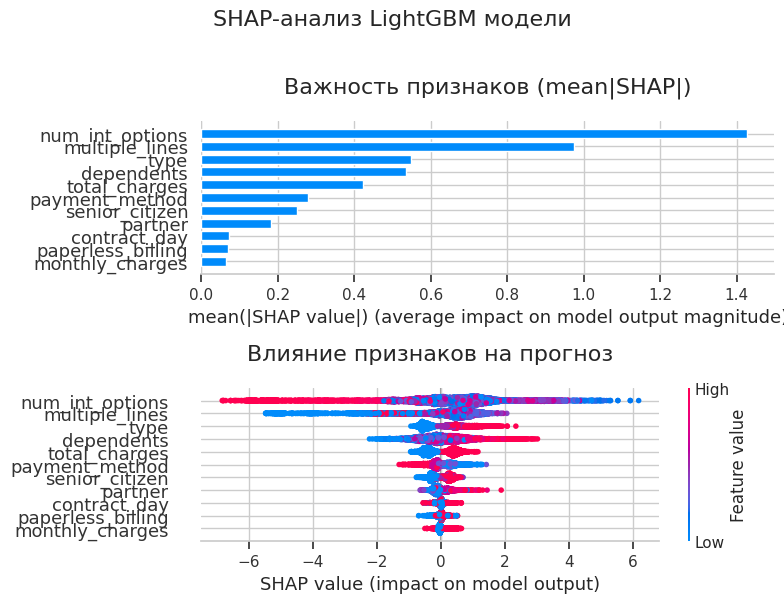


Топ-15 самых важных признаков по SHAP:
          feature  shap_importance
  num_int_options             1.43
   multiple_lines             0.97
             type             0.55
       dependents             0.54
    total_charges             0.42
   payment_method             0.28
   senior_citizen             0.25
          partner             0.18
     contract_day             0.07
paperless_billing             0.07
  monthly_charges             0.07


In [ ]:
# анализ SHAP
shap_results_lgbm = feat_shap_lgbm(best_model_lbbm, X_train)

# для предсказаний вероятностей
# y_proba = best_model_lbbm.predict_proba(X_test)[:, 1]

Самым важным признаком по мнению модели LGBMClassifier является количество подключенных интернет-опций.

По графику shap можно увидеть, что зависимость вероятности ухода от количества опций нелинейна: увеличение количества опций может способствать как уходу, так и удержанию клиента (возмножно, это зависит от того, какие именно это опции, либо стоимости тарифа?).

Посмотрим на распределение относительно классов.

/tmp/ipython-input-137-1188787242.py:26: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[feature]) or pd.api.types.is_object_dtype(df[feature]):


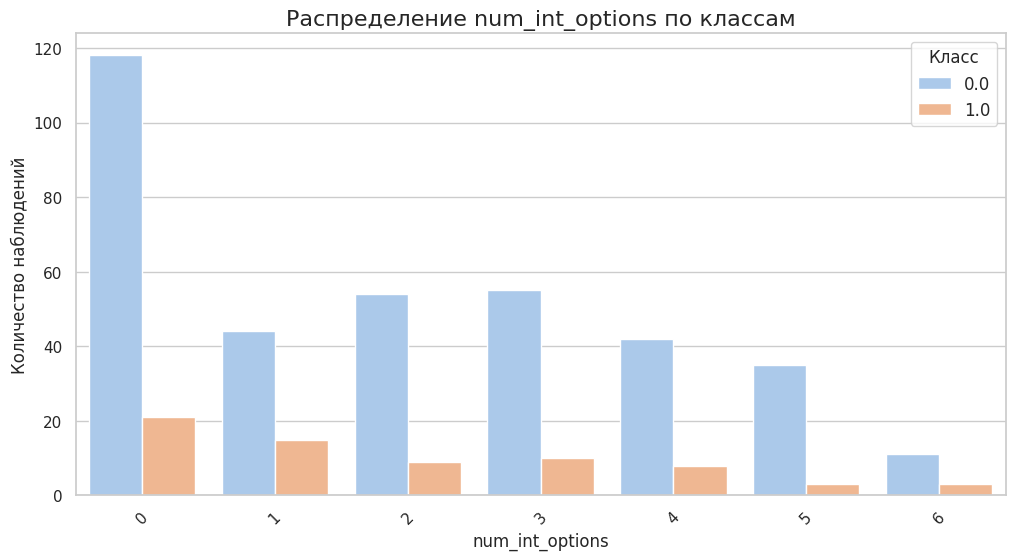

/tmp/ipython-input-137-1188787242.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(feature)[target]


<Figure size 1200x600 with 0 Axes>

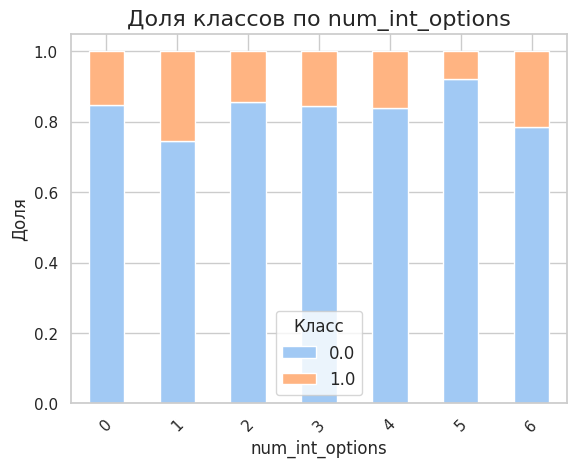

In [ ]:
# Подготовка DataFrame
df = pd.DataFrame(X_test, columns=X_test.columns)
df[target] = y_test.reset_index(drop=True)

# Визуализация
feature = 'num_int_options'  # важный признак

# Проверяем тип признака
if pd.api.types.is_numeric_dtype(df[feature]):
    # 1. График распределения (только для числовых признаков)
    plt.figure(figsize=(12, 6))
    sns.kdeplot(data=df, x=feature, hue=target, fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Распределение {feature} по классам')
    plt.xlabel(feature)
    plt.ylabel('Плотность распределения')
    plt.show()

    # 2. Боксплот (для числовых признаков)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=target, y=feature)
    plt.title(f'Распределение {feature} по классам')
    plt.xlabel('Класс')
    plt.ylabel(feature)
    plt.show()

elif pd.api.types.is_categorical_dtype(df[feature]) or pd.api.types.is_object_dtype(df[feature]):
    # Для категориальных признаков используем countplot
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=feature, hue=target)
    plt.title(f'Распределение {feature} по классам')
    plt.xlabel(feature)
    plt.ylabel('Количество наблюдений')
    plt.legend(title='Класс')
    plt.xticks(rotation=45)
    plt.show()

    # Дополнительно: доля классов
    plt.figure(figsize=(12, 6))
    (df.groupby(feature)[target]
       .value_counts(normalize=True)
       .unstack()
       .plot(kind='bar', stacked=True))
    plt.title(f'Доля классов по {feature}')
    plt.xlabel(feature)
    plt.ylabel('Доля')
    plt.legend(title='Класс')
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"Признак {feature} имеет неподдерживаемый тип: {df[feature].dtype}")

Здесь мы уже можем чуть ярче наблюдать, что более склонны к уходу клиенты, у которых подключено 3 или 5 услуг.

#### **Вывод**

Модель показала хорошую разделяющую способность с высокой долей точных  ответов. Однако необходимо обратить внимание и дополнительно настроить порог в зависимости от того, что нам важнее - охват всех положительных случаев или снижение ложных срабатываний.

Наиболее важным признаком признан количество интернет-услуг. Однако зависимость нелинейна, но можно наблюдать, что более склонны уходить клиенты с 3 или 5 услугами. Возможно, это зависит от того, какие именно услуги подключены, либо от их стоимости.

## **Вывод**

1. Мы проанализировали предоставленные заказчиком данные.

2. Подготовили данные и обучили на их основе несколько моделей.
Рассмотрели лучшую из них, и она показала хорошую разделяющую способность с высокой долей точных ответов. Для улучшения качества предсказаний необходимо настроить порог в зависимости от того, что важнее - не упустить уходящего клиента, либо снизить количество ложных срабатываний.

3. Наиболее важным признаком признан количество интернет-услуг. Однако зависимость нелинейна, но можно наблюдать, что более склонны уходить клиенты с 3 или 5 услугами. Возможно, это зависит от того, какие именно услуги подключены, либо от их стоимости.

Также, вероятно, следует поощрять клиентов с "большим стажем" эксклюзивными предложениями.